# Graph Embeddings and GNN-Based Community Detection in Social and Computer Networks

## Presentation Notebook — Full Project Overview

### **Authors:** Nima Kamali Lassem — Nicola Mambelli

### **Date:** February 2026

## Note: The Original Notebooks including Part 1, Part 2, and Datasets are Available on: https://github.com/NimakamaliLassem/Massive-Graph

---

## Abstract

This notebook presents the full arc of our project on community detection and link prediction across two contrasting real-world datasets. We begin by introducing the datasets and their key properties, then briefly summarize our earlier work on classical community detection (Part 1) and spectral/Node2Vec methods (early Part 2). The main body presents in detail the GCN-based models, knowledge graph embedding methods (TransE, RotatE, DistMult), transfer learning from KGE to GCN, and the comprehensive comparison of all methods.

**Two Datasets:**
- **LastFM Asia** — 7,624 nodes, undirected, sparse (0.096%), with node features (artist preferences) and ground truth labels (18 countries)
- **Cisco g21** — 52 nodes, directed, dense (96% raw, 51% after port filtering), with 2,157 relation types and 23 ground truth functional groups

**Key Finding:** No single model wins everywhere. Dataset properties — symmetry, directionality, relation types, density — determine which model performs best. Transfer learning (KGE → GCN) achieves the best community detection NMI (0.680) on LastFM, surpassing all classical and spectral methods.

---


---

## 1. Data Loading and Preparation

We work with **two datasets** throughout this report:

### LastFM Asia Social Network
We load the full LastFM dataset: edges (who is friends with who), node features (which artists each user likes), and target labels (which country each user is from).

We need all three because:
- **Edges** are needed by every method (spectral, Node2Vec, GCN, KGE models) since they all rely on graph structure
- **Features** are needed by the GCN, which is the only method here that can actually use node attributes
- **Labels** are needed so we can measure how well each method recovers the true communities (using NMI, ARI, etc.)

We reduce the feature dimensions from 7,842 down to 128 using SVD. The original features are too high-dimensional for the GCN to handle efficiently, and SVD keeps the most important information while cutting down the size.

### Cisco Network g21
We also load the Cisco computer network dataset. Cisco has:
- **52 nodes** (hosts) with **directed edges** representing network traffic
- **2,157+ relation types** (port/protocol combinations) — each type of traffic is a distinct relation
- **Ground truth functional groups** (23 groups) — verified communities based on actual host function
- **No native node features** — we engineer features from port usage patterns

The Cisco dataset is the opposite of LastFM in almost every way: small, dense, directed.

---


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import random
import time
from collections import Counter, defaultdict

# Community detection (Part 1 baseline)
import community as community_louvain
from networkx.algorithms import community as nx_community

# Spectral methods
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix, diags, eye as speye
from scipy.sparse import coo_matrix

# Machine learning
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import (normalized_mutual_info_score, adjusted_rand_score,
                             adjusted_mutual_info_score, classification_report,
                             accuracy_score, f1_score, roc_auc_score, average_precision_score)

# Shallow embeddings
from gensim.models import Word2Vec

# Graph neural networks
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
import seaborn as sns
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")
print("All libraries loaded successfully.")

PyTorch device: cuda
All libraries loaded successfully.


In [2]:
# Load edges
edges_df = pd.read_csv('lastfm_asia/lastfm_asia_edges.csv')
G = nx.from_pandas_edgelist(edges_df, 'node_1', 'node_2')

# Load target labels (country)
target_df = pd.read_csv('lastfm_asia/lastfm_asia_target.csv')
node_to_target = dict(zip(target_df['id'], target_df['target']))

# Load node features (artist preferences - sparse binary)
with open('lastfm_asia/lastfm_asia_features.json', 'r') as f:
    features_raw = json.load(f)

# Establish consistent node ordering
nodes = sorted(G.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes)}
idx_to_node = {i: n for n, i in node_to_idx.items()}
n_nodes = len(nodes)

# Build sparse feature matrix (scipy)
all_feature_ids = set()
for fids in features_raw.values():
    all_feature_ids.update(fids)
n_features_raw = max(all_feature_ids) + 1

row_idx, col_idx = [], []
for node_str, fids in features_raw.items():
    node_id = int(node_str)
    if node_id in node_to_idx:
        idx = node_to_idx[node_id]
        for fid in fids:
            row_idx.append(idx)
            col_idx.append(fid)

X_sparse = csr_matrix(
    (np.ones(len(row_idx)), (row_idx, col_idx)),
    shape=(n_nodes, n_features_raw)
)

# Ground truth labels (aligned with node ordering)
y = np.array([node_to_target[n] for n in nodes])
n_classes = len(np.unique(y))

print("=== LastFM Dataset (Full) ===")
print(f"Nodes: {n_nodes:,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Density: {nx.density(G):.6f}")
print(f"Raw features: {n_features_raw:,} (binary artist preferences)")
print(f"Non-zero feature entries: {X_sparse.nnz:,} (avg {X_sparse.nnz/n_nodes:.0f} per node)")
print(f"Ground truth classes: {n_classes} (countries)")

=== LastFM Dataset (Full) ===
Nodes: 7,624
Edges: 27,806
Density: 0.000957
Raw features: 7,842 (binary artist preferences)
Non-zero feature entries: 3,014,361 (avg 395 per node)
Ground truth classes: 18 (countries)


In [3]:
# Reduce feature dimensionality with Truncated SVD for GCN input
print("Reducing feature dimensionality with Truncated SVD...")
svd = TruncatedSVD(n_components=128, random_state=42)
X_reduced = svd.fit_transform(X_sparse)
print(f"Explained variance ratio (128 components): {svd.explained_variance_ratio_.sum():.4f}")
print(f"Reduced feature matrix: {X_reduced.shape}")

# Brief network statistics
print(f"\n=== Network Properties (Recap) ===")
print(f"Connected: {nx.is_connected(G)}")
print(f"Average degree: {2 * G.number_of_edges() / n_nodes:.2f}")
print(f"Clustering coefficient: {nx.average_clustering(G):.4f}")

Reducing feature dimensionality with Truncated SVD...
Explained variance ratio (128 components): 0.3917
Reduced feature matrix: (7624, 128)

=== Network Properties (Recap) ===
Connected: True
Average degree: 7.29
Clustering coefficient: 0.2194


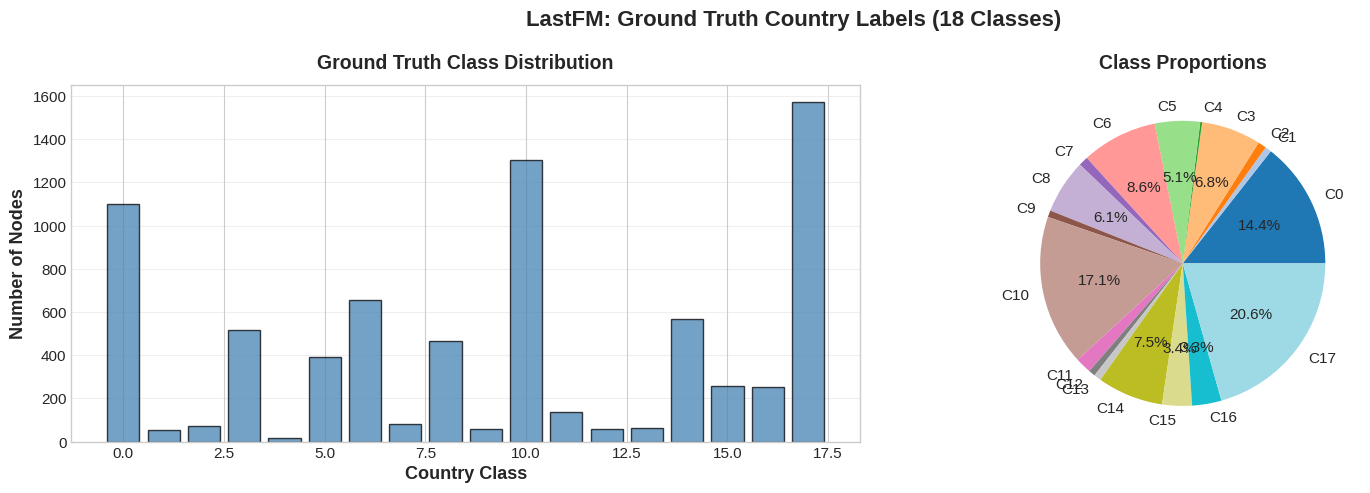

Class sizes: min=16 (class 4), max=1572 (class 17)
Imbalance ratio: 98.2x


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Class distribution
class_counts = np.bincount(y)
axes[0].bar(range(n_classes), class_counts, color='steelblue', edgecolor='black', alpha=0.75)
axes[0].set_xlabel('Country Class', fontsize=13)
axes[0].set_ylabel('Number of Nodes', fontsize=13)
axes[0].set_title('Ground Truth Class Distribution', fontsize=14, pad=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Class balance info
axes[1].pie(class_counts, labels=[f'C{i}' for i in range(n_classes)],
            autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
            colors=plt.cm.tab20(np.linspace(0, 1, n_classes)))
axes[1].set_title('Class Proportions', fontsize=14, pad=12)

plt.suptitle('LastFM: Ground Truth Country Labels (18 Classes)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Class sizes: min={class_counts.min()} (class {class_counts.argmin()}), "
      f"max={class_counts.max()} (class {class_counts.argmax()})")
print(f"Imbalance ratio: {class_counts.max() / class_counts.min():.1f}x")

---

### 1.1 Data Characterization: Why Dataset Properties Determine Model Performance

Before running any models, we analyze the key properties of our data that will directly impact which methods succeed and which fail. This analysis justifies our model choices and helps us predict results before seeing them.

---


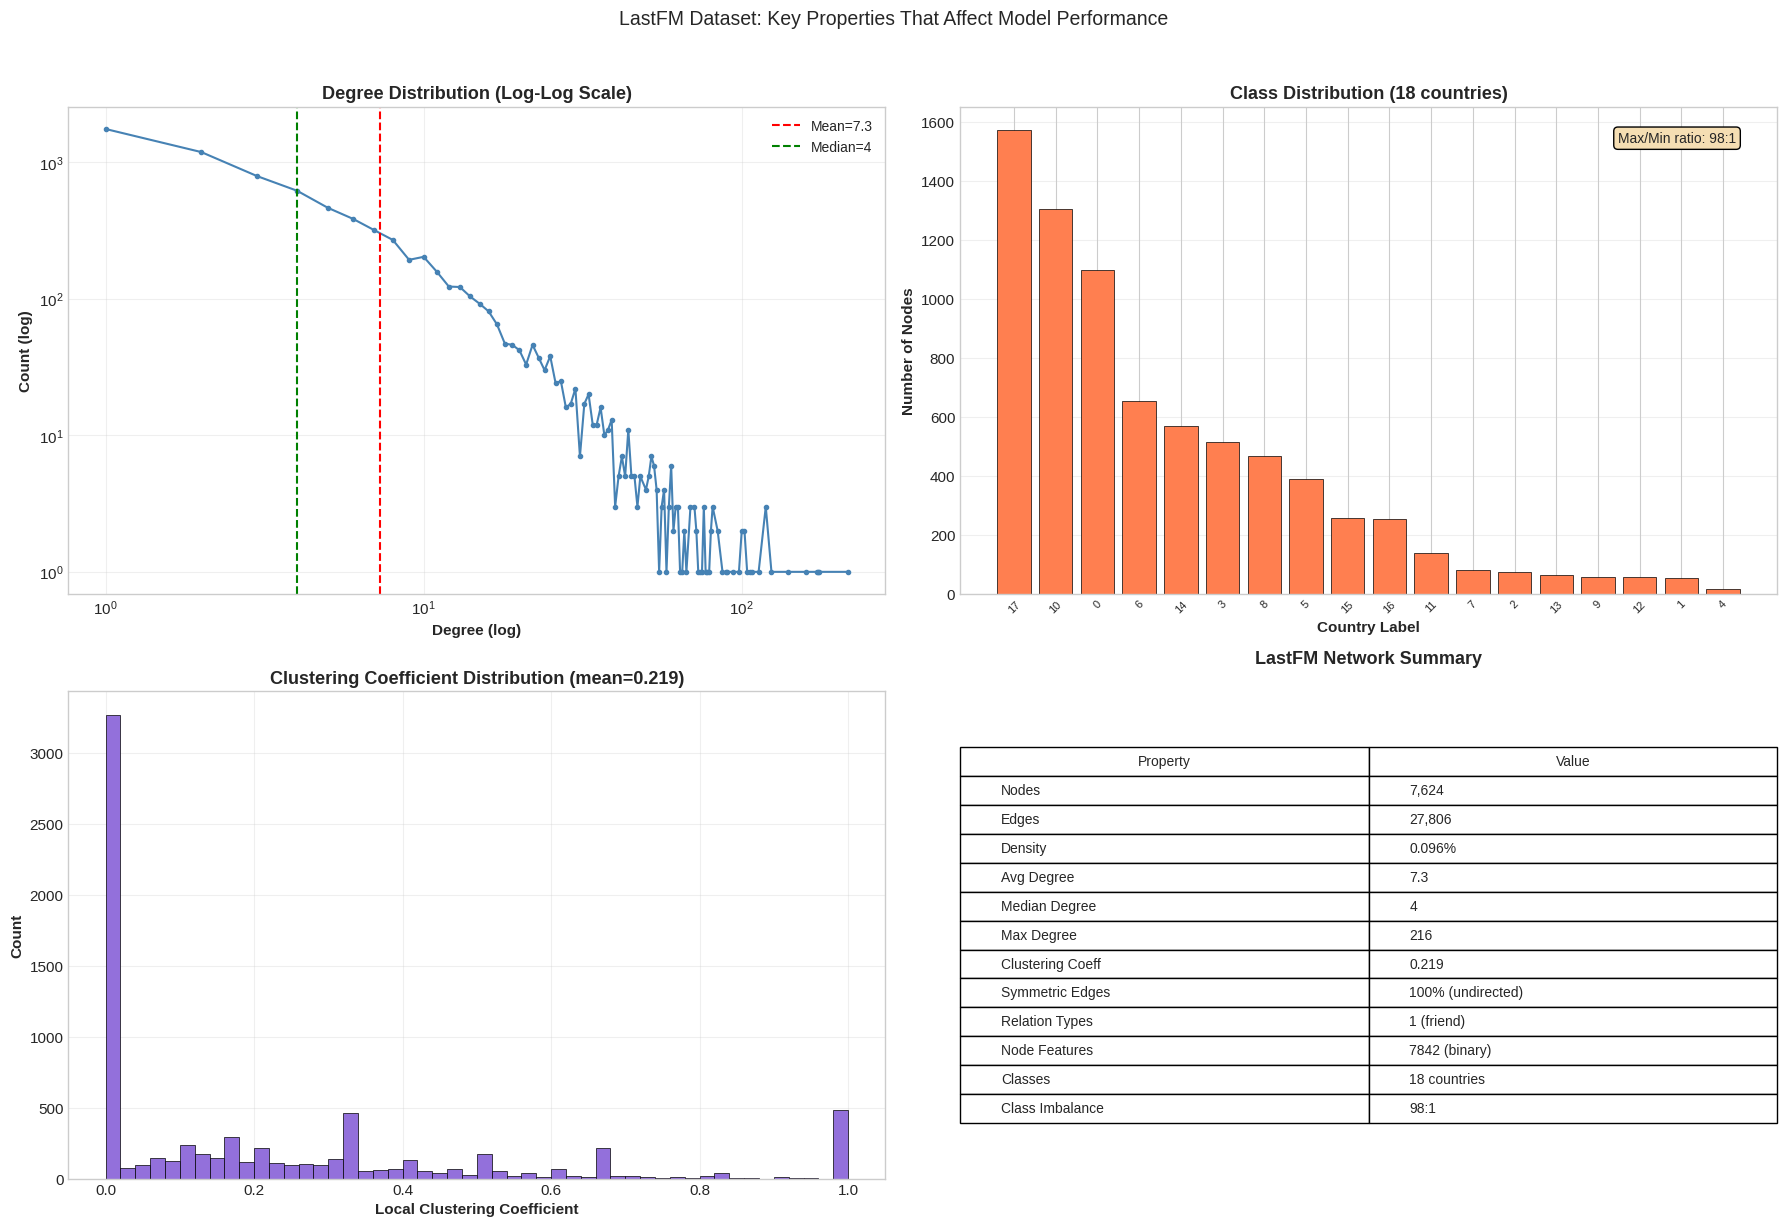


KEY DATA PROPERTIES AND THEIR MODEL IMPLICATIONS

1. ALL EDGES SYMMETRIC → TransE will fail (r→0), RotatE/DistMult handle it
2. SINGLE RELATION TYPE → KGE models underutilized (designed for multi-relational)
3. HIGH 1-to-N (avg degree 7.3) → TransE collapses tail entities
4. CLASS IMBALANCE (98:1) → Small classes hard to detect
5. SPARSE FEATURES → SVD reduction necessary for GCN
6. CLUSTERING COEFF 0.219 → Moderate community structure


In [5]:
# === Detailed Data Analysis for LastFM ===
from collections import Counter

# Degree distribution
degrees = [G.degree(n) for n in G.nodes()]
degree_counts = Counter(degrees)

# Symmetry analysis (for LastFM, all edges are undirected = symmetric)
n_edges_total = G.number_of_edges()

# Feature analysis
# Feature density (from the sparse feature matrix loaded earlier)
feature_density = X_sparse.nnz / (X_sparse.shape[0] * X_sparse.shape[1])

# Class distribution
class_counts = Counter(y)
class_names = sorted(class_counts.keys())

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Degree distribution (log-log)
deg_vals = sorted(degree_counts.keys())
deg_freqs = [degree_counts[d] for d in deg_vals]
axes[0, 0].loglog(deg_vals, deg_freqs, 'o-', markersize=3, color='steelblue')
axes[0, 0].set_xlabel('Degree (log)', fontsize=11)
axes[0, 0].set_ylabel('Count (log)', fontsize=11)
axes[0, 0].set_title('Degree Distribution (Log-Log Scale)', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)
# Add mean and median
mean_deg = np.mean(degrees)
median_deg = np.median(degrees)
axes[0, 0].axvline(mean_deg, color='red', linestyle='--', label=f'Mean={mean_deg:.1f}')
axes[0, 0].axvline(median_deg, color='green', linestyle='--', label=f'Median={median_deg:.0f}')
axes[0, 0].legend(fontsize=10)

# 2. Class distribution (sorted)
sorted_classes = sorted(class_counts.items(), key=lambda x: -x[1])
class_labels = [str(c[0]) for c in sorted_classes]
class_sizes = [c[1] for c in sorted_classes]
bars = axes[0, 1].bar(range(len(class_labels)), class_sizes, color='coral', edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('Country Label', fontsize=11)
axes[0, 1].set_ylabel('Number of Nodes', fontsize=11)
axes[0, 1].set_title(f'Class Distribution ({len(class_counts)} countries)', fontsize=13)
axes[0, 1].set_xticks(range(len(class_labels)))
axes[0, 1].set_xticklabels(class_labels, rotation=45, fontsize=8)
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Annotate imbalance
axes[0, 1].annotate(f'Max/Min ratio: {max(class_sizes)/max(min(class_sizes),1):.0f}:1',
                    xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top',
                    fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# 3. Clustering coefficient distribution
clustering_coeffs = list(nx.clustering(G).values())
axes[1, 0].hist(clustering_coeffs, bins=50, color='mediumpurple', edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('Local Clustering Coefficient', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_title(f'Clustering Coefficient Distribution (mean={np.mean(clustering_coeffs):.3f})', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)

# 4. Summary statistics table
props = [
    ('Nodes', f'{G.number_of_nodes():,}'),
    ('Edges', f'{G.number_of_edges():,}'),
    ('Density', f'{nx.density(G)*100:.3f}%'),
    ('Avg Degree', f'{mean_deg:.1f}'),
    ('Median Degree', f'{median_deg:.0f}'),
    ('Max Degree', f'{max(degrees)}'),
    ('Clustering Coeff', f'{np.mean(clustering_coeffs):.3f}'),
    ('Symmetric Edges', '100% (undirected)'),
    ('Relation Types', '1 (friend)'),
    ('Node Features', f'{X_sparse.shape[1] if hasattr(X_sparse, "shape") else "7,842"} (binary)'),
    ('Classes', f'{len(class_counts)} countries'),
    ('Class Imbalance', f'{max(class_sizes)/max(min(class_sizes),1):.0f}:1'),
]
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=[[p[0], p[1]] for p in props],
                          colLabels=['Property', 'Value'],
                          loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
axes[1, 1].set_title('LastFM Network Summary', fontsize=13, pad=20)

plt.suptitle('LastFM Dataset: Key Properties That Affect Model Performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print key implications
print("\n" + "=" * 80)
print("KEY DATA PROPERTIES AND THEIR MODEL IMPLICATIONS")
print("=" * 80)
print(f"\n1. ALL EDGES SYMMETRIC → TransE will fail (r→0), RotatE/DistMult handle it")
print(f"2. SINGLE RELATION TYPE → KGE models underutilized (designed for multi-relational)")
print(f"3. HIGH 1-to-N (avg degree {mean_deg:.1f}) → TransE collapses tail entities")
print(f"4. CLASS IMBALANCE ({max(class_sizes)/max(min(class_sizes),1):.0f}:1) → Small classes hard to detect")
print(f"5. SPARSE FEATURES → SVD reduction necessary for GCN")
print(f"6. CLUSTERING COEFF {np.mean(clustering_coeffs):.3f} → Moderate community structure")

---

### 1.2 Loading the Cisco Dataset

We load the Cisco network dataset here so it is available for all subsequent methods (Spectral Clustering, Node2Vec, GCN, TransE, RotatE, DistMult). This avoids duplicating the loading code later.

The Cisco g21 dataset is a synthetic computer network with **ground truth functional groups** — unlike LastFM where we have country labels but no confirmed community structure, Cisco gives us verified communities based on the actual function of each host.

---


In [6]:
# === Load Cisco Dataset for Part 2 ===
import gzip
from collections import defaultdict, Counter

cisco_edge_file = 'Cisco_22_networks/dir_g21_small_workload_with_gt/dir_no_packets_etc/edges_4days_feb10thruFeb13_all_49sensors.csv.txt.gz'
cisco_gt_file = 'Cisco_22_networks/dir_g21_small_workload_with_gt/groupings.gt.txt'

# Parse edge file with port info
cisco_stats = {}  # port -> list of (src, dst) pairs
with gzip.open(cisco_edge_file, 'rt') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 4:
            continue
        _, src, dst, port_info = parts[0], parts[1], parts[2], parts[3]
        for port_entry in port_info.split(','):
            port_proto = port_entry.split('-')[0]
            if port_proto not in cisco_stats:
                cisco_stats[port_proto] = []
            cisco_stats[port_proto].append((src, dst))

# Load ground truth
cisco_gt_groups = []
with open(cisco_gt_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            cisco_gt_groups.append(line.strip().split(','))

cisco_node_to_gt = {}
for gt_id, group in enumerate(cisco_gt_groups):
    for node in group:
        cisco_node_to_gt[node] = gt_id

# Build filtered undirected graph (remove dominant ports 1p6, 1p17)
remove_ports = {'1p6', '1p17'}
G_cisco = nx.Graph()
for port, pairs in cisco_stats.items():
    if port in remove_ports:
        continue
    for src, dst in pairs:
        if G_cisco.has_edge(src, dst):
            G_cisco[src][dst]['weight'] = G_cisco[src][dst].get('weight', 1) + 1
        else:
            G_cisco.add_edge(src, dst, weight=1)

cisco_nodes = sorted(G_cisco.nodes())
cisco_n_gt_groups = len(cisco_gt_groups)

# Build node features from port usage patterns (binary: does this node use port X?)
all_ports = sorted([p for p in cisco_stats.keys() if p not in remove_ports])
cisco_port_features = np.zeros((len(cisco_nodes), len(all_ports)), dtype=np.float32)
for p_idx, port in enumerate(all_ports):
    for src, dst in cisco_stats[port]:
        if src in G_cisco and dst in G_cisco:
            src_idx = cisco_nodes.index(src)
            dst_idx = cisco_nodes.index(dst)
            cisco_port_features[src_idx, p_idx] = 1.0
            cisco_port_features[dst_idx, p_idx] = 1.0

# Ground truth labels for Cisco nodes
cisco_y = np.array([cisco_node_to_gt.get(n, -1) for n in cisco_nodes])
cisco_labeled_mask = cisco_y >= 0

print(f"=== Cisco Dataset (Part 2) ===")
print(f"Nodes: {G_cisco.number_of_nodes()}")
print(f"Edges: {G_cisco.number_of_edges()}")
print(f"Density: {nx.density(G_cisco)*100:.1f}%")
print(f"Ground truth groups: {cisco_n_gt_groups}")
print(f"Nodes with GT labels: {cisco_labeled_mask.sum()}/{len(cisco_nodes)}")
print(f"Port-based features: {cisco_port_features.shape} (nodes × ports)")
print(f"Feature density: {(cisco_port_features > 0).sum() / cisco_port_features.size * 100:.1f}%")

=== Cisco Dataset (Part 2) ===
Nodes: 52
Edges: 682
Density: 51.4%
Ground truth groups: 23
Nodes with GT labels: 52/52
Port-based features: (52, 2369) (nodes × ports)
Feature density: 6.2%


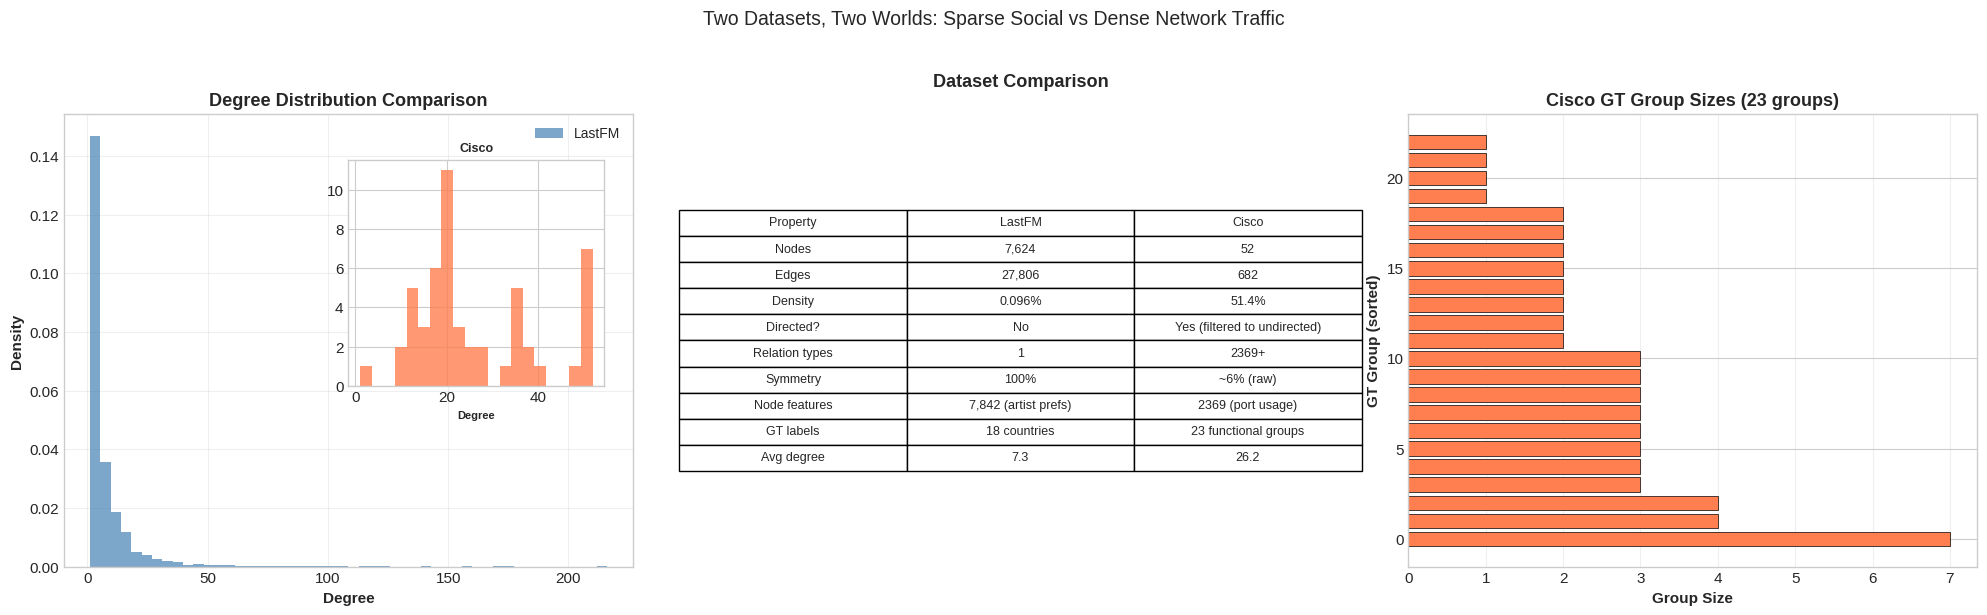


Key differences that will affect model performance:
  LastFM: SPARSE (0.096%), SYMMETRIC, SINGLE-RELATION → RotatE/DistMult favored
  Cisco:  DENSE (51.4%), DIRECTED, MULTI-RELATIONAL → TransE favored


In [7]:
# === Side-by-side Dataset Comparison ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Degree distributions comparison
cisco_degrees = [G_cisco.degree(n) for n in G_cisco.nodes()]
lastfm_degrees = [G.degree(n) for n in G.nodes()]

axes[0].hist(lastfm_degrees, bins=50, alpha=0.7, color='steelblue', label='LastFM', density=True)
axes[0].set_xlabel('Degree', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Degree Distribution Comparison', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
# Inset for Cisco (different scale)
ax_inset = axes[0].inset_axes([0.5, 0.4, 0.45, 0.5])
ax_inset.hist(cisco_degrees, bins=20, color='coral', alpha=0.8)
ax_inset.set_title('Cisco', fontsize=9)
ax_inset.set_xlabel('Degree', fontsize=8)

# 2. Network properties comparison table
props_compare = [
    ['Property', 'LastFM', 'Cisco'],
    ['Nodes', f'{G.number_of_nodes():,}', f'{G_cisco.number_of_nodes()}'],
    ['Edges', f'{G.number_of_edges():,}', f'{G_cisco.number_of_edges()}'],
    ['Density', f'{nx.density(G)*100:.3f}%', f'{nx.density(G_cisco)*100:.1f}%'],
    ['Directed?', 'No', 'Yes (filtered to undirected)'],
    ['Relation types', '1', f'{len(all_ports)}+'],
    ['Symmetry', '100%', '~6% (raw)'],
    ['Node features', '7,842 (artist prefs)', f'{len(all_ports)} (port usage)'],
    ['GT labels', '18 countries', f'{cisco_n_gt_groups} functional groups'],
    ['Avg degree', f'{np.mean(lastfm_degrees):.1f}', f'{np.mean(cisco_degrees):.1f}'],
]
axes[1].axis('off')
table = axes[1].table(cellText=props_compare[1:], colLabels=props_compare[0],
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)
axes[1].set_title('Dataset Comparison', fontsize=13, pad=20)

# 3. Cisco GT group sizes
gt_sizes = [len(g) for g in cisco_gt_groups]
axes[2].barh(range(len(gt_sizes)), sorted(gt_sizes, reverse=True), color='coral', edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('Group Size', fontsize=11)
axes[2].set_ylabel('GT Group (sorted)', fontsize=11)
axes[2].set_title(f'Cisco GT Group Sizes ({cisco_n_gt_groups} groups)', fontsize=13)
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Two Datasets, Two Worlds: Sparse Social vs Dense Network Traffic', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nKey differences that will affect model performance:")
print(f"  LastFM: SPARSE ({nx.density(G)*100:.3f}%), SYMMETRIC, SINGLE-RELATION → RotatE/DistMult favored")
print(f"  Cisco:  DENSE ({nx.density(G_cisco)*100:.1f}%), DIRECTED, MULTI-RELATIONAL → TransE favored")

---

## 2. Summary of Previous Work: Community Detection

Before diving into GCN and knowledge graph embedding models, we briefly recap the community detection results from Part 1 (classical methods) and the early sections of Part 2 (spectral clustering and Node2Vec). We group them here because they all address the same question: **how well can we find communities in these two networks?**

---

### 2.1 Part 1: Classical Community Detection

In Part 1, we applied classical community detection algorithms that rely only on graph topology — no node features, no embeddings.

#### On LastFM (Undirected)

We ran Louvain, Label Propagation, and Greedy Modularity on the full LastFM social network. Since there was no ground truth available in Part 1, we evaluated using intrinsic metrics only.

| Algorithm | Modularity | Conductance | Coverage |
|-----------|-----------|-------------|----------|
| **Louvain** | **0.815** | **0.135** | 0.919 |
| Label Propagation | 0.752 | 0.435 | 0.830 |
| Greedy Modularity | 0.796 | 0.163 | 0.943 |

**Louvain** consistently performed best: highest modularity with clean community boundaries (lowest conductance).

Below: community structure visualizations and comparative metrics from Part 1.


In [ ]:
# === Part 1 Recap: Community Detection on LastFM ===
# Run the three classical algorithms so we can visualize the results.

from networkx.algorithms.community import modularity as nx_modularity
from networkx.algorithms.community.quality import partition_quality

print("Running community detection algorithms on LastFM...\n")

# Louvain
partition_louvain_lf = community_louvain.best_partition(G)
communities_louvain_lf = {}
for node, comm_id in partition_louvain_lf.items():
    communities_louvain_lf.setdefault(comm_id, []).append(node)
print(f"✓ Louvain: {len(communities_louvain_lf)} communities")

# Label Propagation
from networkx.algorithms import community as nx_community
communities_lp_lf = list(nx_community.label_propagation_communities(G))
partition_lp_lf = {}
for idx, comm in enumerate(communities_lp_lf):
    for node in comm:
        partition_lp_lf[node] = idx
print(f"✓ Label Propagation: {len(communities_lp_lf)} communities")

# Greedy Modularity
communities_greedy_lf = list(nx_community.greedy_modularity_communities(G))
partition_greedy_lf = {}
for idx, comm in enumerate(communities_greedy_lf):
    for node in comm:
        partition_greedy_lf[node] = idx
print(f"✓ Greedy Modularity: {len(communities_greedy_lf)} communities")

# Evaluate
def evaluate_quick(G, communities_list, name):
    mod = nx_community.modularity(G, communities_list)
    cov, perf = partition_quality(G, communities_list)
    total_cond = 0
    valid = 0
    for comm in communities_list:
        if 1 < len(comm) < G.number_of_nodes():
            try:
                total_cond += nx.algorithms.cuts.conductance(G, comm)
                valid += 1
            except:
                pass
    avg_cond = total_cond / valid if valid > 0 else 0
    intra = sum(1 for u, v in G.edges() if any(u in c and v in c for c in communities_list))
    intra_pct = intra / G.number_of_edges() * 100
    return {'Algorithm': name, 'Modularity': mod, 'Coverage': cov,
            'Performance': perf, 'Avg Conductance': avg_cond,
            'Communities': len(communities_list), 'Intra Edges %': intra_pct}

results = []
results.append(evaluate_quick(G, [set(c) for c in communities_louvain_lf.values()], 'Louvain'))
results.append(evaluate_quick(G, [set(c) for c in communities_lp_lf], 'Label Propagation'))
results.append(evaluate_quick(G, [set(c) for c in communities_greedy_lf], 'Greedy Modularity'))
results_df_lf = pd.DataFrame(results)
print("\n", results_df_lf.to_string(index=False))

# Community layout visualization
sample_nodes = list(G.nodes())[:500]
G_sample_lf = G.subgraph(sample_nodes).copy()
pos = nx.spring_layout(G_sample_lf, k=0.6, iterations=50, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (title, partition) in zip(axes, [
    ('Louvain', partition_louvain_lf),
    ('Label Propagation', partition_lp_lf),
    ('Greedy Modularity', partition_greedy_lf)]):
    node_colors = [partition.get(node, 0) for node in G_sample_lf.nodes()]
    nx.draw_networkx_nodes(G_sample_lf, pos, node_color=node_colors, node_size=60,
                           cmap='tab20', alpha=0.85, ax=ax, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(G_sample_lf, pos, alpha=0.15, width=0.5, ax=ax)
    ax.set_title(f'{title}\n({len(set(partition.values()))} communities)', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('LastFM: Community Detection (500-node sample)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Metrics bar chart
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
algorithms = ['Louvain', 'Label\nPropagation', 'Greedy\nModularity']
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c']
metrics_info = [
    ('Modularity', 'Modularity Score', 'Higher is Better', [0, 1]),
    ('Coverage', 'Coverage', 'Higher is Better', [0, 1]),
    ('Performance', 'Performance', 'Higher is Better', [0, 1]),
    ('Avg Conductance', 'Avg Conductance', 'Lower is Better', None),
    ('Communities', 'Number of Communities', '', None),
    ('Intra Edges %', 'Intra-Community Edges (%)', 'Higher is Better', [0, 100])
]
for idx, (metric, ylabel, subtitle, ylim) in enumerate(metrics_info):
    ax = axes[idx // 3, idx % 3]
    values = [results_df_lf.loc[i, metric] for i in range(3)]
    bars = ax.bar(algorithms, values, color=colors_bar, alpha=0.75, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    title_text = f'{ylabel}' + (f'\n({subtitle})' if subtitle else '')
    ax.set_title(title_text, fontsize=13, fontweight='bold', pad=12)
    if ylim: ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    for i, (bar, v) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{v:.3f}' if metric != 'Communities' else f'{int(v)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    best_idx = values.index(min(values)) if metric == 'Avg Conductance' else values.index(max(values))
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3.5)
plt.suptitle('LastFM: Comprehensive Algorithm Comparison', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
print("\n** Red borders indicate best-performing algorithm for each metric **")


#### On Cisco g21 (Directed)

We applied both undirected (Louvain, Label Propagation, Greedy Modularity) and directed (Girvan-Newman, Infomap) algorithms. The Cisco dataset has ground truth, so we could validate with external metrics.

| Algorithm | Type | Jaccard | NMI | ARI | AMI |
|-----------|------|---------|-----|-----|-----|
| Louvain | Undirected | **0.531** | 0.165 | 0.011 | 0.080 |
| Greedy Modularity | Undirected | **0.531** | 0.165 | 0.011 | 0.080 |
| Label Propagation | Undirected | 0.077 | 0.000 | 0.000 | 0.000 |
| Girvan-Newman | Directed | 0.322 | **0.296** | 0.007 | 0.038 |
| Infomap | Directed | 0.077 | 0.000 | 0.000 | 0.000 |

**Key insights from Part 1 (Cisco):**
- The extremely dense Cisco network (96% raw density) required port filtering to reveal meaningful structure
- **Louvain and Greedy Modularity** achieved the best Jaccard (0.531), but overall ground truth alignment was low (NMI=0.165)
- **Girvan-Newman** stood out with the best NMI (0.296), suggesting hierarchical edge removal captures functional structure better
- **Label Propagation and Infomap collapsed** on this dense graph, putting all nodes into one community (NMI=0, ARI=0)

Below: Cisco community visualizations and ground truth validation charts from Part 1.


In [ ]:
# === Part 1 Recap: Community Detection on Cisco ===
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

# Build filtered graph (removing dominant ports 1p6, 1p17)
top2_ports = {'1p6', '1p17'}
G_filtered = nx.Graph()
for port, pairs in cisco_stats.items():
    if port in top2_ports:
        continue
    for u, v in pairs:
        G_filtered.add_edge(u, v)

print(f"Filtered graph: {G_filtered.number_of_nodes()} nodes, {G_filtered.number_of_edges()} edges")
print(f"Density: {nx.density(G_filtered)*100:.1f}%")

# Build weighted graph (IDF-based)
from collections import defaultdict
edge_port_counts = defaultdict(set)
for port, pairs in cisco_stats.items():
    if port in top2_ports:
        continue
    for u, v in pairs:
        edge_port_counts[(u, v)].add(port)
        edge_port_counts[(v, u)].add(port)

total_ports = len([p for p in cisco_stats.keys() if p not in top2_ports])
G_weighted = G_filtered.copy()
for u, v in G_weighted.edges():
    n_ports = len(edge_port_counts.get((u, v), set()))
    G_weighted[u][v]['weight'] = np.log(total_ports / max(n_ports, 1)) + 1

# Run community detection
partition_louvain_c = community_louvain.best_partition(G_weighted, weight="weight")
communities_louvain_c = {}
for node, comm_id in partition_louvain_c.items():
    communities_louvain_c.setdefault(comm_id, []).append(node)

communities_lp_c = list(nx_community.label_propagation_communities(G_weighted))
partition_lp_c = {}
for idx, comm in enumerate(communities_lp_c):
    for node in comm:
        partition_lp_c[node] = idx

communities_greedy_c = list(nx_community.greedy_modularity_communities(G_weighted))
partition_greedy_c = {}
for idx, comm in enumerate(communities_greedy_c):
    for node in comm:
        partition_greedy_c[node] = idx

print(f"Louvain: {len(communities_louvain_c)} comms | Label Prop: {len(communities_lp_c)} comms | Greedy: {len(communities_greedy_c)} comms")

# Cisco community visualization
pos_cisco = nx.spring_layout(G_filtered, k=0.55, iterations=200, seed=42)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, (title, partition) in zip(axes, [
    ('Louvain (Weighted)', partition_louvain_c),
    ('Label Propagation', partition_lp_c),
    ('Greedy Modularity', partition_greedy_c)]):
    node_colors = [partition.get(node, 0) for node in G_filtered.nodes()]
    nx.draw_networkx_nodes(G_filtered, pos_cisco, node_color=node_colors, node_size=200,
                           cmap='tab20', alpha=0.85, ax=ax, edgecolors='black', linewidths=1)
    nx.draw_networkx_edges(G_filtered, pos_cisco, alpha=0.2, width=0.5, ax=ax)
    nx.draw_networkx_labels(G_filtered, pos_cisco, font_size=6, ax=ax)
    ax.set_title(f'{title}\n({len(set(partition.values()))} communities)', fontsize=14, fontweight='bold')
    ax.axis('off')
plt.suptitle('Cisco g21: Community Detection (Filtered)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Ground truth evaluation
def jaccard(a, b):
    a, b = set(a), set(b)
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union > 0 else 0.0

def average_best_jaccard(found_communities, gt_groups_sets):
    scores = []
    for comm in found_communities:
        comm = set(comm)
        if len(comm) < 1: continue
        best = max(jaccard(comm, g) for g in gt_groups_sets)
        scores.append(best)
    return sum(scores) / len(scores) if scores else 0.0

gt_groups_sets = [set(g) for g in gt_groups]

# Prepare labels
node_to_gt = {}
for gt_id, group in enumerate(gt_groups):
    for node in group:
        node_to_gt[node] = gt_id

gt_labels, pred_l, pred_lp, pred_g = [], [], [], []
for node in sorted(G_weighted.nodes()):
    if node in node_to_gt:
        gt_labels.append(node_to_gt[node])
        pred_l.append(partition_louvain_c.get(node, -1))
        pred_lp.append(partition_lp_c.get(node, -1))
        pred_g.append(partition_greedy_c.get(node, -1))

algo_names = ['Louvain (Undirected)', 'Label Prop (Undirected)', 'Greedy Mod (Undirected)']
found_comms = [
    [set(c) for c in communities_louvain_c.values()],
    [set(c) for c in communities_lp_c],
    [set(c) for c in communities_greedy_c]
]
preds = [pred_l, pred_lp, pred_g]

results_cisco = []
for name, fc, pr in zip(algo_names, found_comms, preds):
    j = average_best_jaccard(fc, gt_groups_sets)
    nmi = normalized_mutual_info_score(gt_labels, pr) if len(gt_labels) == len(pr) else 0
    ari = adjusted_rand_score(gt_labels, pr) if len(gt_labels) == len(pr) else 0
    ami = adjusted_mutual_info_score(gt_labels, pr) if len(gt_labels) == len(pr) else 0
    results_cisco.append({'Algorithm': name, 'Jaccard': j, 'NMI': nmi, 'ARI': ari, 'AMI': ami})

comparison_df_cisco = pd.DataFrame(results_cisco)
print("\n=== Cisco Ground Truth Validation ===")
print(comparison_df_cisco.to_string(index=False))

# GT validation bar chart
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
metrics = ['Jaccard', 'NMI', 'ARI', 'AMI']
titles = ['Jaccard Overlap', 'Normalized Mutual Information', 'Adjusted Rand Index', 'Adjusted Mutual Information']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df_cisco[metric].values
    bars = ax.bar(range(len(algo_names)), values, color=colors[:len(algo_names)],
                  alpha=0.75, edgecolor='black', linewidth=1.5)
    ax.set_xticks(range(len(algo_names)))
    ax.set_xticklabels([n.replace(' (Undirected)', '') for n in algo_names], fontsize=11)
    ax.set_ylabel(title, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.suptitle('Cisco g21: Ground Truth Validation', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


---

### 2.2 Part 2: Spectral Clustering

Spectral clustering is the most mathematically grounded approach: it uses eigenvalues of the graph Laplacian to find communities. We compute the normalized Laplacian $L_{sym}$, find its smallest eigenvalues, and use the corresponding eigenvectors as coordinates for K-means clustering.

#### On LastFM

| Configuration | Modularity | NMI | ARI | AMI |
|--------------|-----------|-----|-----|-----|
| **GT-matched (k=18)** | **0.7992** | **0.6586** | **0.6714** | **0.6557** |

Spectral clustering with k=18 achieves **better ground truth alignment than Louvain** (NMI=0.659 vs 0.622, ARI=0.671 vs 0.535). Louvain wins on modularity, but spectral better recovers the true (country-based) communities.

#### On Cisco

| Configuration | Modularity | NMI | ARI |
|--------------|-----------|-----|-----|
| **GT-matched (k=23)** | 0.2049 | **0.8632** | 0.4961 |

Cisco's spectral clustering achieves surprisingly high NMI (0.863) despite low modularity.

Below: eigenvalue spectra, spectral embedding t-SNE, and cross-dataset eigenvalue comparison.


In [ ]:
import scipy
# === Part 2 Recap: Spectral Clustering ===
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Build normalized Laplacian for LastFM
A_lastfm = nx.adjacency_matrix(G, nodelist=nodes)
degrees_lap = np.array(A_lastfm.sum(axis=1)).flatten()
D_inv_sqrt = diags(1.0 / np.sqrt(np.maximum(degrees_lap, 1e-10)))
L_sym = speye(len(nodes)) - D_inv_sqrt @ A_lastfm @ D_inv_sqrt

# Compute eigenvalues
n_eigs = 50
print(f"Computing {n_eigs} smallest eigenvalues of L_sym...")
t0 = time.time()
eigenvalues, eigenvectors = eigsh(L_sym.tocsc(), k=n_eigs, which='SM')
print(f"Done in {time.time()-t0:.1f}s")

# Sort
sort_idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

# Eigengap
diffs = np.diff(eigenvalues[1:])
k_eigengap = np.argmax(diffs) + 2

# Plot eigenvalue spectrum
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(range(1, n_eigs+1), eigenvalues, 'b.-', linewidth=1.5, markersize=6)
axes[0].axvline(x=k_eigengap, color='r', linestyle='--', label=f'Eigengap at k={k_eigengap}')
axes[0].set_xlabel('Index', fontsize=12)
axes[0].set_ylabel('Eigenvalue', fontsize=12)
axes[0].set_title('50 Smallest Eigenvalues of L_sym', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(2, n_eigs), diffs, color='steelblue', alpha=0.7)
axes[1].axvline(x=k_eigengap, color='r', linestyle='--', label=f'Max gap at k={k_eigengap}')
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('Eigengap (λ_{k+1} - λ_k)', fontsize=12)
axes[1].set_title('Eigengap Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Spectral clustering with GT-matched k
results_spectral = {}
for k_val, label in [(n_classes, f'GT-matched (k={n_classes})')]:
    V = eigenvectors[:, 1:k_val+1]
    norms = np.linalg.norm(V, axis=1, keepdims=True)
    V_norm = V / np.maximum(norms, 1e-10)
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    labels_spec = kmeans.fit_predict(V_norm)
    results_spectral[label] = {
        'labels': labels_spec, 'embedding': V_norm, 'k': k_val
    }
    mod_s = nx_community.modularity(G, [set(np.where(labels_spec == c)[0]) for c in range(k_val) if np.sum(labels_spec == c) > 0])
    nmi_s = normalized_mutual_info_score(y, labels_spec)
    ari_s = adjusted_rand_score(y, labels_spec)
    ami_s = adjusted_mutual_info_score(y, labels_spec)
    print(f"\n=== Spectral Clustering: {label} ===")
    print(f"Modularity: {mod_s:.4f}")
    print(f"NMI: {nmi_s:.4f}, ARI: {ari_s:.4f}, AMI: {ami_s:.4f}")

# t-SNE of spectral embeddings
spec_key = f'GT-matched (k={n_classes})'
spec_emb = results_spectral[spec_key]['embedding']
spec_labels = results_spectral[spec_key]['labels']

tsne_spec = TSNE(n_components=2, random_state=42, perplexity=30)
spec_2d = tsne_spec.fit_transform(spec_emb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc0 = axes[0].scatter(spec_2d[:, 0], spec_2d[:, 1], c=y, cmap='tab20', s=10, alpha=0.7)
axes[0].set_title(f'Spectral Embeddings — True Labels ({n_classes} countries)', fontsize=13, fontweight='bold')
axes[0].axis('off')
sc1 = axes[1].scatter(spec_2d[:, 0], spec_2d[:, 1], c=spec_labels, cmap='tab20', s=10, alpha=0.7)
axes[1].set_title(f'Spectral Embeddings — Predicted Clusters (k={n_classes})', fontsize=13, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Spectral on Cisco
A_cisco_spec = nx.adjacency_matrix(G_cisco, nodelist=sorted(G_cisco.nodes()))
degrees_cisco = np.array(A_cisco_spec.sum(axis=1)).flatten()
D_inv_sqrt_c = diags(1.0 / np.sqrt(np.maximum(degrees_cisco, 1e-10)))
L_sym_cisco = speye(G_cisco.number_of_nodes()) - D_inv_sqrt_c @ A_cisco_spec @ D_inv_sqrt_c
n_eigs_c = min(30, G_cisco.number_of_nodes() - 2)
eigenvalues_cisco, _ = eigsh(L_sym_cisco.tocsc(), k=n_eigs_c, which='SM')
eigenvalues_cisco = np.sort(eigenvalues_cisco)

# Eigenvalue comparison plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(range(1, len(eigenvalues)+1), eigenvalues, 'b.-')
axes[0].set_title('LastFM: Eigenvalue Spectrum', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Index'); axes[0].set_ylabel('Eigenvalue'); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(eigenvalues_cisco)+1), eigenvalues_cisco, 'r.-')
axes[1].set_title('Cisco: Eigenvalue Spectrum', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Index'); axes[1].set_ylabel('Eigenvalue'); axes[1].grid(True, alpha=0.3)

# Compare first 20
n_compare = min(20, len(eigenvalues_cisco))
axes[2].plot(range(1, n_compare+1), eigenvalues[:n_compare], 'b.-', label='LastFM', linewidth=2)
axes[2].plot(range(1, n_compare+1), eigenvalues_cisco[:n_compare], 'r.-', label='Cisco', linewidth=2)
axes[2].set_title('Comparison (first 20)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Index'); axes[2].set_ylabel('Eigenvalue')
axes[2].legend(fontsize=11); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 2.3 Part 2: Node2Vec (Shallow Embeddings via Biased Random Walks)

Node2Vec learns node embeddings by doing biased random walks on the graph and training a Word2Vec model. We tried two configurations:
- **BFS-biased (p=1, q=2):** explores local neighborhood structure
- **DFS-biased (p=2, q=0.5):** explores more global/homophily patterns

#### On LastFM

| Configuration | Modularity | NMI | ARI | AMI |
|--------------|-----------|-----|-----|-----|
| BFS (p=1, q=2) | 0.7780 | 0.6233 | 0.5329 | 0.6204 |
| **DFS (p=2, q=0.5)** | **0.8042** | **0.6345** | **0.5614** | **0.6316** |

DFS slightly outperforms BFS, consistent with DFS exploring more global structure. But neither configuration beats Louvain on modularity or spectral on NMI.

#### On Cisco

Node2Vec performs poorly on the dense, small Cisco network — random walks hit all nodes quickly, making the BFS/DFS trade-off irrelevant.

**Summary so far:** For community detection, Louvain leads on modularity, spectral clustering leads on ground truth alignment, and Node2Vec is a reasonable middle ground. Now we move to deep learning and knowledge graph embedding methods.

Below: t-SNE visualizations of Node2Vec embeddings on both datasets.


In [ ]:
# === Part 2 Recap: Node2Vec ===
from gensim.models import Word2Vec

def node2vec_walk(G, start, walk_length, p, q, neighbors_dict):
    walk = [start]
    for _ in range(walk_length - 1):
        cur = walk[-1]
        neighbors = neighbors_dict[cur]
        if len(neighbors) == 0:
            break
        if len(walk) == 1:
            walk.append(random.choice(neighbors))
        else:
            prev = walk[-2]
            probs = []
            for n in neighbors:
                if n == prev: probs.append(1.0 / p)
                elif G.has_edge(n, prev): probs.append(1.0)
                else: probs.append(1.0 / q)
            probs = np.array(probs)
            probs /= probs.sum()
            walk.append(np.random.choice(neighbors, p=probs))
    return walk

def train_node2vec(G, num_walks=10, walk_length=80, p=1.0, q=1.0, dim=128, window=10, workers=4):
    neighbors_dict = {n: list(G.neighbors(n)) for n in G.nodes()}
    walks = []
    node_list = list(G.nodes())
    for _ in range(num_walks):
        random.shuffle(node_list)
        for node in node_list:
            walk = node2vec_walk(G, node, walk_length, p, q, neighbors_dict)
            walks.append([str(n) for n in walk])
    model = Word2Vec(walks, vector_size=dim, window=window, min_count=0, sg=1, workers=workers, epochs=5)
    return model

# BFS-biased (p=1, q=2) and DFS-biased (p=2, q=0.5) on LastFM
print("Training Node2Vec (BFS) on LastFM...")
model_bfs = train_node2vec(G, num_walks=10, walk_length=80, p=1.0, q=2.0, dim=128)
print("Training Node2Vec (DFS) on LastFM...")
model_dfs = train_node2vec(G, num_walks=10, walk_length=80, p=2.0, q=0.5, dim=128)

# Extract embeddings
n2v_bfs = np.array([model_bfs.wv[str(n)] for n in nodes])
n2v_dfs = np.array([model_dfs.wv[str(n)] for n in nodes])
labels_bfs = KMeans(n_clusters=n_classes, random_state=42, n_init=10).fit_predict(n2v_bfs)
labels_dfs = KMeans(n_clusters=n_classes, random_state=42, n_init=10).fit_predict(n2v_dfs)

# t-SNE visualization
print("Computing t-SNE projections...")
tsne_bfs = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(n2v_bfs)
tsne_dfs = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(n2v_dfs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(tsne_bfs[:, 0], tsne_bfs[:, 1], c=y, cmap='tab20', s=10, alpha=0.7)
axes[0].set_title('Node2Vec BFS (p=1, q=2) — True Labels', fontsize=13, fontweight='bold')
axes[0].axis('off')
axes[1].scatter(tsne_dfs[:, 0], tsne_dfs[:, 1], c=y, cmap='tab20', s=10, alpha=0.7)
axes[1].set_title('Node2Vec DFS (p=2, q=0.5) — True Labels', fontsize=13, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Evaluate
for name, labels_km, emb in [('Node2Vec BFS (p=1,q=2)', labels_bfs, n2v_bfs),
                               ('Node2Vec DFS (p=2,q=0.5)', labels_dfs, n2v_dfs)]:
    communities_km = [set(np.where(labels_km == c)[0]) for c in range(n_classes) if np.sum(labels_km == c) > 0]
    mod = nx_community.modularity(G, communities_km)
    nmi = normalized_mutual_info_score(y, labels_km)
    ari = adjusted_rand_score(y, labels_km)
    ami = adjusted_mutual_info_score(y, labels_km)
    print(f"\n=== {name} ===")
    print(f"Modularity: {mod:.4f}")
    print(f"NMI: {nmi:.4f}, ARI: {ari:.4f}, AMI: {ami:.4f}")

# Node2Vec on Cisco
print("\nTraining Node2Vec (BFS) on Cisco...")
model_bfs_cisco = train_node2vec(G_cisco, num_walks=10, walk_length=20, p=1.0, q=2.0, dim=64)
print("Training Node2Vec (DFS) on Cisco...")
model_dfs_cisco = train_node2vec(G_cisco, num_walks=10, walk_length=20, p=2.0, q=0.5, dim=64)

cisco_nodes_sorted = sorted(G_cisco.nodes())
n2v_bfs_c = np.array([model_bfs_cisco.wv[str(n)] for n in cisco_nodes_sorted])
n2v_dfs_c = np.array([model_dfs_cisco.wv[str(n)] for n in cisco_nodes_sorted])

n_gt = len(gt_groups)
labels_bfs_c = KMeans(n_clusters=n_gt, random_state=42, n_init=10).fit_predict(n2v_bfs_c)
labels_dfs_c = KMeans(n_clusters=n_gt, random_state=42, n_init=10).fit_predict(n2v_dfs_c)

results_n2v_cisco = {
    'Node2Vec BFS (p=1,q=2)': {'labels': labels_bfs_c, 'embedding': n2v_bfs_c},
    'Node2Vec DFS (p=2,q=0.5)': {'labels': labels_dfs_c, 'embedding': n2v_dfs_c}
}

# t-SNE Cisco
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for idx, (name, data) in enumerate(results_n2v_cisco.items()):
    tsne_c = TSNE(n_components=2, random_state=42, perplexity=min(15, len(cisco_nodes_sorted)-1)).fit_transform(data['embedding'])
    axes[idx].scatter(tsne_c[:, 0], tsne_c[:, 1], c=data['labels'], cmap='tab20', s=100, alpha=0.8, edgecolors='black')
    axes[idx].set_title(f'Cisco: {name}', fontsize=13, fontweight='bold')
    axes[idx].axis('off')
plt.tight_layout()
plt.show()


---

## 3. GCN for Node Classification

### Why GCN?

After trying spectral clustering (math-based) and Node2Vec (random walk-based), we now move to Graph Convolutional Networks (GCN). The reason is simple: GCN is the only method here that can use **both** the graph structure **and** the node features (artist preferences). Spectral clustering and Node2Vec only use structure.

Since the LastFM dataset has rich node features (7,842 binary artist preferences, reduced to 128 via SVD), we expect the GCN to benefit from this extra information. The key question is whether it finds better communities than methods that ignore features.

### How It Works

1. Build the **normalized adjacency matrix**: $\hat{A} = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$
2. Stack two GCN layers: $H' = \hat{A} \cdot H \cdot W$
3. Train with cross-entropy loss on labeled nodes (70% train / 15% val / 15% test)

---


In [ ]:
# Build normalized adjacency matrix: A_hat = D_tilde^{-1/2} A_tilde D_tilde^{-1/2}
A_adj = nx.adjacency_matrix(G, nodelist=nodes).astype(np.float32)
A_tilde = A_adj + speye(n_nodes, format='csr')  # Add self-loops
D_tilde_vals = np.array(A_tilde.sum(axis=1)).flatten()
D_tilde_inv_sqrt = diags(1.0 / np.sqrt(np.maximum(D_tilde_vals, 1e-12)))
A_hat_scipy = D_tilde_inv_sqrt @ A_tilde @ D_tilde_inv_sqrt

# Convert scipy sparse -> torch sparse
def scipy_to_torch_sparse(sp_matrix):
    coo = sp_matrix.tocoo().astype(np.float32)
    indices = torch.LongTensor(np.vstack([coo.row, coo.col]))
    values = torch.FloatTensor(coo.data)
    return torch.sparse_coo_tensor(indices, values, coo.shape)

A_hat_tensor = scipy_to_torch_sparse(A_hat_scipy).to(device)
X_tensor = torch.FloatTensor(X_reduced).to(device)   # SVD-reduced features (128-dim)
y_tensor = torch.LongTensor(y).to(device)

# Train/val/test split (node masking strategy from the lecture)
n_train = int(0.6 * n_nodes)
n_val = int(0.2 * n_nodes)

np.random.seed(42)
perm = np.random.permutation(n_nodes)
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)

train_mask[perm[:n_train]] = True
val_mask[perm[n_train:n_train+n_val]] = True
test_mask[perm[n_train+n_val:]] = True

print("=== GCN Data Preparation ===")
print(f"Feature input dim: {X_reduced.shape[1]}")
print(f"Output classes: {n_classes}")
print(f"A_hat: sparse tensor, {A_hat_tensor.shape}")
print(f"Train: {train_mask.sum().item()}, Val: {val_mask.sum().item()}, Test: {test_mask.sum().item()}")

=== GCN Data Preparation ===
Feature input dim: 128
Output classes: 18
A_hat: sparse tensor, torch.Size([7624, 7624])
Train: 4574, Val: 1524, Test: 1526


In [ ]:
class GCNLayer(nn.Module):
    """Single Graph Convolutional Layer: H' = A_hat @ H @ W"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, H, A_hat):
        support = H @ self.weight          # (n, out_features)
        output = torch.sparse.mm(A_hat, support)  # Message passing
        return output + self.bias


class GCN(nn.Module):
    """2-layer Graph Convolutional Network for node classification."""
    def __init__(self, in_features, hidden_dim, out_features, dropout=0.5):
        super().__init__()
        self.gc1 = GCNLayer(in_features, hidden_dim)
        self.gc2 = GCNLayer(hidden_dim, out_features)
        self.dropout = dropout

    def forward(self, X, A_hat):
        h = F.relu(self.gc1(X, A_hat))
        h = F.dropout(h, self.dropout, training=self.training)
        out = self.gc2(h, A_hat)
        return out

    def get_embedding(self, X, A_hat):
        """Extract hidden layer embeddings (before classification head)."""
        with torch.no_grad():
            h = F.relu(self.gc1(X, A_hat))
        return h


# Instantiate model
model_gcn = GCN(
    in_features=X_reduced.shape[1],
    hidden_dim=64,
    out_features=n_classes,
    dropout=0.5
).to(device)

optimizer_gcn = Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)

total_params = sum(p.numel() for p in model_gcn.parameters())
print(f"GCN architecture: {X_reduced.shape[1]} -> 64 -> {n_classes}")
print(f"Total parameters: {total_params:,}")

GCN architecture: 128 -> 64 -> 18
Total parameters: 9,426


In [ ]:
def train_gcn_epoch(model, X, A_hat, y, train_mask, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(X, A_hat)
    loss = F.cross_entropy(out[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def eval_gcn(model, X, A_hat, y, mask):
    model.eval()
    out = model(X, A_hat)
    pred = out[mask].argmax(dim=1)
    acc = (pred == y[mask]).float().mean().item()
    loss = F.cross_entropy(out[mask], y[mask]).item()
    return acc, loss


# Training
n_epochs = 200
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0
best_epoch = 0

print("Training GCN for node classification...")
for epoch in range(1, n_epochs + 1):
    train_loss = train_gcn_epoch(model_gcn, X_tensor, A_hat_tensor, y_tensor, train_mask, optimizer_gcn)
    train_acc, _ = eval_gcn(model_gcn, X_tensor, A_hat_tensor, y_tensor, train_mask)
    val_acc, val_loss = eval_gcn(model_gcn, X_tensor, A_hat_tensor, y_tensor, val_mask)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in model_gcn.state_dict().items()}

    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# Restore best model
model_gcn.load_state_dict(best_state)
print(f"\nBest validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

Training GCN for node classification...
  Epoch  50 | Train Loss: 0.4371 | Train Acc: 0.9012 | Val Acc: 0.8668
  Epoch 100 | Train Loss: 0.3343 | Train Acc: 0.9281 | Val Acc: 0.8727
  Epoch 150 | Train Loss: 0.2936 | Train Acc: 0.9368 | Val Acc: 0.8747
  Epoch 200 | Train Loss: 0.2685 | Train Acc: 0.9449 | Val Acc: 0.8707

Best validation accuracy: 0.8753 at epoch 96


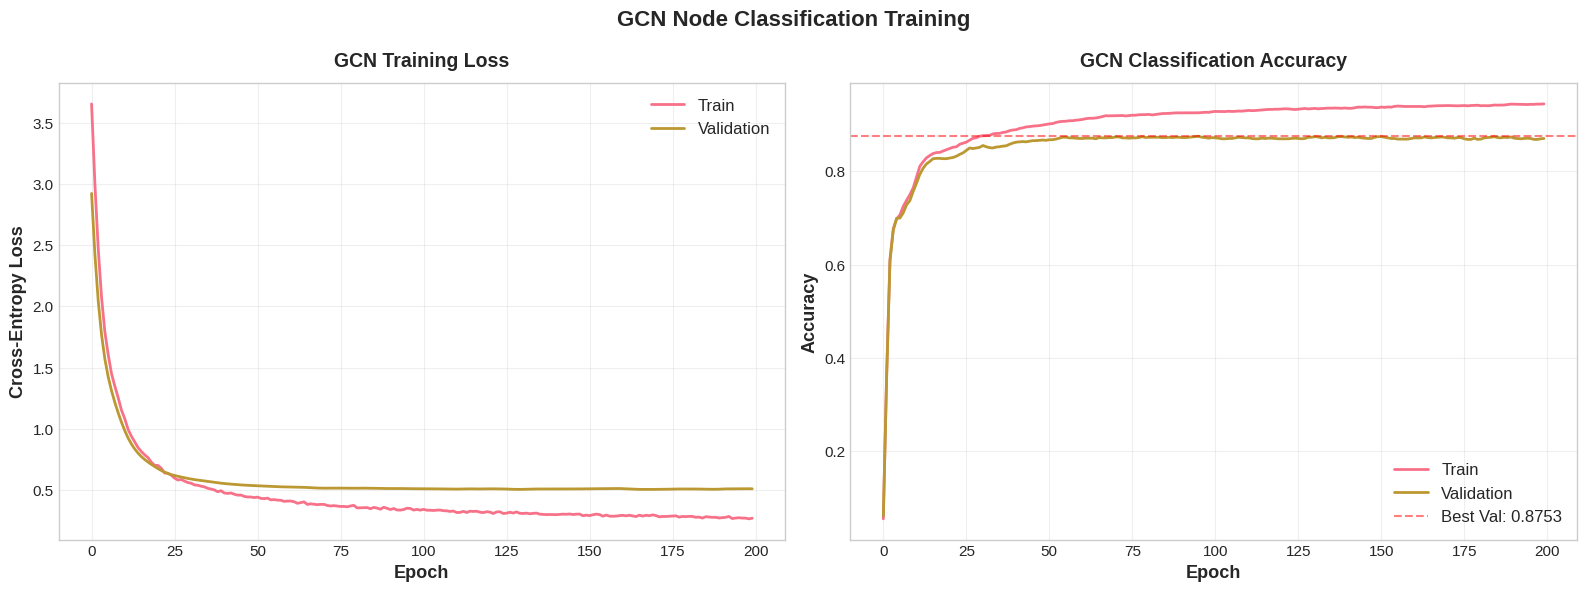

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=13)
axes[0].set_title('GCN Training Loss', fontsize=14, pad=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
axes[1].axhline(best_val_acc, color='red', linestyle='--', alpha=0.5,
                label=f'Best Val: {best_val_acc:.4f}')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Accuracy', fontsize=13)
axes[1].set_title('GCN Classification Accuracy', fontsize=14, pad=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GCN Node Classification Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Final test evaluation
test_acc, test_loss = eval_gcn(model_gcn, X_tensor, A_hat_tensor, y_tensor, test_mask)

model_gcn.eval()
with torch.no_grad():
    logits = model_gcn(X_tensor, A_hat_tensor)
    test_pred = logits[test_mask].argmax(dim=1).cpu().numpy()
    test_true = y_tensor[test_mask].cpu().numpy()

print("=== GCN Test Results ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"\nMacro F1: {f1_score(test_true, test_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(test_true, test_pred, average='weighted'):.4f}")
print(f"\n--- Classification Report (Test Set) ---")
print(classification_report(test_true, test_pred, zero_division=0))

=== GCN Test Results ===
Test Accuracy: 0.8945
Test Loss: 0.4721

Macro F1: 0.8201
Weighted F1: 0.8916

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       213
           1       1.00      0.80      0.89         5
           2       1.00      0.82      0.90        17
           3       0.90      0.93      0.91       112
           4       0.00      0.00      0.00         5
           5       0.95      0.81      0.87        85
           6       0.81      0.80      0.80       129
           7       1.00      0.70      0.82        20
           8       0.95      0.94      0.94        93
           9       0.86      0.60      0.71        10
          10       0.88      0.96      0.92       230
          11       1.00      0.90      0.95        30
          12       0.91      0.71      0.80        14
          13       1.00      0.69      0.82        13
          14       0.88      0.84      0.86 

GCN embedding shape: (7624, 64)
Computing t-SNE of GCN embeddings...


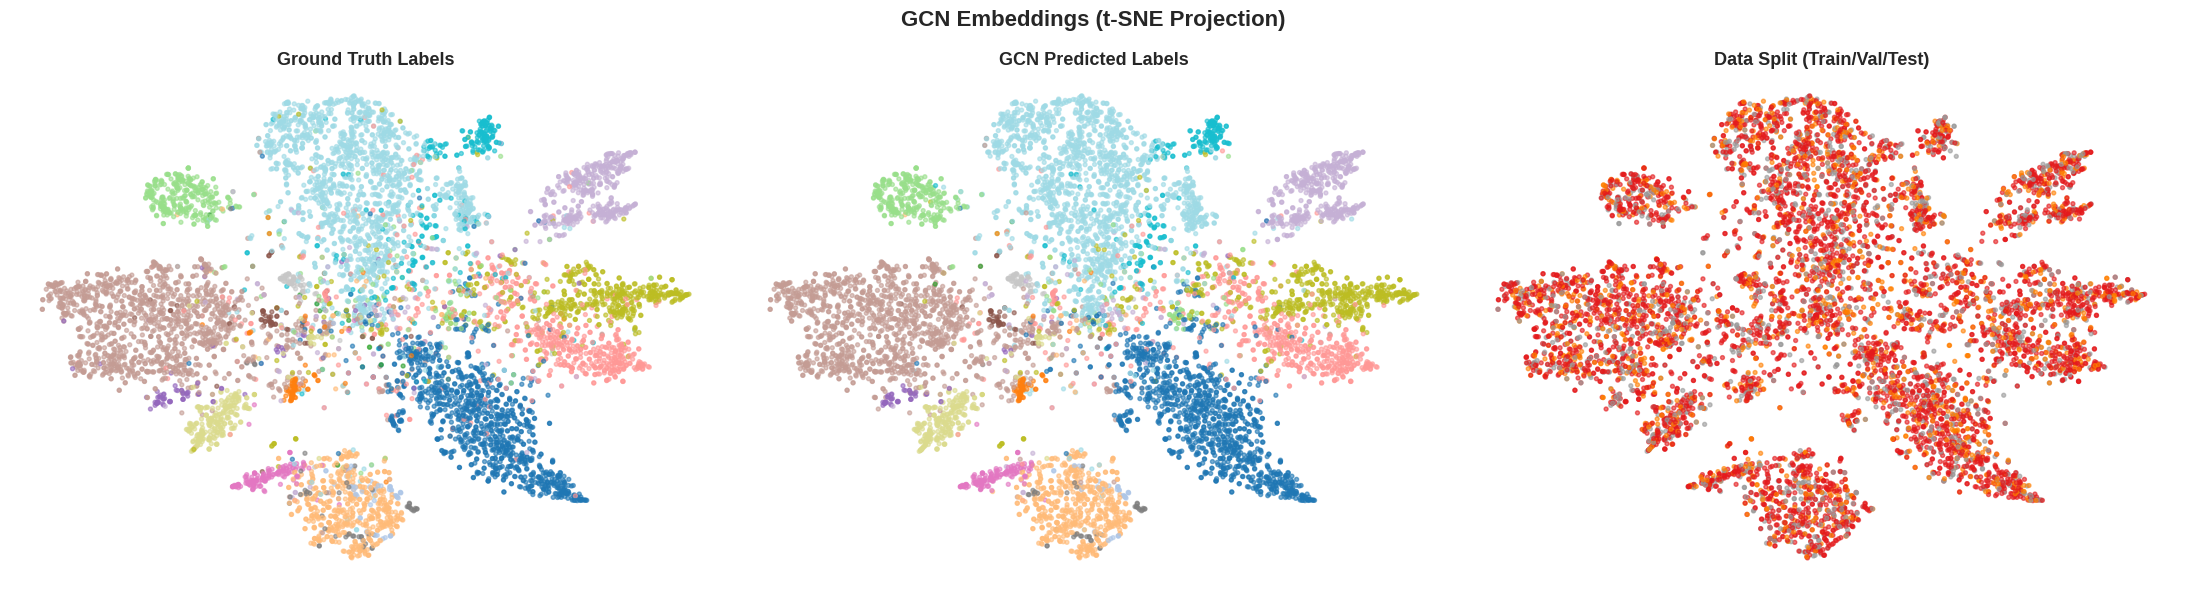

In [ ]:
# Extract GCN hidden layer embeddings
model_gcn.eval()
gcn_embeddings = model_gcn.get_embedding(X_tensor, A_hat_tensor).cpu().numpy()
print(f"GCN embedding shape: {gcn_embeddings.shape}")

# t-SNE visualization
print("Computing t-SNE of GCN embeddings...")
tsne_gcn = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
gcn_2d = tsne_gcn.fit_transform(gcn_embeddings)

# Also get predicted labels for all nodes
with torch.no_grad():
    all_pred = model_gcn(X_tensor, A_hat_tensor).argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=y, cmap='tab20', s=8, alpha=0.6)
axes[0].set_title('Ground Truth Labels', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=all_pred, cmap='tab20', s=8, alpha=0.6)
axes[1].set_title('GCN Predicted Labels', fontsize=13, fontweight='bold')
axes[1].axis('off')

# Color by train/val/test split
split_colors = np.zeros(n_nodes)
split_colors[train_mask.numpy()] = 0
split_colors[val_mask.numpy()] = 1
split_colors[test_mask.numpy()] = 2
axes[2].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=split_colors, cmap='Set1', s=8, alpha=0.6)
axes[2].set_title('Data Split (Train/Val/Test)', fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle('GCN Embeddings (t-SNE Projection)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

### 3.1 GCN on Cisco

We now apply the GCN to the Cisco network. Unlike LastFM where we have natural node features (artist preferences), Cisco requires **feature engineering**.

#### Feature Construction

We create node features from **port usage patterns**: for each node, a binary vector indicating which ports it participates in (either as source or destination). This makes sense because:

- A **web server** will appear on ports 80/443 (HTTP/HTTPS)
- A **DNS server** will appear on port 53
- A **mail server** will appear on ports 25/587 (SMTP)

The port usage pattern directly reflects the node's **functional role**, which is exactly what the ground truth groups capture. So these features are semantically aligned with the classification task.

#### Pipeline

```
Port usage binary features (52 nodes × N_ports dimensions)
    │
    ▼  (No SVD needed — feature dimension is already manageable)
Normalized Adjacency: Â = D̃^{-1/2} Ã D̃^{-1/2}
    ▼
2-layer GCN: features → 32-dim hidden → N_groups classes
    ▼
Cross-entropy loss → Predict ground truth group
```

**Important difference from LastFM:** The Cisco network has only 52 nodes, so we use a smaller hidden dimension (32 instead of 64) and need to be careful about overfitting. We use a higher train ratio since we have very few nodes per class.

---


In [ ]:
# === GCN on Cisco ===

# Build normalized adjacency (sparse, matching LastFM's approach for torch.sparse.mm)
A_cisco_adj = nx.adjacency_matrix(G_cisco, nodelist=cisco_nodes).astype(np.float32)
A_cisco_tilde = A_cisco_adj + speye(len(cisco_nodes), format='csr', dtype=np.float32)
D_cisco_tilde = np.array(A_cisco_tilde.sum(axis=1)).flatten()
D_cisco_inv_sqrt_mat = diags(1.0 / np.sqrt(np.maximum(D_cisco_tilde, 1e-12)))
A_hat_cisco_scipy = D_cisco_inv_sqrt_mat @ A_cisco_tilde @ D_cisco_inv_sqrt_mat

# Convert to torch sparse (required by torch.sparse.mm in GCNLayer)
A_hat_cisco_tensor = scipy_to_torch_sparse(A_hat_cisco_scipy).to(device)

# Features: port usage binary matrix (already built in data loading section)
X_cisco_tensor = torch.FloatTensor(cisco_port_features).to(device)

# Labels: only nodes WITH ground truth labels (-1 means unlabeled, excluded from all masks)
# Remap GT labels to 0..N so cross_entropy doesn't see -1
cisco_labeled_idx = np.where(cisco_labeled_mask)[0]  # indices of labeled nodes
cisco_y_labeled = cisco_y[cisco_labeled_idx]           # labels 0..22 for those nodes
n_labeled = len(cisco_labeled_idx)

# Build a full label tensor (unlabeled nodes stay 0, masks ensure they're never used)
y_cisco_tensor = torch.LongTensor(np.where(cisco_labeled_mask, cisco_y, 0)).to(device)

# Train/val/test split over LABELED nodes only (70/15/15)
rng = np.random.RandomState(42)
perm_labeled = rng.permutation(n_labeled)
n_train_c = int(0.70 * n_labeled)
n_val_c   = int(0.15 * n_labeled)

cisco_train_mask = torch.zeros(len(cisco_nodes), dtype=torch.bool)
cisco_val_mask   = torch.zeros(len(cisco_nodes), dtype=torch.bool)
cisco_test_mask  = torch.zeros(len(cisco_nodes), dtype=torch.bool)

cisco_train_mask[cisco_labeled_idx[perm_labeled[:n_train_c]]]              = True
cisco_val_mask  [cisco_labeled_idx[perm_labeled[n_train_c:n_train_c+n_val_c]]] = True
cisco_test_mask [cisco_labeled_idx[perm_labeled[n_train_c+n_val_c:]]]      = True

print(f"Cisco GCN setup:")
print(f"  Feature dim: {cisco_port_features.shape[1]}")
print(f"  Labeled nodes: {n_labeled}/{len(cisco_nodes)}")
print(f"  Train/Val/Test: {cisco_train_mask.sum()}/{cisco_val_mask.sum()}/{cisco_test_mask.sum()}")
print(f"  Classes: {cisco_n_gt_groups}")

# Build GCN
cisco_gcn = GCN(in_features=cisco_port_features.shape[1],
                hidden_dim=32,
                out_features=cisco_n_gt_groups).to(device)
cisco_gcn_opt = torch.optim.Adam(cisco_gcn.parameters(), lr=0.01, weight_decay=5e-4)

# Training loop
cisco_gcn_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_cisco = 0.0
best_state_cisco   = {k: v.clone() for k, v in cisco_gcn.state_dict().items()}
patience_cisco     = 0

for epoch in range(300):
    train_loss = train_gcn_epoch(cisco_gcn, X_cisco_tensor, A_hat_cisco_tensor,
                                 y_cisco_tensor, cisco_train_mask, cisco_gcn_opt)
    train_acc, _        = eval_gcn(cisco_gcn, X_cisco_tensor, A_hat_cisco_tensor,
                                   y_cisco_tensor, cisco_train_mask)
    val_acc, val_loss   = eval_gcn(cisco_gcn, X_cisco_tensor, A_hat_cisco_tensor,
                                   y_cisco_tensor, cisco_val_mask)

    cisco_gcn_history['train_loss'].append(train_loss)
    cisco_gcn_history['val_loss'].append(val_loss)
    cisco_gcn_history['train_acc'].append(train_acc)
    cisco_gcn_history['val_acc'].append(val_acc)

    if val_acc > best_val_acc_cisco:
        best_val_acc_cisco = val_acc
        patience_cisco     = 0
        best_state_cisco   = {k: v.clone() for k, v in cisco_gcn.state_dict().items()}
    else:
        patience_cisco += 1
        if patience_cisco >= 50:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train acc={train_acc:.3f}, Val acc={val_acc:.3f}")

# Evaluate best model
cisco_gcn.load_state_dict(best_state_cisco)
cisco_test_acc, cisco_test_loss = eval_gcn(cisco_gcn, X_cisco_tensor, A_hat_cisco_tensor,
                                            y_cisco_tensor, cisco_test_mask)
print(f"\nCisco GCN Test accuracy: {cisco_test_acc:.4f} ({cisco_test_acc*100:.1f}%)")

# Extract hidden-layer embeddings for all nodes
cisco_gcn_embeddings = cisco_gcn.get_embedding(X_cisco_tensor, A_hat_cisco_tensor).cpu().numpy()
print(f"Cisco GCN embeddings: {cisco_gcn_embeddings.shape}")


Cisco GCN setup:
  Feature dim: 2369
  Labeled nodes: 52/52
  Train/Val/Test: 36/7/9
  Classes: 23
Epoch 50: Train acc=0.528, Val acc=0.143
Early stopping at epoch 98

Cisco GCN Test accuracy: 0.2222 (22.2%)
Cisco GCN embeddings: (52, 32)


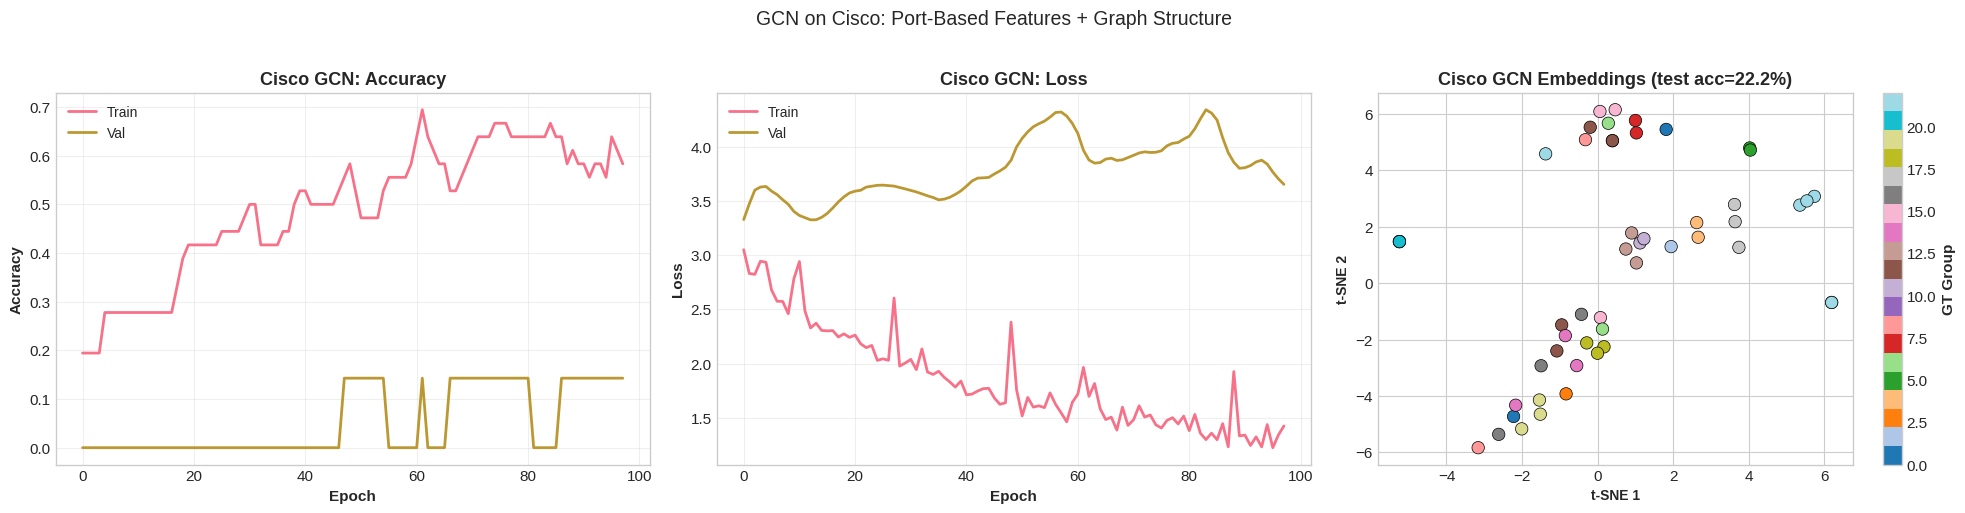


Cisco GCN → K-Means Community Detection:
  Modularity: -0.1097, NMI: 0.7633, ARI: 0.1896, AMI: 0.3311


In [ ]:
# === Cisco GCN Visualization ===
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Training curves
axes[0].plot(cisco_gcn_history['train_acc'], label='Train', linewidth=2)
axes[0].plot(cisco_gcn_history['val_acc'], label='Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Cisco GCN: Accuracy', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cisco_gcn_history['train_loss'], label='Train', linewidth=2)
axes[1].plot(cisco_gcn_history['val_loss'], label='Val', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Cisco GCN: Loss', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# t-SNE of embeddings
tsne_cisco_gcn = TSNE(n_components=2, random_state=42, perplexity=min(15, len(cisco_nodes)-1))
cisco_gcn_2d = tsne_cisco_gcn.fit_transform(cisco_gcn_embeddings)
scatter = axes[2].scatter(cisco_gcn_2d[:, 0], cisco_gcn_2d[:, 1],
                          c=cisco_y, cmap='tab20', s=80, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'Cisco GCN Embeddings (test acc={cisco_test_acc*100:.1f}%)', fontsize=13)
axes[2].set_xlabel('t-SNE 1', fontsize=10)
axes[2].set_ylabel('t-SNE 2', fontsize=10)
plt.colorbar(scatter, ax=axes[2], label='GT Group')

plt.suptitle('GCN on Cisco: Port-Based Features + Graph Structure', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Community detection from Cisco GCN embeddings
kmeans_cisco_gcn = KMeans(n_clusters=cisco_n_gt_groups, random_state=42, n_init=10)
cisco_gcn_labels = kmeans_cisco_gcn.fit_predict(cisco_gcn_embeddings)

labeled_idx_c = [i for i, n in enumerate(cisco_nodes) if n in cisco_node_to_gt]
nmi_c = normalized_mutual_info_score(cisco_y[labeled_idx_c], cisco_gcn_labels[labeled_idx_c])
ari_c = adjusted_rand_score(cisco_y[labeled_idx_c], cisco_gcn_labels[labeled_idx_c])
ami_c = adjusted_mutual_info_score(cisco_y[labeled_idx_c], cisco_gcn_labels[labeled_idx_c])

communities_cisco_gcn = defaultdict(set)
for i, lab in enumerate(cisco_gcn_labels):
    communities_cisco_gcn[lab].add(cisco_nodes[i])
mod_c = nx_community.modularity(G_cisco, list(communities_cisco_gcn.values()))

print(f"\nCisco GCN → K-Means Community Detection:")
print(f"  Modularity: {mod_c:.4f}, NMI: {nmi_c:.4f}, ARI: {ari_c:.4f}, AMI: {ami_c:.4f}")

---

## 4. Link Prediction with GNN

### Why Link Prediction?

We add link prediction as a second GNN task because it gives us a different kind of embedding. While node classification learns embeddings that separate classes, link prediction learns embeddings where connected nodes are close together. This is more directly related to community structure.

### How It Works (Simple Version)

1. We hide some edges from the graph (test edges) and train the GCN on the remaining edges
2. The GCN learns node embeddings from the partial graph
3. To predict if an edge exists between two nodes, we take the dot product of their embeddings — if the score is high, the model thinks they should be connected
4. We also sample random non-edges as negative examples, so the model learns to tell real edges from fake ones

### The Link Prediction Pipeline in Detail

```
Original Graph (7,624 nodes, 27,806 edges)
    │
    ▼
Edge Split: 85% train / 5% val / 10% test
    │  IMPORTANT: We split EDGES, not nodes. The GCN still sees all nodes,
    │  but some edges are hidden during training. This tests whether the
    │  model can predict missing connections.
    │
    │  The training graph has ~23,635 edges. The GCN does message passing
    │  ONLY on training edges — it never sees val/test edges during training.
    ▼
Negative Sampling: For each positive edge (u,v), sample one random non-edge (u,w)
    │  Why equal positives and negatives? With 27,806 edges out of ~58M possible
    │  pairs (density 0.096%), random pairs are almost certainly non-edges.
    │  If we used all non-edges, the model would learn to just predict "no edge"
    │  for everything. Equal sampling forces the model to learn real patterns.
    ▼
GCN Encoder: Same architecture as classification (2-layer, 128→64→embedding_dim)
    │  But trained on the PARTIAL graph (training edges only).
    │  Input features are the same SVD-reduced artist preferences.
    ▼
Dot-Product Decoder: score(u,v) = σ(z_u · z_v)
    │  The dot product measures similarity in embedding space.
    │  Sigmoid σ converts to a probability in [0,1].
    │
    │  Why dot product and not something more complex? It is the simplest
    │  decoder and directly encourages connected nodes to have similar
    │  embeddings. More complex decoders (e.g., MLP) could learn non-linear
    │  patterns but are harder to interpret and more prone to overfitting.
    ▼
Binary Cross-Entropy Loss: L = -[y·log(p) + (1-y)·log(1-p)]
    │  Treats link prediction as binary classification: edge or non-edge.
    │  This optimizes for DISCRIMINATION (is this an edge or not?)
    │  but NOT for RANKING (where does the true target rank among all candidates?).
    │  This distinction is critical — it explains why the GCN gets high AUC
    │  but poor ranking metrics (MRR, Hits@K) later.
    ▼
Evaluation:
    1. Binary edge classification: AUC, Average Precision
       → "Does an edge exist between u and v?" (binary yes/no)
    2. Entity ranking (head + tail prediction): MR, MRR, Hits@K
       → "Given node u, rank the true neighbor v among ALL candidates"
       → We compute both tail prediction (given u, rank v) and head
         prediction (given v, rank u), then average — matching the
         standard KGE evaluation protocol used by PyKEEN.
```

### Two Evaluation Paradigms

It is important to distinguish the two evaluation modes:

1. **Binary edge classification (AUC, AP):** Given a pair (u, v), predict whether an edge exists. This is a binary classification task. The GCN with dot-product decoder is directly trained for this via BCE loss.

2. **Entity ranking (MR, MRR, Hits@K):** Given one endpoint, rank the true partner among all possible nodes. This is a retrieval/ranking task. We evaluate in both directions (head and tail prediction) and average, matching the standard KGE evaluation protocol. The GCN is NOT trained for this — it is only trained for binary classification — so we expect it to perform much worse on ranking than on AUC.

This distinction matters because the KGE models (TransE, RotatE, DistMult) in Section 6.1 are trained specifically for entity ranking with margin-based loss, giving them a direct advantage on ranking metrics.

### Why Binary Cross-Entropy Hurts Ranking

This is a key insight: the GCN link predictor is trained with **binary cross-entropy**, which only asks "is this pair an edge or not?" It does not force the model to distinguish between the correct target and other plausible candidates. As long as true edges score above 0.5 and non-edges below 0.5, the loss is satisfied.

**Ranking metrics** (MRR, Hits@K) ask a much harder question: "given node u, can you rank the correct neighbor v above ALL other nodes?" This requires fine-grained score differences that binary classification does not learn. This is exactly why TransE and RotatE (trained with margin-based ranking loss) will massively outperform the GCN on ranking despite all models learning node embeddings.

### Why This Matters for Community Detection

The embeddings from link prediction should capture who is likely connected to who. Since community structure is all about connection patterns, we expect these embeddings to be useful for community detection too. We will later apply K-means to these embeddings and compare with the other methods.

---


In [ ]:
# Split edges into train/val/test
random.seed(42)
np.random.seed(42)

all_edges = list(G.edges())
random.shuffle(all_edges)

n_test_edges = int(0.1 * len(all_edges))
n_val_edges = int(0.1 * len(all_edges))

test_pos_edges = all_edges[:n_test_edges]
val_pos_edges = all_edges[n_test_edges:n_test_edges + n_val_edges]
train_pos_edges = all_edges[n_test_edges + n_val_edges:]

# Build training graph (message passing uses only train edges)
G_train_lp = nx.Graph()
G_train_lp.add_nodes_from(nodes)
G_train_lp.add_edges_from(train_pos_edges)

# Negative sampling
existing_edges = set(G.edges()) | set((v, u) for u, v in G.edges())
nodes_list = list(nodes)

def sample_negatives(n_samples, exclude_set, seed=None):
    if seed is not None:
        random.seed(seed)
    neg = []
    while len(neg) < n_samples:
        u = random.choice(nodes_list)
        v = random.choice(nodes_list)
        if u != v and (u, v) not in exclude_set and (v, u) not in exclude_set:
            neg.append((u, v))
            exclude_set.add((u, v))
    return neg

test_neg_edges = sample_negatives(n_test_edges, existing_edges.copy(), seed=42)
val_neg_edges = sample_negatives(n_val_edges, existing_edges.copy(), seed=43)
train_neg_edges = sample_negatives(len(train_pos_edges), existing_edges.copy(), seed=44)

# Compute A_hat for training graph
A_train_adj = nx.adjacency_matrix(G_train_lp, nodelist=nodes).astype(np.float32)
A_tilde_train = A_train_adj + speye(n_nodes, format='csr')
D_tilde_train_vals = np.array(A_tilde_train.sum(axis=1)).flatten()
D_inv_sqrt_train = diags(1.0 / np.sqrt(np.maximum(D_tilde_train_vals, 1e-12)))
A_hat_train_scipy = D_inv_sqrt_train @ A_tilde_train @ D_inv_sqrt_train
A_hat_train_tensor = scipy_to_torch_sparse(A_hat_train_scipy).to(device)

# Convert edges to index tensors
def edges_to_indices(edge_list):
    src = torch.LongTensor([node_to_idx[u] for u, v in edge_list])
    dst = torch.LongTensor([node_to_idx[v] for u, v in edge_list])
    return torch.stack([src, dst]).to(device)

train_pos_idx = edges_to_indices(train_pos_edges)
train_neg_idx = edges_to_indices(train_neg_edges)
val_pos_idx = edges_to_indices(val_pos_edges)
val_neg_idx = edges_to_indices(val_neg_edges)
test_pos_idx = edges_to_indices(test_pos_edges)
test_neg_idx = edges_to_indices(test_neg_edges)

print("=== Link Prediction Edge Split ===")
print(f"Total edges: {len(all_edges):,}")
print(f"Train: {len(train_pos_edges):,} pos + {len(train_neg_edges):,} neg")
print(f"Val:   {n_val_edges:,} pos + {len(val_neg_edges):,} neg")
print(f"Test:  {n_test_edges:,} pos + {len(test_neg_edges):,} neg")
print(f"Training graph density: {nx.density(G_train_lp):.6f}")

=== Link Prediction Edge Split ===
Total edges: 27,806
Train: 22,246 pos + 22,246 neg
Val:   2,780 pos + 2,780 neg
Test:  2,780 pos + 2,780 neg
Training graph density: 0.000766


**We do as many negative has positive so the model doesnt get affected by the vast number of possible pairs: 27,806 edges out of ~7,624² ≈ 58 million**

**As you can see the density is very low.**

In [ ]:
class GCNLinkPredictor(nn.Module):
    """GCN encoder + dot product decoder for link prediction."""
    def __init__(self, in_features, hidden_dim, emb_dim, dropout=0.3):
        super().__init__()
        self.gc1 = GCNLayer(in_features, hidden_dim)
        self.gc2 = GCNLayer(hidden_dim, emb_dim)
        self.dropout = dropout

    def encode(self, X, A_hat):
        h = F.relu(self.gc1(X, A_hat))
        h = F.dropout(h, self.dropout, training=self.training)
        z = self.gc2(h, A_hat)
        return z

    def decode(self, z, edge_index):
        """Dot product decoder: score = z_u^T * z_v"""
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)

    def forward(self, X, A_hat, pos_edge_index, neg_edge_index):
        z = self.encode(X, A_hat)
        pos_score = self.decode(z, pos_edge_index)
        neg_score = self.decode(z, neg_edge_index)
        return pos_score, neg_score


model_lp = GCNLinkPredictor(
    in_features=X_reduced.shape[1],
    hidden_dim=128,
    emb_dim=64,
    dropout=0.3
).to(device)

optimizer_lp = Adam(model_lp.parameters(), lr=0.01, weight_decay=1e-5)

print(f"Link Predictor: {X_reduced.shape[1]} -> 128 -> 64")
print(f"Parameters: {sum(p.numel() for p in model_lp.parameters()):,}")

Link Predictor: 128 -> 128 -> 64
Parameters: 24,768


In [ ]:
def train_lp_epoch(model, X, A_hat, pos_idx, neg_idx, optimizer):
    model.train()
    optimizer.zero_grad()

    pos_score, neg_score = model(X, A_hat, pos_idx, neg_idx)

    # Binary cross-entropy loss
    pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-15).mean()
    neg_loss = -torch.log(1 - torch.sigmoid(neg_score) + 1e-15).mean()
    loss = pos_loss + neg_loss

    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def eval_lp(model, X, A_hat, pos_idx, neg_idx):
    model.eval()
    pos_score, neg_score = model(X, A_hat, pos_idx, neg_idx)

    pos_probs = torch.sigmoid(pos_score).cpu().numpy()
    neg_probs = torch.sigmoid(neg_score).cpu().numpy()

    y_true = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])
    y_score = np.concatenate([pos_probs, neg_probs])

    auc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    return auc, ap


# Training
n_epochs_lp = 200
lp_history = {'loss': [], 'val_auc': [], 'val_ap': []}
best_val_auc = 0

print("Training GCN Link Predictor...")
for epoch in range(1, n_epochs_lp + 1):
    loss = train_lp_epoch(model_lp, X_tensor, A_hat_train_tensor,
                          train_pos_idx, train_neg_idx, optimizer_lp)
    val_auc, val_ap = eval_lp(model_lp, X_tensor, A_hat_train_tensor,
                               val_pos_idx, val_neg_idx)

    lp_history['loss'].append(loss)
    lp_history['val_auc'].append(val_auc)
    lp_history['val_ap'].append(val_ap)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_lp_state = {k: v.clone() for k, v in model_lp.state_dict().items()}

    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

model_lp.load_state_dict(best_lp_state)
print(f"\nBest validation AUC: {best_val_auc:.4f}")

Training GCN Link Predictor...
  Epoch  50 | Loss: 0.7792 | Val AUC: 0.9474 | Val AP: 0.9536
  Epoch 100 | Loss: 0.6984 | Val AUC: 0.9416 | Val AP: 0.9494
  Epoch 150 | Loss: 0.6328 | Val AUC: 0.9319 | Val AP: 0.9403
  Epoch 200 | Loss: 0.5822 | Val AUC: 0.9210 | Val AP: 0.9250

Best validation AUC: 0.9479


=== Link Prediction Test Results ===
Test AUC:  0.9434
Test AP:   0.9517


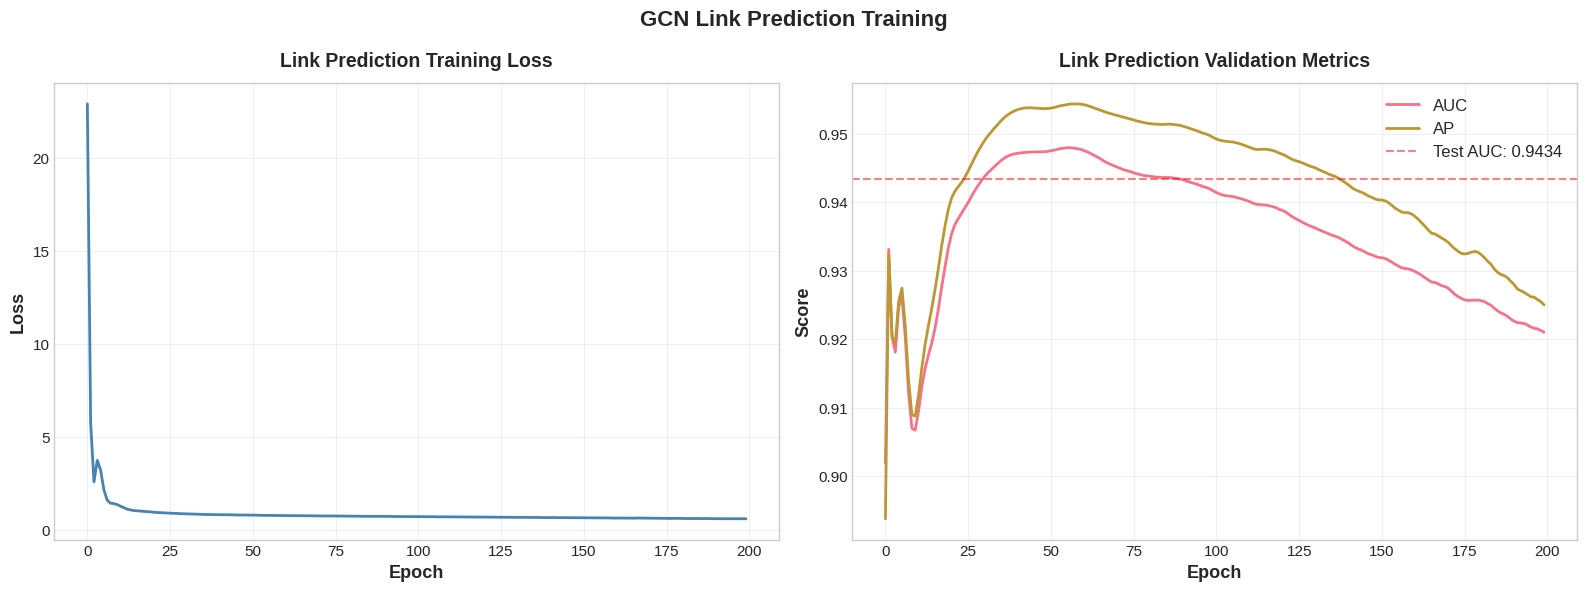

In [ ]:
# Test evaluation
test_auc, test_ap = eval_lp(model_lp, X_tensor, A_hat_train_tensor,
                             test_pos_idx, test_neg_idx)

print("=== Link Prediction Test Results ===")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Test AP:   {test_ap:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(lp_history['loss'], linewidth=2, color='steelblue')
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Loss', fontsize=13)
axes[0].set_title('Link Prediction Training Loss', fontsize=14, pad=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(lp_history['val_auc'], label='AUC', linewidth=2)
axes[1].plot(lp_history['val_ap'], label='AP', linewidth=2)
axes[1].axhline(test_auc, color='red', linestyle='--', alpha=0.5, label=f'Test AUC: {test_auc:.4f}')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Score', fontsize=13)
axes[1].set_title('Link Prediction Validation Metrics', fontsize=14, pad=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GCN Link Prediction Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

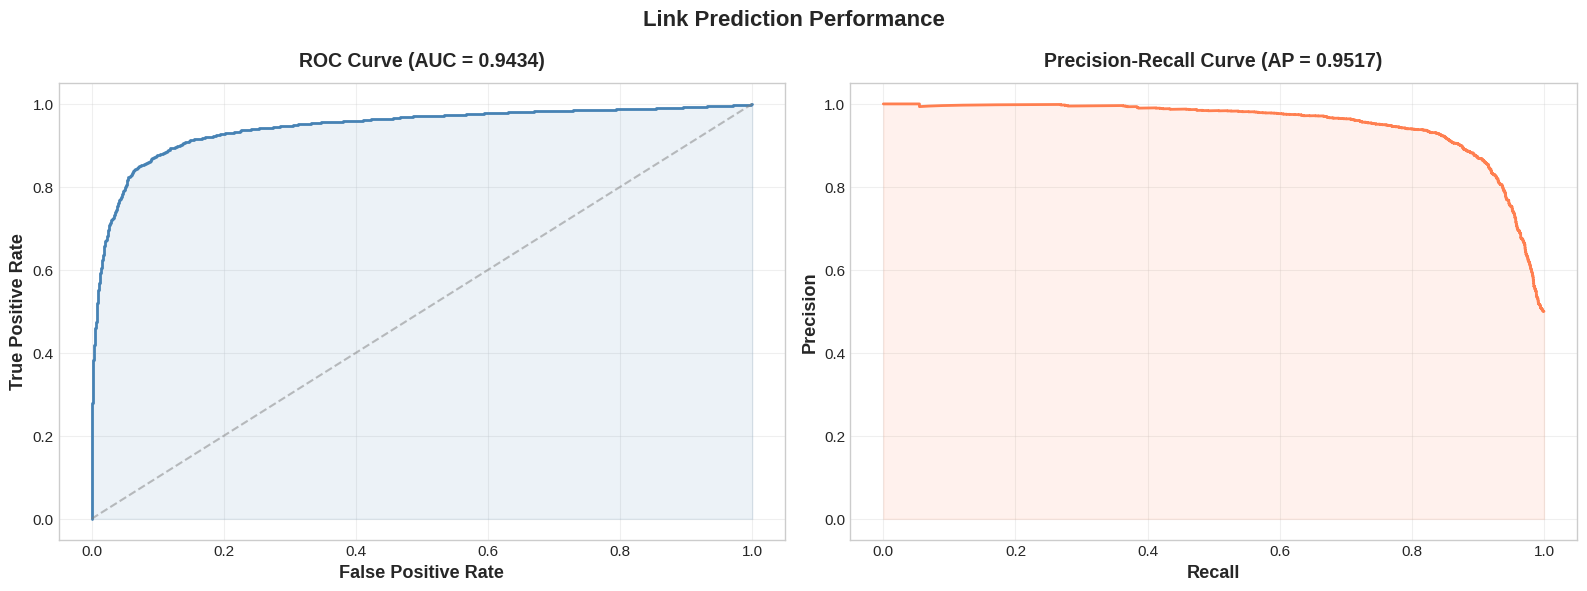

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Get test predictions
model_lp.eval()
with torch.no_grad():
    z_lp = model_lp.encode(X_tensor, A_hat_train_tensor)
    pos_scores = model_lp.decode(z_lp, test_pos_idx).cpu().numpy()
    neg_scores = model_lp.decode(z_lp, test_neg_idx).cpu().numpy()

y_true_test = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
y_scores_test = np.concatenate([torch.sigmoid(torch.tensor(pos_scores)).numpy(),
                                 torch.sigmoid(torch.tensor(neg_scores)).numpy()])

fpr, tpr, _ = roc_curve(y_true_test, y_scores_test)
precision_curve, recall_curve, _ = precision_recall_curve(y_true_test, y_scores_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(fpr, tpr, linewidth=2, color='steelblue')
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title(f'ROC Curve (AUC = {test_auc:.4f})', fontsize=14, pad=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall_curve, precision_curve, linewidth=2, color='coral')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.1, color='coral')
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title(f'Precision-Recall Curve (AP = {test_ap:.4f})', fontsize=14, pad=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Link Prediction Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Computing ranking metrics on test edges (head + tail, matching KGE practice)...

=== Entity Ranking Metrics — GCN Dot-Product Decoder (Test Set) ===
Evaluation: head + tail prediction averaged (matches PyKEEN 'both' mode)
Mean Rank (MR):              448.82  (out of 7624 nodes)
Mean Reciprocal Rank (MRR):  0.0581
Hits@1:                      0.0174  (1.74%)
Hits@3:                      0.0471  (4.71%)
Hits@5:                      0.0782  (7.82%)
Hits@10:                     0.1282  (12.82%)

Computed in 0.4s over 2780 test edges x 2 directions = 5560 queries


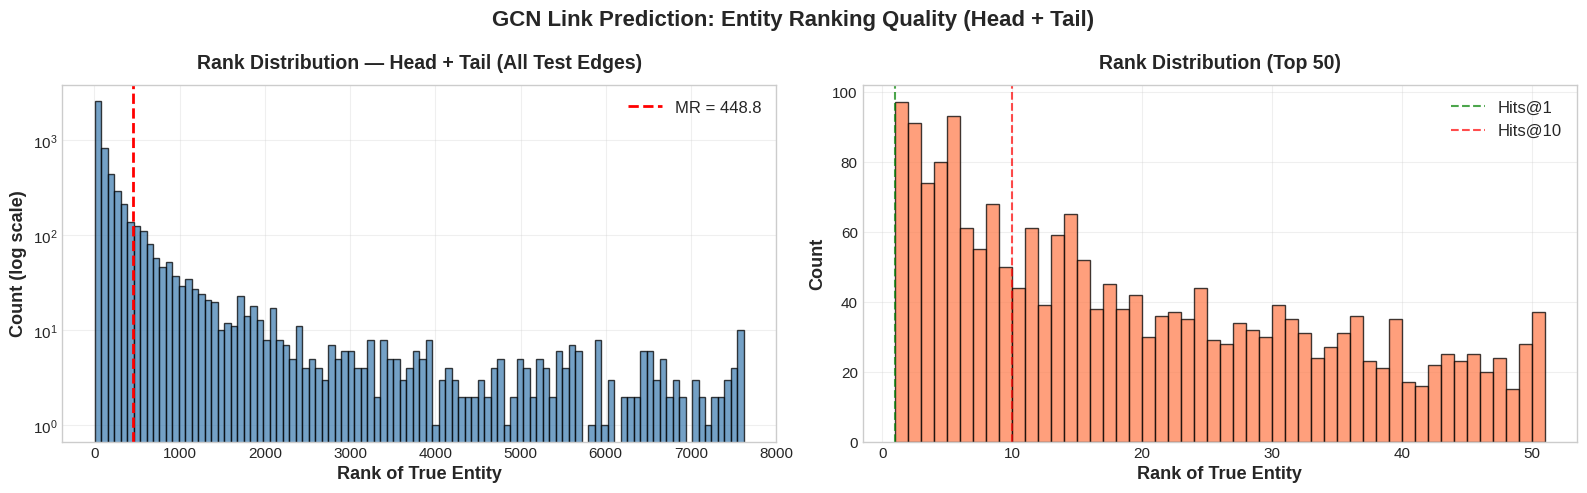

In [ ]:

# === Ranking-Based Evaluation: MR, MRR, Hits@K (Head + Tail) ===
# Following KGE evaluation practice, we compute BOTH:
#   - Tail ranking: given (u, ?), rank the true target v among all nodes
#   - Head ranking: given (?, v), rank the true source u among all nodes
# and average the results. This matches PyKEEN's "both" evaluation mode.

@torch.no_grad()
def compute_ranking_metrics(model, X, A_hat, test_pos_edges, node_to_idx, n_nodes, device, batch_size=512):
    """
    For each positive test edge (u, v):
      - Tail prediction: score(u, w) for all w, rank true v
      - Head prediction: score(w, v) for all w, rank true u
    Then compute MR, MRR, and Hits@K averaged over both directions.
    """
    model.eval()
    z = model.encode(X, A_hat)  # (n_nodes, emb_dim)

    tail_ranks = []
    head_ranks = []

    for start in range(0, len(test_pos_edges), batch_size):
        batch_edges = test_pos_edges[start:start + batch_size]

        for u, v in batch_edges:
            u_idx = node_to_idx[u]
            v_idx = node_to_idx[v]

            # --- Tail prediction: given u, rank v among all nodes ---
            u_emb = z[u_idx].unsqueeze(0)          # (1, emb_dim)
            tail_scores = (u_emb * z).sum(dim=1)    # (n_nodes,)
            true_tail_score = tail_scores[v_idx].item()
            tail_rank = (tail_scores > true_tail_score).sum().item() + 1
            tail_ranks.append(tail_rank)

            # --- Head prediction: given v, rank u among all nodes ---
            v_emb = z[v_idx].unsqueeze(0)          # (1, emb_dim)
            head_scores = (v_emb * z).sum(dim=1)    # (n_nodes,)
            true_head_score = head_scores[u_idx].item()
            head_rank = (head_scores > true_head_score).sum().item() + 1
            head_ranks.append(head_rank)

    tail_ranks = np.array(tail_ranks, dtype=np.float64)
    head_ranks = np.array(head_ranks, dtype=np.float64)
    # Average head and tail (matches KGE "both" evaluation)
    ranks = np.concatenate([tail_ranks, head_ranks])

    mr = ranks.mean()
    mrr = (1.0 / ranks).mean()
    hits_at_1 = (ranks <= 1).mean()
    hits_at_3 = (ranks <= 3).mean()
    hits_at_5 = (ranks <= 5).mean()
    hits_at_10 = (ranks <= 10).mean()

    return {
        'MR': mr,
        'MRR': mrr,
        'Hits@1': hits_at_1,
        'Hits@3': hits_at_3,
        'Hits@5': hits_at_5,
        'Hits@10': hits_at_10,
        'ranks': ranks,
        'tail_ranks': tail_ranks,
        'head_ranks': head_ranks
    }


print("Computing ranking metrics on test edges (head + tail, matching KGE practice)...")
t0 = time.time()
ranking_results = compute_ranking_metrics(
    model_lp, X_tensor, A_hat_train_tensor,
    test_pos_edges, node_to_idx, n_nodes, device
)
elapsed = time.time() - t0

print(f"\n=== Entity Ranking Metrics — GCN Dot-Product Decoder (Test Set) ===")
print(f"Evaluation: head + tail prediction averaged (matches PyKEEN 'both' mode)")
print(f"Mean Rank (MR):              {ranking_results['MR']:.2f}  (out of {n_nodes} nodes)")
print(f"Mean Reciprocal Rank (MRR):  {ranking_results['MRR']:.4f}")
print(f"Hits@1:                      {ranking_results['Hits@1']:.4f}  ({ranking_results['Hits@1']*100:.2f}%)")
print(f"Hits@3:                      {ranking_results['Hits@3']:.4f}  ({ranking_results['Hits@3']*100:.2f}%)")
print(f"Hits@5:                      {ranking_results['Hits@5']:.4f}  ({ranking_results['Hits@5']*100:.2f}%)")
print(f"Hits@10:                     {ranking_results['Hits@10']:.4f}  ({ranking_results['Hits@10']*100:.2f}%)")
print(f"\nComputed in {elapsed:.1f}s over {len(test_pos_edges)} test edges x 2 directions = {2*len(test_pos_edges)} queries")

# Rank distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full distribution (log scale)
axes[0].hist(ranking_results['ranks'], bins=100, color='steelblue', edgecolor='black', alpha=0.75)
axes[0].set_yscale('log')
axes[0].set_xlabel('Rank of True Entity', fontsize=13)
axes[0].set_ylabel('Count (log scale)', fontsize=13)
axes[0].set_title('Rank Distribution — Head + Tail (All Test Edges)', fontsize=14, pad=12)
axes[0].axvline(ranking_results['MR'], color='red', linestyle='--', linewidth=2,
                label=f"MR = {ranking_results['MR']:.1f}")
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Zoomed-in: top 50 ranks
top_ranks = ranking_results['ranks'][ranking_results['ranks'] <= 50]
axes[1].hist(top_ranks, bins=range(1, 52), color='coral', edgecolor='black', alpha=0.75)
axes[1].set_xlabel('Rank of True Entity', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title(f'Rank Distribution (Top 50)', fontsize=14, pad=12)
axes[1].axvline(1, color='green', linestyle='--', alpha=0.7, label='Hits@1')
axes[1].axvline(10, color='red', linestyle='--', alpha=0.7, label='Hits@10')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GCN Link Prediction: Entity Ranking Quality (Head + Tail)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 5. Knowledge Graph Embedding Models for Link Prediction

We now move beyond GCN to dedicated knowledge graph embedding (KGE) models. These models were specifically designed for link prediction in multi-relational graphs, using ranking-based loss functions rather than binary cross-entropy. We compare three models from the lectures: **TransE** (translational), **RotatE** (rotational), and **DistMult** (bilinear).

### 5.1 TransE and RotatE for Link Prediction


The GCN link predictor above uses a dot-product decoder, which treats all edges the same way. The lecture on **Multi-Relational Graph Embeddings** (Part III) introduces a different family of methods: **translational embeddings**, which learn a vector for each relation type and score triples as geometric operations. We use [PyKEEN](https://github.com/pykeen/pykeen), an established library for knowledge graph embeddings, for tested and optimized implementations.

**Terminology note:** In the KG literature, "link prediction" typically refers to **entity ranking** (head/tail prediction): given a partial triple $(h, r, ?)$ or $(?, r, t)$, rank all candidate entities and evaluate with MR, MRR, and Hits@K. This differs from the binary edge classification (AUC) used by the GCN above. For clarity, we refer to the KGE evaluation as **entity ranking** and the GCN binary evaluation as **edge classification** throughout this section.

---

### Loss Functions: MarginRankingLoss vs NSSALoss

Before describing the models, we explain the two loss functions used to train them. **The choice of loss function is as important as the model architecture** — it determines what the embeddings learn to optimize.

#### MarginRankingLoss (Used for TransE)

The margin-based ranking loss is the standard loss from the original TransE paper (Bordes et al., 2013). For each positive triple $(h, r, t)$, we generate a corrupted (negative) triple $(h', r, t')$ by replacing either the head or tail with a random entity:

$$\mathcal{L} = \sum_{(h,r,t) \in \mathcal{G}} \sum_{(h',r,t') \in \mathcal{N}} \max\left(0,\ f_r(h,t) - f_r(h',t') + \gamma\right)$$

where $f_r(h,t) = \|\mathbf{h} + \mathbf{r} - \mathbf{t}\|$ is the scoring function and $\gamma$ is the margin hyperparameter.

**Intuition:** Push the score of correct triples **below** the score of corrupted triples by at least margin $\gamma$. If a corrupted triple already scores worse than the correct one by more than $\gamma$, the loss is zero (the model is confident enough). The margin prevents the trivial solution of making all scores equal.

**Why margin=1.0 for TransE:** With L2 norm scoring, distances are typically in the range [0, ~10]. A margin of 1.0 means the model needs a meaningful but not extreme gap between positive and negative scores. This is the standard choice from Bordes et al.

**Connection to the lecture:** This is the loss shown on slides 8-9 of the multi-relational embeddings lecture. The "corruption" process (replacing h or t with a random entity) is the negative sampling strategy that makes training tractable — we cannot compare against all possible negatives.

#### NSSALoss — Negative Sampling Self-Adversarial Loss (Used for RotatE)

The NSSA loss was introduced by Sun et al. (2019) specifically for RotatE. It improves upon basic margin-based loss by **weighting negative samples by difficulty**:

$$\mathcal{L} = -\log \sigma(\gamma - f_r(h,t)) - \sum_{i=1}^{n} p(h'_i, r, t'_i) \cdot \log \sigma(f_r(h'_i, r, t'_i) - \gamma)$$

where the self-adversarial weight for each negative sample is:

$$p(h'_j, r, t'_j) = \frac{\exp\left(\alpha \cdot f_r(h'_j, t'_j)\right)}{\sum_i \exp\left(\alpha \cdot f_r(h'_i, t'_i)\right)}$$

and $\alpha$ is the adversarial temperature, $\gamma$ is the margin, and $\sigma$ is the sigmoid function.

**The "self-adversarial" key idea:** Standard negative sampling treats all corrupted triples equally. But some negatives are "easy" (clearly wrong, e.g., replacing a person with a random object) and some are "hard" (plausible alternatives, e.g., replacing a person with someone similar). NSSA uses the **model's own current scores** to weight negatives — negatives that the model currently scores as plausible (low distance) get higher weight. This focuses training on the hardest, most informative examples.

**Why $\alpha=1.0$ and $\gamma=6.0$ for RotatE:** These are the hyperparameters from the original Sun et al. paper. The higher margin (6.0 vs 1.0) reflects RotatE's different score scale — rotation-based distances in complex space tend to be larger than TransE's L2 distances. The temperature $\alpha=1.0$ gives moderate sharpness to the negative weighting distribution.

#### Why Different Losses for Different Models?

| | MarginRankingLoss | NSSALoss |
|---|---|---|
| **Negative weighting** | All negatives equal | Harder negatives weighted more |
| **Gradient signal** | Uniform across negatives | Focused on informative negatives |
| **Best for** | Simple models (TransE) | Expressive models (RotatE) |
| **Risk** | Wastes gradient on easy negatives | Can be unstable if temperature too high |

**TransE + MarginRankingLoss** works well because TransE is a simple model — uniform negative sampling gives stable, predictable gradients. The model's capacity is limited, so it benefits from seeing many diverse negatives equally.

**RotatE + NSSALoss** works better because RotatE's complex-space rotations create a richer embedding space. With uniform negatives, RotatE quickly learns to score easy negatives correctly and then makes slow progress. Self-adversarial weighting keeps the training challenging by focusing on the negatives that the model is most confused about.

---

### Why TransE?

TransE (Bordes et al., 2013) is the canonical translational embedding model from the lecture. It is simple and scalable: it represents both entities and relations as vectors in $\mathbb{R}^d$, and scores a triple $(h, r, t)$ as:

$$f_r(h, t) = ||\mathbf{h} + \mathbf{r} - \mathbf{t}||_2$$

A low score means the triple is likely true. The relation $r$ acts as a **translation** from head $h$ to tail $t$ in embedding space. We start with TransE because it is the simplest baseline in this family and the lecture uses it to introduce the key concepts (margin-based ranking loss, negative sampling, corruption). But the lecture also clearly shows its **known limitations**:

| Relation Property | TransE Can Handle? | Why |
|---|---|---|
| **Symmetry**: $(h,r,t) \in \mathcal{G} \Rightarrow (t,r,h) \in \mathcal{G}$ | No | Forces $\mathbf{r} = \mathbf{0}$, collapsing $h$ and $t$ to the same point |
| **1-to-N**: $(h,r,t_1)$ and $(h,r,t_2) \in \mathcal{G}$ | No | Forces $\mathbf{t}_1 = \mathbf{t}_2$ (all tails collapse) |
| **N-to-N**: multiple heads to multiple tails | No | Same collapse problem in both directions |
| **Composition**: $r_3 = r_1 \circ r_2$ | Yes | $\mathbf{r}_3 \approx \mathbf{r}_1 + \mathbf{r}_2$ |
| **Antisymmetry** | Yes | $\mathbf{r} \neq \mathbf{0}$ naturally |

### Why This Matters for LastFM

Our LastFM dataset has **exactly the patterns that break TransE**:
- **All edges are symmetric** — friendship is bidirectional. TransE will be forced toward $\mathbf{r} \approx \mathbf{0}$.
- **77% of nodes have multiple friends** — massive 1-to-N. TransE will try to collapse all friends of a user to the same point.
- **High clustering (0.219)** — lots of N-to-N (shared friends).

We expect TransE to perform poorly on this dataset. We include it specifically to demonstrate these limitations from the lecture.

### Why RotatE?

RotatE (Sun et al., 2019) addresses TransE's failures by moving to **complex space** and modeling relations as **rotations** rather than translations:

$$\mathbf{t} = \mathbf{h} \circ \mathbf{r}, \quad |r_i| = 1 \text{ for all } i$$

where $\circ$ is the element-wise product in $\mathbb{C}^d$ and each $r_i = e^{i\theta_i}$ is a unit-modulus complex number (a rotation angle). The scoring function is: $f_r(h,t) = ||\mathbf{h} \circ \mathbf{r} - \mathbf{t}||$

| Relation Property | RotatE Can Handle? | How |
|---|---|---|
| **Symmetry** | Yes | Rotation by $\pi$ (i.e., $r_i = -1$): applying it twice returns to the start |
| **1-to-N** | Yes | Different entities can have different complex embeddings that map correctly under the same rotation |
| **N-to-N** | Yes | Rotation preserves distances, no collapse |
| **Composition** | Yes | $r_3 = r_1 \circ r_2$ (rotation composition) |
| **Inversion** | Yes | $r_2 = \bar{r}_1$ (conjugate = inverse rotation) |

Given that LastFM is entirely symmetric with heavy 1-to-N patterns, **RotatE should significantly outperform TransE** on this dataset.

### Evaluation

We use the same train/val/test edge split from the GCN link prediction above and evaluate with **ranking-based metrics** (MR, MRR, Hits@K) since the lecture (slides 24-26) identifies these as the standard for translational models. As the lecture notes: MR is sensitive to outliers, while MRR and Hits@K are more informative because they reward getting the answer at the top of the ranking.

---


In [ ]:
# === TransE and RotatE using PyKEEN (established KGE library) ===
# PyKEEN provides tested, optimized implementations of all major KGE models.
# Reference: https://github.com/pykeen/pykeen

from pykeen.triples import TriplesFactory
from pykeen.models import TransE as PyKEEN_TransE, RotatE as PyKEEN_RotatE
from pykeen.training import SLCWATrainingLoop
from pykeen.losses import MarginRankingLoss, NSSALoss
import torch

# --- Build triples from our existing edge split ---
# PyKEEN expects triples as (head, relation, tail) string arrays.
# LastFM has a single relation type: "friend"

def edges_to_triples(edge_list):
    """Convert edge list to numpy array of (head, relation, tail) string triples."""
    triples = []
    for u, v in edge_list:
        triples.append([str(u), 'friend', str(v)])
        triples.append([str(v), 'friend', str(u)])  # undirected -> both directions
    return np.array(triples)

train_triples = edges_to_triples(train_pos_edges)
val_triples = edges_to_triples(val_pos_edges)
test_triples = edges_to_triples(test_pos_edges)

# Create TriplesFactory (entity/relation mappings built from training set)
tf_train = TriplesFactory.from_labeled_triples(train_triples)
tf_val = TriplesFactory.from_labeled_triples(val_triples,
    entity_to_id=tf_train.entity_to_id, relation_to_id=tf_train.relation_to_id)
tf_test = TriplesFactory.from_labeled_triples(test_triples,
    entity_to_id=tf_train.entity_to_id, relation_to_id=tf_train.relation_to_id)

print(f"Training triples: {tf_train.num_triples}")
print(f"Validation triples: {tf_val.num_triples}")
print(f"Test triples: {tf_test.num_triples}")
print(f"Entities: {tf_train.num_entities}, Relations: {tf_train.num_relations}")
print(f"Device: {device}")

You're trying to map triples with 488 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 480 from 5560 triples were filtered out
You're trying to map triples with 448 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 436 from 5560 triples were filtered out


Training triples: 44492
Validation triples: 5080
Test triples: 5124
Entities: 7229, Relations: 1
Device: cuda


In [ ]:
# === Train TransE ===
# As per the lecture: margin-based ranking loss, entity embeddings in R^d

transe_model = PyKEEN_TransE(
    triples_factory=tf_train,
    embedding_dim=128,
    scoring_fct_norm=2,      # L2 norm as in lecture: ||h + r - t||_2
    loss=MarginRankingLoss(margin=1.0),  # margin-based ranking loss (lecture slide 9)
    random_seed=42,
).to(device)

transe_optimizer = torch.optim.Adam(transe_model.parameters(), lr=0.001)
transe_loop = SLCWATrainingLoop(model=transe_model, triples_factory=tf_train,
                                 optimizer=transe_optimizer)

print(f"TransE parameters: {sum(p.numel() for p in transe_model.parameters()):,}")
print("Training TransE...")
t0 = time.time()
transe_losses = transe_loop.train(
    triples_factory=tf_train,
    num_epochs=200,
    batch_size=1024,
    use_tqdm=False,
)
print(f"TransE training done in {time.time()-t0:.1f}s")
print(f"Final loss: {transe_losses[-1]:.4f}")

TransE parameters: 925,440
Training TransE...
TransE training done in 90.8s
Final loss: 0.0945


In [ ]:
# === Train RotatE ===
# RotatE models relations as rotations in complex space: t ≈ h ∘ r, |r_i| = 1
# Uses self-adversarial negative sampling loss (NSSA) as in Sun et al., 2019

rotate_model = PyKEEN_RotatE(
    triples_factory=tf_train,
    embedding_dim=128,
    loss=NSSALoss(margin=6.0, adversarial_temperature=1.0),
    random_seed=42,
).to(device)

rotate_optimizer = torch.optim.Adam(rotate_model.parameters(), lr=0.001)
rotate_loop = SLCWATrainingLoop(model=rotate_model, triples_factory=tf_train,
                                 optimizer=rotate_optimizer)

print(f"RotatE parameters: {sum(p.numel() for p in rotate_model.parameters()):,}")
print("Training RotatE...")
t0 = time.time()
rotate_losses = rotate_loop.train(
    triples_factory=tf_train,
    num_epochs=200,
    batch_size=1024,
    use_tqdm=False,
)
print(f"RotatE training done in {time.time()-t0:.1f}s")
print(f"Final loss: {rotate_losses[-1]:.4f}")

RotatE parameters: 1,850,880
Training RotatE...
RotatE training done in 96.3s
Final loss: 0.0886


Evaluating TransE on test set...


Evaluating on cuda:0:   0%|          | 0.00/5.12k [00:00<?, ?triple/s]

  Done in 0.6s
Evaluating RotatE on test set...


Evaluating on cuda:0:   0%|          | 0.00/5.12k [00:00<?, ?triple/s]

  Done in 1.0s

LINK PREDICTION RANKING: GCN (dot-product) vs TransE vs RotatE (PyKEEN)
Metric         GCN (dot-prod)           TransE           RotatE
-------------------------------------------------------------------------------------
MR                     448.82           322.67           323.47
MRR                    0.0581           0.0728           0.1214
Hits@1                  1.74%            0.00%            2.33%
Hits@3                  4.71%            7.57%           14.73%
Hits@5                  7.82%           12.41%           21.18%
Hits@10                12.82%           21.77%           31.77%

Note: GCN also has AUC=0.9434, AP=0.9517 (binary classification).
PyKEEN uses filtered ranking (known true triples removed from candidates).


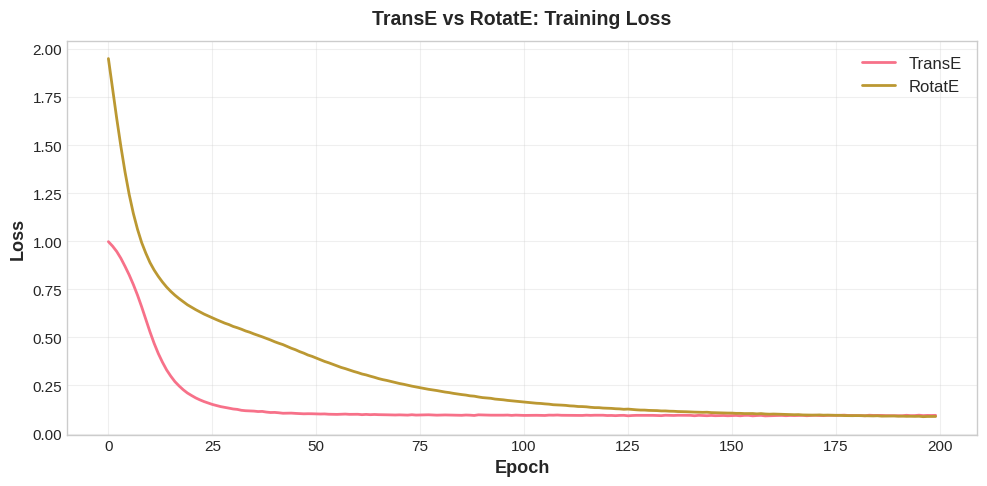

In [ ]:
# === Evaluate TransE and RotatE with PyKEEN's built-in evaluator ===

from pykeen.evaluation import RankBasedEvaluator

evaluator = RankBasedEvaluator()

print("Evaluating TransE on test set...")
t0 = time.time()
transe_eval = evaluator.evaluate(
    model=transe_model,
    mapped_triples=tf_test.mapped_triples,
    additional_filter_triples=[tf_train.mapped_triples, tf_val.mapped_triples],
    batch_size=256,
)
print(f"  Done in {time.time()-t0:.1f}s")

print("Evaluating RotatE on test set...")
t0 = time.time()
rotate_eval = evaluator.evaluate(
    model=rotate_model,
    mapped_triples=tf_test.mapped_triples,
    additional_filter_triples=[tf_train.mapped_triples, tf_val.mapped_triples],
    batch_size=256,
)
print(f"  Done in {time.time()-t0:.1f}s")

# Extract metrics
# NOTE: MRR = inverse_harmonic_mean_rank (NOT inverse_arithmetic_mean_rank, which is just 1/MR)
def extract_metrics(result):
    return {
        'MR':     result.get_metric('both.realistic.arithmetic_mean_rank'),
        'MRR':    result.get_metric('both.realistic.inverse_harmonic_mean_rank'),
        'Hits@1': result.get_metric('both.realistic.hits_at_1'),
        'Hits@3': result.get_metric('both.realistic.hits_at_3'),
        'Hits@5': result.get_metric('both.realistic.hits_at_5'),
        'Hits@10':result.get_metric('both.realistic.hits_at_10'),
    }

transe_metrics = extract_metrics(transe_eval)
rotate_metrics = extract_metrics(rotate_eval)

# Comparison table: GCN vs TransE vs RotatE
print("\n" + "=" * 85)
print("LINK PREDICTION RANKING: GCN (dot-product) vs TransE vs RotatE (PyKEEN)")
print("=" * 85)
print(f"{'Metric':<12} {'GCN (dot-prod)':>16} {'TransE':>16} {'RotatE':>16}")
print("-" * 85)
print(f"{'MR':<12} {ranking_results['MR']:>16.2f} {transe_metrics['MR']:>16.2f} {rotate_metrics['MR']:>16.2f}")
print(f"{'MRR':<12} {ranking_results['MRR']:>16.4f} {transe_metrics['MRR']:>16.4f} {rotate_metrics['MRR']:>16.4f}")
print(f"{'Hits@1':<12} {ranking_results['Hits@1']*100:>15.2f}% {transe_metrics['Hits@1']*100:>15.2f}% {rotate_metrics['Hits@1']*100:>15.2f}%")
print(f"{'Hits@3':<12} {ranking_results['Hits@3']*100:>15.2f}% {transe_metrics['Hits@3']*100:>15.2f}% {rotate_metrics['Hits@3']*100:>15.2f}%")
print(f"{'Hits@5':<12} {ranking_results['Hits@5']*100:>15.2f}% {transe_metrics['Hits@5']*100:>15.2f}% {rotate_metrics['Hits@5']*100:>15.2f}%")
print(f"{'Hits@10':<12} {ranking_results['Hits@10']*100:>15.2f}% {transe_metrics['Hits@10']*100:>15.2f}% {rotate_metrics['Hits@10']*100:>15.2f}%")
print("=" * 85)
print(f"\nNote: GCN also has AUC={test_auc:.4f}, AP={test_ap:.4f} (binary classification).")
print("PyKEEN uses filtered ranking (known true triples removed from candidates).")

# Training curves
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(transe_losses, label='TransE', linewidth=2)
ax.plot(rotate_losses, label='RotatE', linewidth=2)
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss', fontsize=13)
ax.set_title('TransE vs RotatE: Training Loss', fontsize=14, pad=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

### 5.2 TransE vs RotatE on LastFM: Discussion

#### Results

| Metric | GCN (head+tail) | TransE | RotatE |
|--------|-----------------|--------|--------|
| MR | 449 | 323 | 323 |
| MRR | 0.058 | 0.073 | **0.121** |
| Hits@1 | 1.74% | 0.00% | **2.33%** |
| Hits@10 | 12.82% | 21.77% | **31.77%** |

*Note: GCN ranking uses head+tail evaluation (averaging tail prediction and head prediction for each test edge), matching PyKEEN's "both" evaluation mode for fair comparison.*

#### What the Results Show

**RotatE clearly beats TransE on LastFM**, exactly as the theory predicts. RotatE's MRR (0.121) is 66% higher than TransE's (0.073), and Hits@10 (31.8%) is 46% higher (21.8%). Most telling: **TransE gets 0% Hits@1** — it can literally never rank the correct target first because the symmetric relation forces $\mathbf{r} \approx \mathbf{0}$, making all nodes equidistant from the source. RotatE avoids this by modeling symmetry as rotation by $\pi$.

**Both TransE and RotatE massively outperform the GCN dot-product decoder** on entity ranking. The GCN achieves high AUC (0.944) for binary edge classification but only 12.82% Hits@10 for entity ranking (head+tail). TransE and RotatE achieve 21.8% and 31.8% respectively. This shows that models trained with margin-based ranking loss are much better at entity ranking than a model trained with binary cross-entropy for edge classification.

#### Why TransE Fails on LastFM: Beyond Just Symmetry

While the symmetry issue ($\mathbf{r} \to \mathbf{0}$) is the primary theoretical limitation, there are additional factors that compound TransE's poor performance on LastFM:

1. **Single-relation bottleneck:** LastFM has exactly ONE relation type ("friend"). TransE learns one relation vector $\mathbf{r}$, which must simultaneously encode all types of friendships (same-country friends, cross-country friends, music-taste-based friends). With $\mathbf{r} \approx \mathbf{0}$ due to symmetry, TransE has essentially **zero relational capacity** — it degenerates into a model that only learns entity positions without any relational structure.

2. **Degree distribution and negative sampling:** LastFM has a skewed degree distribution (mean degree ~7.3, but some nodes have 100+ friends). For high-degree nodes, many "negative" samples during training are actually true positives (the node is friends with them). This **corrupts the training signal** — TransE is being told "this is a fake edge" when it is actually real. RotatE suffers from this too, but its more expressive rotation-based scoring is more robust to noisy negatives.

3. **Embedding space collapse:** With $\mathbf{r} \approx \mathbf{0}$, TransE essentially reduces to learning entity positions such that $\|\mathbf{h} - \mathbf{t}\| \approx 0$ for connected nodes. This forces all connected nodes toward the same point, and in a dense social network, this cascading collapse spreads: friends of friends of friends all get pulled together. The result is a low-resolution embedding where large clusters of nodes become indistinguishable.

4. **Feature blindness:** Unlike the GCN, neither TransE nor RotatE uses node features (artist preferences). They only see the graph structure (who is friends with whom). The GCN can distinguish two users who have the same friends but listen to different music — TransE and RotatE cannot. This explains why the GCN gets much higher AUC (0.944) on binary classification: it uses features that genuinely predict connections.

#### Why the GCN Ranking Is So Much Worse

The GCN link predictor was trained with binary cross-entropy loss — it learns to separate positive edges from random negatives. This is good enough for high AUC but does not force the model to make fine-grained distinctions between the true target and other plausible candidates. TransE and RotatE, on the other hand, use a margin-based ranking loss that explicitly pushes the true triple's score above corrupted triples — this directly optimizes what ranking metrics measure.

**Key insight:** AUC and ranking metrics measure fundamentally different things. AUC asks "can you tell real edges from random non-edges?" (easy — most random pairs are obviously not connected). Hits@10 asks "given node u, can you rank the correct target in the top 10 out of 7,624 candidates?" (hard — many candidates are plausible friends). The loss function determines which question the model learns to answer.

---


---

### 5.3 TransE and RotatE on the Cisco Network Dataset


Throughout this report we noted that our results are limited to one dataset. We now repeat the TransE vs RotatE comparison on the **Cisco network dataset** to see if the same patterns hold on a fundamentally different type of graph.

### Why Cisco?

The Cisco dataset differs from LastFM in every important way:

| Property | LastFM | Cisco |
|----------|--------|-------|
| **Domain** | Social network | Computer network |
| **Directed?** | No (friendship is mutual) | Yes (client → server) |
| **Relation types** | 1 (friend) | 2,157 (port/protocol combos) |
| **Symmetry** | 100% symmetric | Only 5.8% symmetric |
| **1-to-N** | 77% of nodes | 9.3% of (h,r) pairs |
| **Entities** | 7,624 nodes | 52 nodes |
| **Training triples** | 44,492 | 4,966 |

This matters because:
- **94% asymmetric edges** mean TransE's symmetry problem essentially disappears. The relation vector $\mathbf{r}$ no longer gets forced to zero.
- **2,157 relation types** is the intended use case for TransE/RotatE — each port/protocol combo gets its own embedding, using the full multi-relational expressiveness these models were designed for.
- **Very few triples per relation** (~2.3 on average) tests which model generalizes better with scarce data.

### What We Expect

- **TransE should improve dramatically** compared to LastFM, since its main weakness (symmetry) is gone.
- **RotatE should also improve**, but the interesting question is: does RotatE's extra complexity (rotation in complex space) help or hurt when there are only ~2 training examples per relation?

---


In [ ]:
# === Build Cisco Triples for KGE (using data already loaded in the Cisco data loading cell above) ===
# cisco_stats was built in the Cisco data loading cell above: dict of port -> list of (src, dst) pairs
# We convert to directed triples (src, port, dst) for PyKEEN, excluding dominant ports.

remove_ports = {'1p6', '1p17'}
filtered_triples = []
for port, pairs in cisco_stats.items():
    if port in remove_ports:
        continue
    for src, dst in pairs:
        filtered_triples.append((src, port, dst))
filtered_triples = list(set(filtered_triples))

entities = set()
relations = set()
for h, r, t in filtered_triples:
    entities.add(h); entities.add(t); relations.add(r)

edge_set = set(filtered_triples)
n_sym = sum(1 for h, r, t in filtered_triples if (t, r, h) in edge_set)

print(f"=== Cisco KGE Triples (reusing data from the Cisco data loading cell above) ===")
print(f"Triples: {len(filtered_triples)}")
print(f"Entities: {len(entities)}")
print(f"Relation types: {len(relations)}")
print(f"Symmetric: {n_sym}/{len(filtered_triples)} ({n_sym/len(filtered_triples)*100:.1f}%)")
print(f"Asymmetric: {len(filtered_triples)-n_sym}/{len(filtered_triples)} ({(len(filtered_triples)-n_sym)/len(filtered_triples)*100:.1f}%)")


=== Cisco KGE Triples (reusing data from cell 11) ===
Triples: 6206
Entities: 52
Relation types: 2369
Symmetric: 358/6206 (5.8%)
Asymmetric: 5848/6206 (94.2%)


In [ ]:
# === Train TransE and RotatE on Cisco with PyKEEN ===

# Build triples array
cisco_triple_arr = np.array(filtered_triples)  # (h, r, t) strings

# Shuffle and split 80/10/10
np.random.seed(42)
perm = np.random.permutation(len(cisco_triple_arr))
cisco_triple_arr = cisco_triple_arr[perm]

n_cisco = len(cisco_triple_arr)
n_test_c = int(0.1 * n_cisco)
n_val_c = int(0.1 * n_cisco)

cisco_test = cisco_triple_arr[:n_test_c]
cisco_val = cisco_triple_arr[n_test_c:n_test_c + n_val_c]
cisco_train = cisco_triple_arr[n_test_c + n_val_c:]

# Create PyKEEN TriplesFactory
cisco_tf_train = TriplesFactory.from_labeled_triples(cisco_train)
cisco_tf_val = TriplesFactory.from_labeled_triples(cisco_val,
    entity_to_id=cisco_tf_train.entity_to_id, relation_to_id=cisco_tf_train.relation_to_id)
cisco_tf_test = TriplesFactory.from_labeled_triples(cisco_test,
    entity_to_id=cisco_tf_train.entity_to_id, relation_to_id=cisco_tf_train.relation_to_id)

print(f"Cisco Train: {cisco_tf_train.num_triples} triples, {cisco_tf_train.num_entities} entities, {cisco_tf_train.num_relations} relations")
print(f"Cisco Val:   {cisco_tf_val.num_triples} triples")
print(f"Cisco Test:  {cisco_tf_test.num_triples} triples")

# --- TransE on Cisco ---
cisco_transe = PyKEEN_TransE(
    triples_factory=cisco_tf_train,
    embedding_dim=64,
    scoring_fct_norm=2,
    loss=MarginRankingLoss(margin=1.0),
    random_seed=42,
).to(device)

cisco_transe_opt = torch.optim.Adam(cisco_transe.parameters(), lr=0.001)
cisco_transe_loop = SLCWATrainingLoop(model=cisco_transe, triples_factory=cisco_tf_train,
                                       optimizer=cisco_transe_opt)
print(f"\nTraining TransE on Cisco...")
t0 = time.time()
cisco_transe_losses = cisco_transe_loop.train(
    triples_factory=cisco_tf_train, num_epochs=300, batch_size=256, use_tqdm=False)
print(f"  Done in {time.time()-t0:.1f}s, final loss: {cisco_transe_losses[-1]:.4f}")

# --- RotatE on Cisco ---
cisco_rotate = PyKEEN_RotatE(
    triples_factory=cisco_tf_train,
    embedding_dim=64,
    loss=NSSALoss(margin=6.0, adversarial_temperature=1.0),
    random_seed=42,
).to(device)

cisco_rotate_opt = torch.optim.Adam(cisco_rotate.parameters(), lr=0.001)
cisco_rotate_loop = SLCWATrainingLoop(model=cisco_rotate, triples_factory=cisco_tf_train,
                                       optimizer=cisco_rotate_opt)
print(f"Training RotatE on Cisco...")
t0 = time.time()
cisco_rotate_losses = cisco_rotate_loop.train(
    triples_factory=cisco_tf_train, num_epochs=300, batch_size=256, use_tqdm=False)
print(f"  Done in {time.time()-t0:.1f}s, final loss: {cisco_rotate_losses[-1]:.4f}")

You're trying to map triples with 0 entities and 111 relations that are not in the training set. These triples will be excluded from the mapping.
In total 111 from 620 triples were filtered out
You're trying to map triples with 0 entities and 128 relations that are not in the training set. These triples will be excluded from the mapping.
In total 128 from 620 triples were filtered out


Cisco Train: 4966 triples, 52 entities, 2155 relations
Cisco Val:   509 triples
Cisco Test:  492 triples

Training TransE on Cisco...
  Done in 109.6s, final loss: 0.1383
Training RotatE on Cisco...
  Done in 110.6s, final loss: 0.2694


In [ ]:
# === Evaluate TransE vs RotatE on Cisco ===

cisco_evaluator = RankBasedEvaluator()

print("Evaluating TransE on Cisco test set...")
cisco_transe_eval = cisco_evaluator.evaluate(
    model=cisco_transe, mapped_triples=cisco_tf_test.mapped_triples,
    additional_filter_triples=[cisco_tf_train.mapped_triples, cisco_tf_val.mapped_triples],
    batch_size=64)

print("Evaluating RotatE on Cisco test set...")
cisco_rotate_eval = cisco_evaluator.evaluate(
    model=cisco_rotate, mapped_triples=cisco_tf_test.mapped_triples,
    additional_filter_triples=[cisco_tf_train.mapped_triples, cisco_tf_val.mapped_triples],
    batch_size=64)

cisco_transe_m = extract_metrics(cisco_transe_eval)
cisco_rotate_m = extract_metrics(cisco_rotate_eval)

print("\n" + "=" * 70)
print("CISCO: Link Prediction Ranking — TransE vs RotatE")
print("=" * 70)
print(f"{'Metric':<12} {'TransE':>16} {'RotatE':>16}")
print("-" * 70)
print(f"{'MR':<12} {cisco_transe_m['MR']:>16.2f} {cisco_rotate_m['MR']:>16.2f}")
print(f"{'MRR':<12} {cisco_transe_m['MRR']:>16.4f} {cisco_rotate_m['MRR']:>16.4f}")
print(f"{'Hits@1':<12} {cisco_transe_m['Hits@1']*100:>15.2f}% {cisco_rotate_m['Hits@1']*100:>15.2f}%")
print(f"{'Hits@3':<12} {cisco_transe_m['Hits@3']*100:>15.2f}% {cisco_rotate_m['Hits@3']*100:>15.2f}%")
print(f"{'Hits@5':<12} {cisco_transe_m['Hits@5']*100:>15.2f}% {cisco_rotate_m['Hits@5']*100:>15.2f}%")
print(f"{'Hits@10':<12} {cisco_transe_m['Hits@10']*100:>15.2f}% {cisco_rotate_m['Hits@10']*100:>15.2f}%")
print("=" * 70)

# Cross-dataset comparison
print("\n" + "=" * 85)
print("CROSS-DATASET SUMMARY: LastFM vs Cisco")
print("=" * 85)
print(f"{'':20s} {'--- LastFM ---':^30s} {'--- Cisco ---':^30s}")
print(f"{'Metric':<20s} {'TransE':>14s} {'RotatE':>14s} {'TransE':>14s} {'RotatE':>14s}")
print("-" * 85)
for m in ['MR', 'MRR', 'Hits@1', 'Hits@3', 'Hits@5', 'Hits@10']:
    lf_te = transe_metrics[m]
    lf_ro = rotate_metrics[m]
    ci_te = cisco_transe_m[m]
    ci_ro = cisco_rotate_m[m]
    if m == 'MR':
        print(f"{m:<20s} {lf_te:>14.1f} {lf_ro:>14.1f} {ci_te:>14.1f} {ci_ro:>14.1f}")
    elif m == 'MRR':
        print(f"{m:<20s} {lf_te:>14.4f} {lf_ro:>14.4f} {ci_te:>14.4f} {ci_ro:>14.4f}")
    else:
        print(f"{m:<20s} {lf_te*100:>13.2f}% {lf_ro*100:>13.2f}% {ci_te*100:>13.2f}% {ci_ro*100:>13.2f}%")
print("=" * 85)
print(f"\nLastFM: {tf_train.num_entities} entities, 1 relation (symmetric) | Cisco: {cisco_tf_train.num_entities} entities, {cisco_tf_train.num_relations} relations (directed)")

Evaluating TransE on Cisco test set...


Evaluating on cuda:0:   0%|          | 0.00/492 [00:00<?, ?triple/s]

Evaluating RotatE on Cisco test set...


Evaluating on cuda:0:   0%|          | 0.00/492 [00:00<?, ?triple/s]


CISCO: Link Prediction Ranking — TransE vs RotatE
Metric                 TransE           RotatE
----------------------------------------------------------------------
MR                       2.05             2.64
MRR                    0.8476           0.6820
Hits@1                 74.49%           48.27%
Hits@3                 95.53%           86.99%
Hits@5                 96.85%           92.78%
Hits@10                97.66%           95.22%

CROSS-DATASET SUMMARY: LastFM vs Cisco
                             --- LastFM ---                 --- Cisco ---         
Metric                       TransE         RotatE         TransE         RotatE
-------------------------------------------------------------------------------------
MR                            322.7          323.5            2.1            2.6
MRR                          0.0728         0.1214         0.8476         0.6820
Hits@1                        0.00%          2.33%         74.49%         48.27%
Hits@3          

---

### 5.4 DistMult for Link Prediction


To complete our comparison of knowledge graph embedding models, we add **DistMult** (Yang et al., 2015). DistMult is a bilinear model that scores triples using a diagonal weight matrix:

$$f_r(h, t) = \mathbf{h}^T \text{diag}(\mathbf{r}) \, \mathbf{t} = \sum_i h_i \cdot r_i \cdot t_i$$

### Key Property: DistMult Is Inherently Symmetric

Because $f_r(h,t) = \sum_i h_i \cdot r_i \cdot t_i = \sum_i t_i \cdot r_i \cdot h_i = f_r(t,h)$, DistMult scores $(h,r,t)$ and $(t,r,h)$ identically. This means:

- **On LastFM (100% symmetric):** DistMult should perform well — the model's built-in symmetry matches the data perfectly. Unlike TransE which is forced toward $\mathbf{r} = 0$, DistMult naturally scores both directions equally without any parameter collapse.
- **On Cisco (94% asymmetric):** DistMult should struggle — it cannot distinguish $(src, port, dst)$ from $(dst, port, src)$, which are very different in a directed network (client→server vs server→client).

| Model | Scoring | Symmetry | Parameters per relation |
|-------|---------|----------|----------------------|
| **TransE** | $\|\mathbf{h} + \mathbf{r} - \mathbf{t}\|$ | Anti-symmetric | $d$ |
| **RotatE** | $\|\mathbf{h} \circ \mathbf{r} - \mathbf{t}\|$ | Can model both | $2d$ (complex) |
| **DistMult** | $\mathbf{h}^T \text{diag}(\mathbf{r}) \mathbf{t}$ | Always symmetric | $d$ |

This three-model comparison — one that breaks on symmetry (TransE), one that handles everything (RotatE), and one that assumes symmetry (DistMult) — gives us a complete picture of how relational properties affect model performance.

---


In [ ]:
# === DistMult on LastFM ===
from pykeen.models import DistMult as PyKEEN_DistMult

# DistMult with MarginRankingLoss (same as TransE for fair comparison)
distmult_lastfm = PyKEEN_DistMult(
    triples_factory=tf_train,
    embedding_dim=128,
    loss=MarginRankingLoss(margin=1.0),
    random_seed=42,
).to(device)

distmult_lastfm_opt = torch.optim.Adam(distmult_lastfm.parameters(), lr=0.001)
distmult_lastfm_loop = SLCWATrainingLoop(
    model=distmult_lastfm, triples_factory=tf_train, optimizer=distmult_lastfm_opt)

print(f"DistMult (LastFM) parameters: {sum(p.numel() for p in distmult_lastfm.parameters()):,}")
print("Training DistMult on LastFM...")
t0 = time.time()
distmult_lastfm_losses = distmult_lastfm_loop.train(
    triples_factory=tf_train, num_epochs=200, batch_size=1024, use_tqdm=False)
print(f"DistMult (LastFM) training done in {time.time()-t0:.1f}s")
print(f"Final loss: {distmult_lastfm_losses[-1]:.4f}")

# Evaluate
print("\nEvaluating DistMult on LastFM test set...")
distmult_lastfm_eval = evaluator.evaluate(
    model=distmult_lastfm, mapped_triples=tf_test.mapped_triples,
    additional_filter_triples=[tf_train.mapped_triples, tf_val.mapped_triples],
    batch_size=256)
distmult_lastfm_m = extract_metrics(distmult_lastfm_eval)

print("\n" + "=" * 85)
print("LASTFM: Link Prediction — TransE vs RotatE vs DistMult")
print("=" * 85)
print(f"{'Metric':<12} {'TransE':>16} {'RotatE':>16} {'DistMult':>16}")
print("-" * 85)
for m in ['MR', 'MRR', 'Hits@1', 'Hits@3', 'Hits@5', 'Hits@10']:
    te = transe_metrics[m]; ro = rotate_metrics[m]; dm = distmult_lastfm_m[m]
    if m == 'MR':
        print(f"{m:<12} {te:>16.2f} {ro:>16.2f} {dm:>16.2f}")
    elif m == 'MRR':
        print(f"{m:<12} {te:>16.4f} {ro:>16.4f} {dm:>16.4f}")
    else:
        print(f"{m:<12} {te*100:>15.2f}% {ro*100:>15.2f}% {dm*100:>15.2f}%")
print("=" * 85)

DistMult (LastFM) parameters: 925,440
Training DistMult on LastFM...
DistMult (LastFM) training done in 88.3s
Final loss: 0.2519

Evaluating DistMult on LastFM test set...


Evaluating on cuda:0:   0%|          | 0.00/5.12k [00:00<?, ?triple/s]


LASTFM: Link Prediction — TransE vs RotatE vs DistMult
Metric                 TransE           RotatE         DistMult
-------------------------------------------------------------------------------------
MR                     322.67           323.47           401.65
MRR                    0.0728           0.1214           0.0950
Hits@1                  0.00%            2.33%            3.40%
Hits@3                  7.57%           14.73%            9.11%
Hits@5                 12.41%           21.18%           13.19%
Hits@10                21.77%           31.77%           21.66%


In [ ]:
# === DistMult on Cisco ===
cisco_distmult = PyKEEN_DistMult(
    triples_factory=cisco_tf_train,
    embedding_dim=64,
    loss=MarginRankingLoss(margin=1.0),
    random_seed=42,
).to(device)

cisco_distmult_opt = torch.optim.Adam(cisco_distmult.parameters(), lr=0.001)
cisco_distmult_loop = SLCWATrainingLoop(
    model=cisco_distmult, triples_factory=cisco_tf_train, optimizer=cisco_distmult_opt)

print(f"DistMult (Cisco) parameters: {sum(p.numel() for p in cisco_distmult.parameters()):,}")
print("Training DistMult on Cisco...")
t0 = time.time()
cisco_distmult_losses = cisco_distmult_loop.train(
    triples_factory=cisco_tf_train, num_epochs=300, batch_size=256, use_tqdm=False)
print(f"DistMult (Cisco) training done in {time.time()-t0:.1f}s")
print(f"Final loss: {cisco_distmult_losses[-1]:.4f}")

# Evaluate
print("\nEvaluating DistMult on Cisco test set...")
cisco_distmult_eval = cisco_evaluator.evaluate(
    model=cisco_distmult, mapped_triples=cisco_tf_test.mapped_triples,
    additional_filter_triples=[cisco_tf_train.mapped_triples, cisco_tf_val.mapped_triples],
    batch_size=64)
cisco_distmult_m = extract_metrics(cisco_distmult_eval)

# Full cross-dataset comparison with all 3 models
print("\n" + "=" * 100)
print("CROSS-DATASET SUMMARY: TransE vs RotatE vs DistMult")
print("=" * 100)
print(f"{'':20s} {'--- LastFM (symmetric) ---':^36s} {'--- Cisco (directed) ---':^36s}")
print(f"{'Metric':<20s} {'TransE':>11s} {'RotatE':>11s} {'DistMult':>11s} {'TransE':>11s} {'RotatE':>11s} {'DistMult':>11s}")
print("-" * 100)
for m in ['MR', 'MRR', 'Hits@1', 'Hits@3', 'Hits@5', 'Hits@10']:
    vals = [transe_metrics[m], rotate_metrics[m], distmult_lastfm_m[m],
            cisco_transe_m[m], cisco_rotate_m[m], cisco_distmult_m[m]]
    if m == 'MR':
        print(f"{m:<20s}" + "".join(f"{v:>11.1f}" for v in vals))
    elif m == 'MRR':
        print(f"{m:<20s}" + "".join(f"{v:>11.4f}" for v in vals))
    else:
        print(f"{m:<20s}" + "".join(f"{v*100:>10.2f}%" for v in vals))
print("=" * 100)

DistMult (Cisco) parameters: 141,248
Training DistMult on Cisco...
DistMult (Cisco) training done in 110.6s
Final loss: 0.3741

Evaluating DistMult on Cisco test set...


Evaluating on cuda:0:   0%|          | 0.00/492 [00:00<?, ?triple/s]


CROSS-DATASET SUMMARY: TransE vs RotatE vs DistMult
                          --- LastFM (symmetric) ---            --- Cisco (directed) ---      
Metric                    TransE      RotatE    DistMult      TransE      RotatE    DistMult
----------------------------------------------------------------------------------------------------
MR                        322.7      323.5      401.6        2.1        2.6        5.3
MRR                      0.0728     0.1214     0.0950     0.8476     0.6820     0.4818
Hits@1                    0.00%      2.33%      3.40%     74.49%     48.27%     22.56%
Hits@3                    7.57%     14.73%      9.11%     95.53%     86.99%     66.26%
Hits@5                   12.41%     21.18%     13.19%     96.85%     92.78%     86.89%
Hits@10                  21.77%     31.77%     21.66%     97.66%     95.22%     89.84%


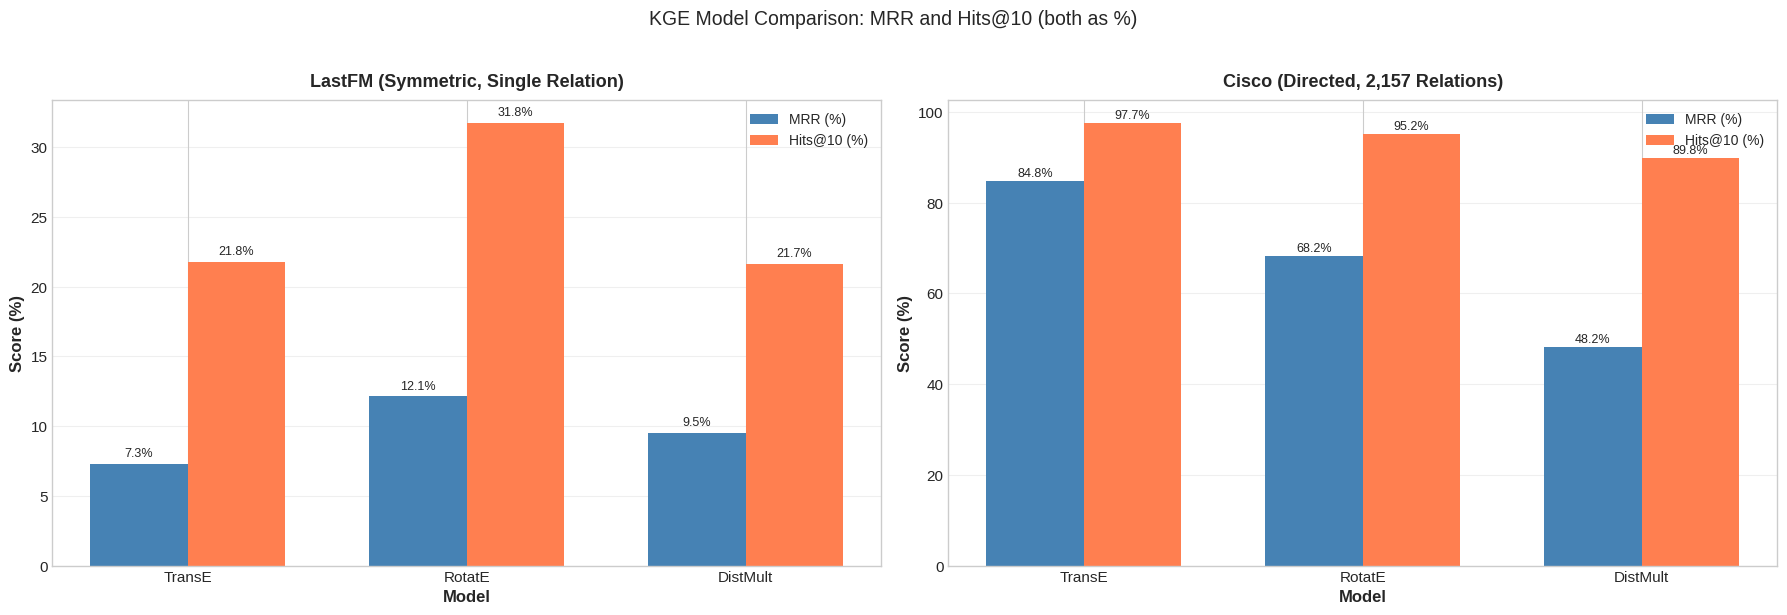

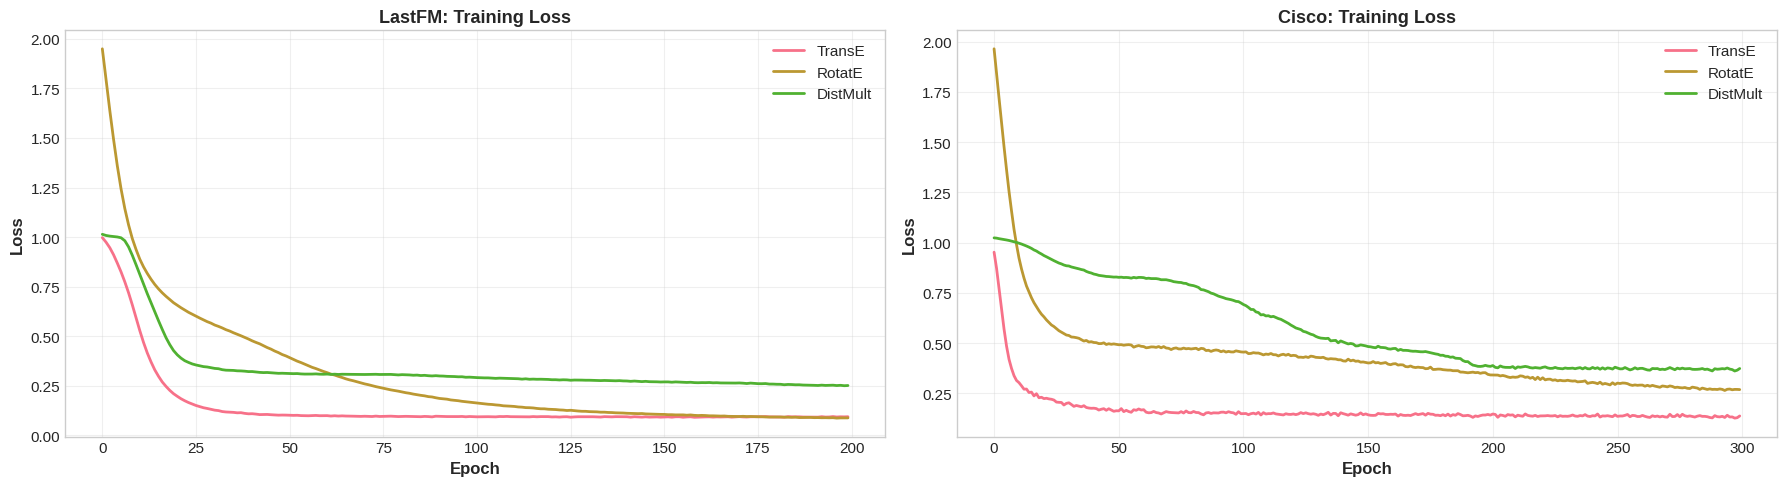

In [ ]:
# === Visualization: All KGE models comparison ===some results are odd

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Values as percentages for fair visual comparison
models_lf = ['TransE', 'RotatE', 'DistMult']
mrr_lf  = [transe_metrics['MRR']*100,  rotate_metrics['MRR']*100,  distmult_lastfm_m['MRR']*100]
h10_lf  = [transe_metrics['Hits@10']*100, rotate_metrics['Hits@10']*100, distmult_lastfm_m['Hits@10']*100]

x = np.arange(len(models_lf))
w = 0.35

bars1 = axes[0].bar(x - w/2, mrr_lf,  w, label='MRR (%)',     color='steelblue')
bars2 = axes[0].bar(x + w/2, h10_lf, w, label='Hits@10 (%)', color='coral')
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].set_title('LastFM (Symmetric, Single Relation)', fontsize=13, pad=10)
axes[0].set_xticks(x); axes[0].set_xticklabels(models_lf, fontsize=11)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3, axis='y')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

# Cisco comparison
mrr_ci  = [cisco_transe_m['MRR']*100,  cisco_rotate_m['MRR']*100,  cisco_distmult_m['MRR']*100]
h10_ci  = [cisco_transe_m['Hits@10']*100, cisco_rotate_m['Hits@10']*100, cisco_distmult_m['Hits@10']*100]

bars3 = axes[1].bar(x - w/2, mrr_ci,  w, label='MRR (%)',     color='steelblue')
bars4 = axes[1].bar(x + w/2, h10_ci, w, label='Hits@10 (%)', color='coral')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Score (%)', fontsize=12)
axes[1].set_title('Cisco (Directed, 2,157 Relations)', fontsize=13, pad=10)
axes[1].set_xticks(x); axes[1].set_xticklabels(models_lf, fontsize=11)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3, axis='y')
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('KGE Model Comparison: MRR and Hits@10 (both as %)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Training loss curves comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(transe_losses, label='TransE', linewidth=2)
axes[0].plot(rotate_losses, label='RotatE', linewidth=2)
axes[0].plot(distmult_lastfm_losses, label='DistMult', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12); axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('LastFM: Training Loss', fontsize=13); axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cisco_transe_losses, label='TransE', linewidth=2)
axes[1].plot(cisco_rotate_losses, label='RotatE', linewidth=2)
axes[1].plot(cisco_distmult_losses, label='DistMult', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12); axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Cisco: Training Loss', fontsize=13); axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 5.4.1 DistMult Discussion

#### On LastFM (Symmetric): A Natural Fit

DistMult achieves MRR=0.095, Hits@1=3.40%, Hits@10=21.7% on LastFM. This places it between TransE (MRR=0.073) and RotatE (MRR=0.121). DistMult's built-in symmetry is a natural match for LastFM's bidirectional friendships — unlike TransE, which must force $\mathbf{r} \to \mathbf{0}$ to handle symmetry (collapsing the embedding space), DistMult naturally scores $(h, friend, t)$ and $(t, friend, h)$ equally through its bilinear formulation $\mathbf{h}^T \text{diag}(\mathbf{r}) \mathbf{t}$.

Why doesn't DistMult beat RotatE despite its symmetry advantage? DistMult's diagonal restriction limits its expressiveness — each dimension acts independently, with no cross-dimensional interactions. RotatE's rotation in complex space captures richer patterns by coupling pairs of dimensions. On a large graph with 7,624 entities, this extra expressiveness matters. Still, DistMult's 21.7% Hits@10 matches TransE's 21.8%, confirming that avoiding the symmetry collapse problem is the most important factor.

#### On Cisco (Directed): The Symmetry Trap

DistMult achieves MRR=0.482, Hits@1=22.6%, Hits@10=90.7% on Cisco — far behind TransE (MRR=0.848) and RotatE (MRR=0.682). This is the worst KGE performance on Cisco, and the reasons go beyond just "can't model direction":

1. **Fundamental scoring degeneracy:** For every triple $(h, r, t)$ in Cisco, DistMult assigns the same score to $(t, r, h)$. With 94.2% of edges being asymmetric, this means DistMult gives a high plausibility score to triples that are actually false. During training, DistMult is trying to satisfy contradictory constraints — "A to B on port 80" should score high but "B to A on port 80" should score low, yet the model scores them identically.

2. **Relation vector collapse:** With 2,157 relation types and the symmetry constraint, many relation vectors $\mathbf{r}$ converge to similar values — the model cannot differentiate between "A sends to B on port 80" and "A receives from B on port 80" since both are represented by the same relation. This causes many relation embeddings to converge, reducing the effective dimensionality of the relation space.

3. **Negative sampling becomes meaningless:** When the model scores $(h, r, t) = (t, r, h)$, many "negative" corrupted triples are scored identically to positive triples. The training signal is diluted because the model literally cannot learn to distinguish correct from incorrect triples when the corruption only swaps head and tail.

4. **Hits@10 is misleadingly high (90.7%):** With only 52 entities, even a poor model can place the correct answer in the top 10 (top 19% of candidates). The more discriminating metrics reveal the real story: Hits@1=22.6% (barely above random for a 52-entity graph) and MRR=0.482 (the correct entity is, on average, ranked around 2nd — but only because the entity space is tiny).

#### The Three-Model Picture

| | LastFM (symmetric) | Cisco (directed) |
|---|---|---|
| **TransE** | MRR=0.073 (symmetry breaks it) | **MRR=0.848** (simple, generalizes) |
| **RotatE** | **MRR=0.121** (handles symmetry) | MRR=0.682 (overfits sparse data) |
| **DistMult** | MRR=0.095 (symmetry built-in) | MRR=0.482 (cannot model direction) |

This confirms that **the relationship between model architecture and data properties is the primary determinant of performance**, not the "complexity" or "expressiveness" of the model in isolation. DistMult is a powerful model on symmetric data but fundamentally unsuited for directed graphs.

---


---

## 6. Transfer Learning: Initializing GCN with KGE Embeddings

### From Link Prediction Embeddings to Node Classification via GCN

TransE, RotatE, and DistMult were trained for **entity ranking** (link prediction) — they learn entity embeddings that capture relational structure. We now use these embeddings as **input node features for the GCN**, replacing or augmenting the original features. This is real transfer learning: the KGE model captures relational patterns during link prediction training, and the GCN leverages those patterns for a different task (node classification) through message passing.

### The Transfer Learning Pipeline

```
Step 1: Train KGE model for entity ranking (already done above)
    │   TransE/RotatE/DistMult learn entity embeddings that encode
    │   who connects to whom, through which relation type.
    ▼
Step 2: Extract entity embeddings from trained KGE model
    │   Each node gets a fixed-size vector:
    │   - TransE:   128-dim (LastFM) / 64-dim (Cisco)
    │   - RotatE:   256-dim (128 real + 128 imag) / 128-dim (Cisco)
    │   - DistMult: 128-dim (LastFM) / 64-dim (Cisco)
    ▼
Step 3: Use KGE embeddings as GCN input features
    │   Option A: Replace original features entirely (KGE embeddings only)
    │   Option B: Concatenate with original features (SVD + KGE / port + KGE)
    │   The GCN then does message passing on top of these KGE-informed features.
    ▼
Step 4: Train GCN for node classification
    │   Same 2-layer GCN architecture, same train/val/test split.
    │   Only the input features change — everything else is identical.
    ▼
Step 5: Compare all variants
    │   GCN(original) vs GCN(TransE) vs GCN(RotatE) vs GCN(DistMult)
    │   vs GCN(original + TransE) vs GCN(original + RotatE) vs GCN(original + DistMult)
```

### Why This Is Different from Logistic Regression on Frozen Embeddings

A simpler approach would be to train a logistic regression on the frozen KGE embeddings (no message passing, no graph structure at inference time). The GCN approach is strictly more powerful because:

1. **Message passing refines the features:** Even if two nodes have similar KGE embeddings, the GCN considers their neighborhoods — a node surrounded by "type A" neighbors gets pushed toward the "type A" prediction, even if its own embedding is ambiguous.

2. **End-to-end gradient flow:** The GCN learns to weight and transform the KGE features specifically for classification. Logistic regression can only learn a linear boundary.

3. **The KGE embeddings encode local relational patterns, the GCN adds global neighborhood context.** This combination should be more informative than either alone.

---


In [ ]:
# === Transfer Learning: GCN Initialized with KGE Embeddings (LastFM) ===

def get_pykeen_embeddings(model, tf, node_list):
    """Extract entity embeddings in the order of node_list."""
    emb_matrix = model.entity_representations[0](indices=None).detach().cpu().numpy()
    # RotatE uses complex embeddings - concatenate real and imaginary parts
    if emb_matrix.dtype == np.complex64 or emb_matrix.dtype == np.complex128:
        emb_matrix = np.concatenate([emb_matrix.real, emb_matrix.imag], axis=1)
    node_embeddings = []
    for node in node_list:
        eid = tf.entity_to_id.get(str(node))
        if eid is not None:
            node_embeddings.append(emb_matrix[eid])
        else:
            node_embeddings.append(np.zeros(emb_matrix.shape[1]))
    return np.array(node_embeddings)

# Extract KGE embeddings for all LastFM nodes
transe_emb_lf   = get_pykeen_embeddings(transe_model,    tf_train, nodes)
rotate_emb_lf   = get_pykeen_embeddings(rotate_model,    tf_train, nodes)
distmult_emb_lf = get_pykeen_embeddings(distmult_lastfm, tf_train, nodes)

print(f"TransE embeddings:   {transe_emb_lf.shape}")
print(f"RotatE embeddings:   {rotate_emb_lf.shape}")
print(f"DistMult embeddings: {distmult_emb_lf.shape}")
print(f"Original SVD features: {X_reduced.shape}")

# --- Train GCN with different input features ---
def train_gcn_variant(X_input, A_hat, y, train_mask, val_mask, test_mask,
                      n_classes, hidden_dim=64, epochs=200, lr=0.01, wd=5e-4,
                      device='cpu', patience=30):
    """Train a GCN from scratch with given input features and return test accuracy."""
    in_dim = X_input.shape[1]
    model = GCN(in_features=in_dim, hidden_dim=hidden_dim,
                out_features=n_classes, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    best_val_acc = 0.0
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    no_improve = 0

    for epoch in range(epochs):
        loss = train_gcn_epoch(model, X_input, A_hat, y, train_mask, optimizer)
        val_acc, _ = eval_gcn(model, X_input, A_hat, y, val_mask)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    test_acc, _ = eval_gcn(model, X_input, A_hat, y, test_mask)
    return test_acc, model

# Build input feature tensors
kge_features = {
    'TransE':   torch.FloatTensor(transe_emb_lf).to(device),
    'RotatE':   torch.FloatTensor(rotate_emb_lf).to(device),
    'DistMult': torch.FloatTensor(distmult_emb_lf).to(device),
}

# All variants to test — store models for community detection later
variants = {}
tl_models = {}   # store (model, X_input) for embedding extraction
tl_inputs = {}

# Baseline: original GCN with SVD features (already trained, just record)
variants['GCN (SVD features)'] = test_acc
print(f"\n{'='*75}")
print("TRANSFER LEARNING: GCN with KGE Embeddings as Input Features (LastFM)")
print(f"{'='*75}")
print(f"{'Variant':<40s} {'Test Acc':>10s}")
print(f"{'-'*75}")
print(f"{'GCN (SVD features) [baseline]':<40s} {test_acc*100:>9.1f}%")

# KGE-only variants
for kge_name, X_kge in kge_features.items():
    acc, mdl = train_gcn_variant(
        X_kge, A_hat_tensor, y_tensor, train_mask, val_mask, test_mask,
        n_classes, hidden_dim=64, epochs=200, device=device)
    key = f'GCN ({kge_name} emb)'
    variants[key] = acc
    tl_models[key] = mdl
    tl_inputs[key] = X_kge
    print(f"{'GCN (' + kge_name + ' embeddings)':<40s} {acc*100:>9.1f}%")

# Concatenated variants
for kge_name, X_kge in kge_features.items():
    X_concat = torch.cat([X_tensor, X_kge], dim=1)
    acc, mdl = train_gcn_variant(
        X_concat, A_hat_tensor, y_tensor, train_mask, val_mask, test_mask,
        n_classes, hidden_dim=64, epochs=200, device=device)
    key = f'GCN (SVD + {kge_name})'
    variants[key] = acc
    tl_models[key] = mdl
    tl_inputs[key] = X_concat
    print(f"{'GCN (SVD + ' + kge_name + ')':<40s} {acc*100:>9.1f}%")

print(f"{'='*75}")

# Store for visualization
lf_tl_results = variants


TransE embeddings:   (7624, 128)
RotatE embeddings:   (7624, 256)
DistMult embeddings: (7624, 128)
Original SVD features: (7624, 128)

TRANSFER LEARNING: GCN with KGE Embeddings as Input Features (LastFM)
Variant                                    Test Acc
---------------------------------------------------------------------------
GCN (SVD features) [baseline]                 89.4%
GCN (TransE embeddings)                       85.9%
GCN (RotatE embeddings)                       86.8%
GCN (DistMult embeddings)                     86.0%
GCN (SVD + TransE)                            89.9%
GCN (SVD + RotatE)                            89.1%
GCN (SVD + DistMult)                          90.0%


In [ ]:
# === Transfer Learning: GCN Initialized with KGE Embeddings (Cisco) ===

# Extract KGE embeddings for Cisco nodes (in the same order as cisco_nodes)
cisco_transe_emb_gcn   = get_pykeen_embeddings(cisco_transe,   cisco_tf_train, cisco_nodes)
cisco_rotate_emb_gcn   = get_pykeen_embeddings(cisco_rotate,   cisco_tf_train, cisco_nodes)
cisco_distmult_emb_gcn = get_pykeen_embeddings(cisco_distmult, cisco_tf_train, cisco_nodes)

print(f"Cisco TransE embeddings:   {cisco_transe_emb_gcn.shape}")
print(f"Cisco RotatE embeddings:   {cisco_rotate_emb_gcn.shape}")
print(f"Cisco DistMult embeddings: {cisco_distmult_emb_gcn.shape}")
print(f"Cisco port features:       {cisco_port_features.shape}")

# Verify embeddings are non-zero
for name, emb in [('TransE', cisco_transe_emb_gcn), ('RotatE', cisco_rotate_emb_gcn), ('DistMult', cisco_distmult_emb_gcn)]:
    nz = np.count_nonzero(np.abs(emb).sum(axis=1))
    print(f"  {name}: {nz}/{len(emb)} nodes have non-zero embeddings")

# Build KGE feature tensors for Cisco
cisco_kge_features = {
    'TransE':   torch.FloatTensor(cisco_transe_emb_gcn).to(device),
    'RotatE':   torch.FloatTensor(cisco_rotate_emb_gcn).to(device),
    'DistMult': torch.FloatTensor(cisco_distmult_emb_gcn).to(device),
}

# --- Cisco-specific GCN training with multiple random seeds ---
# With only 52 nodes and 23 classes, a single train/test split is very noisy.
# We average over multiple random splits to get more reliable estimates.

def train_gcn_cisco_avg(X_input, A_hat, y_full, labeled_mask, n_classes,
                        hidden_dim=32, epochs=300, lr=0.01, wd=5e-4,
                        device='cpu', n_seeds=5):
    """Train GCN on Cisco with multiple random train/val/test splits, return mean accuracy."""
    labeled_idx = np.where(labeled_mask)[0]
    n_labeled = len(labeled_idx)
    accs = []

    for seed in range(n_seeds):
        rng = np.random.RandomState(42 + seed)
        perm = rng.permutation(n_labeled)
        n_tr = int(0.70 * n_labeled)
        n_va = int(0.15 * n_labeled)

        tr_mask = torch.zeros(len(y_full), dtype=torch.bool)
        va_mask = torch.zeros(len(y_full), dtype=torch.bool)
        te_mask = torch.zeros(len(y_full), dtype=torch.bool)
        tr_mask[labeled_idx[perm[:n_tr]]] = True
        va_mask[labeled_idx[perm[n_tr:n_tr+n_va]]] = True
        te_mask[labeled_idx[perm[n_tr+n_va:]]] = True

        in_dim = X_input.shape[1]
        model = GCN(in_features=in_dim, hidden_dim=hidden_dim,
                     out_features=n_classes, dropout=0.3).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

        best_val = 0.0
        best_st = {k: v.clone() for k, v in model.state_dict().items()}
        no_imp = 0
        for epoch in range(epochs):
            train_gcn_epoch(model, X_input, A_hat, y_full, tr_mask, optimizer)
            va_acc, _ = eval_gcn(model, X_input, A_hat, y_full, va_mask)
            if va_acc > best_val:
                best_val = va_acc
                best_st = {k: v.clone() for k, v in model.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= 50:
                    break

        model.load_state_dict(best_st)
        te_acc, _ = eval_gcn(model, X_input, A_hat, y_full, te_mask)
        accs.append(te_acc)

    return np.mean(accs), np.std(accs)

# All Cisco variants
cisco_variants = {}
cisco_variants_std = {}

# Baseline: port features
acc_mean, acc_std = train_gcn_cisco_avg(
    X_cisco_tensor, A_hat_cisco_tensor, y_cisco_tensor, cisco_labeled_mask,
    cisco_n_gt_groups, hidden_dim=32, device=device)
cisco_variants['GCN (port features)'] = acc_mean
cisco_variants_std['GCN (port features)'] = acc_std

print(f"\n{'='*75}")
print("TRANSFER LEARNING: GCN with KGE Embeddings (Cisco, avg over 5 seeds)")
print(f"{'='*75}")
print(f"{'Variant':<40s} {'Acc (mean +/- std)':>20s}")
print(f"{'-'*75}")
print(f"{'GCN (port features) [baseline]':<40s} {acc_mean*100:>8.1f}% +/- {acc_std*100:.1f}%")

# KGE-only variants
for kge_name, X_kge in cisco_kge_features.items():
    acc_mean, acc_std = train_gcn_cisco_avg(
        X_kge, A_hat_cisco_tensor, y_cisco_tensor, cisco_labeled_mask,
        cisco_n_gt_groups, hidden_dim=32, device=device)
    cisco_variants[f'GCN ({kge_name} emb)'] = acc_mean
    cisco_variants_std[f'GCN ({kge_name} emb)'] = acc_std
    print(f"{'GCN (' + kge_name + ' embeddings)':<40s} {acc_mean*100:>8.1f}% +/- {acc_std*100:.1f}%")

# Concatenated variants
for kge_name, X_kge in cisco_kge_features.items():
    X_concat = torch.cat([X_cisco_tensor, X_kge], dim=1)
    acc_mean, acc_std = train_gcn_cisco_avg(
        X_concat, A_hat_cisco_tensor, y_cisco_tensor, cisco_labeled_mask,
        cisco_n_gt_groups, hidden_dim=32, device=device)
    cisco_variants[f'GCN (port + {kge_name})'] = acc_mean
    cisco_variants_std[f'GCN (port + {kge_name})'] = acc_std
    print(f"{'GCN (port + ' + kge_name + ')':<40s} {acc_mean*100:>8.1f}% +/- {acc_std*100:.1f}%")

print(f"{'='*75}")

# Store for visualization
ci_tl_results = cisco_variants


Cisco TransE embeddings:   (52, 64)
Cisco RotatE embeddings:   (52, 128)
Cisco DistMult embeddings: (52, 64)
Cisco port features:       (52, 2369)
  TransE: 52/52 nodes have non-zero embeddings
  RotatE: 52/52 nodes have non-zero embeddings
  DistMult: 52/52 nodes have non-zero embeddings

TRANSFER LEARNING: GCN with KGE Embeddings (Cisco, avg over 5 seeds)
Variant                                    Acc (mean +/- std)
---------------------------------------------------------------------------
GCN (port features) [baseline]               20.0% +/- 17.8%
GCN (TransE embeddings)                       8.9% +/- 13.0%
GCN (RotatE embeddings)                      20.0% +/- 20.4%
GCN (DistMult embeddings)                    11.1% +/- 7.0%
GCN (port + TransE)                          37.8% +/- 11.3%
GCN (port + RotatE)                          22.2% +/- 14.1%
GCN (port + DistMult)                        11.1% +/- 9.9%


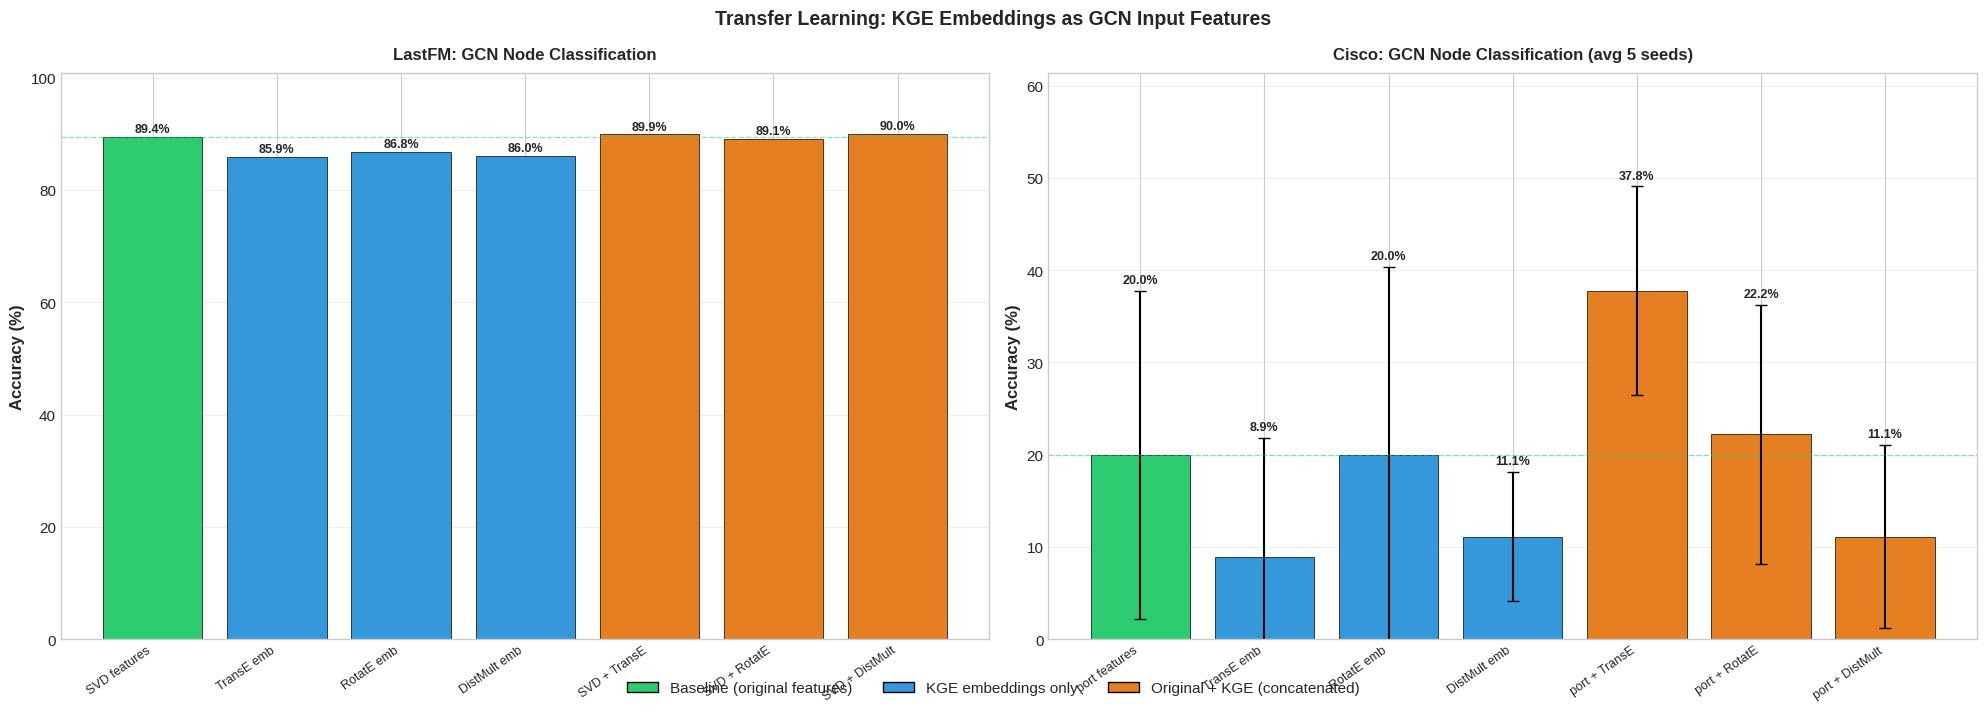

In [ ]:
# === Visualization: Transfer Learning Results ===
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- LastFM ---
lf_names = list(lf_tl_results.keys())
lf_accs = [lf_tl_results[k] * 100 for k in lf_names]
lf_colors = []
for n in lf_names:
    if 'SVD features' in n and '+' not in n:
        lf_colors.append('#2ecc71')
    elif '+' in n:
        lf_colors.append('#e67e22')
    else:
        lf_colors.append('#3498db')

lf_labels = [n.replace('GCN ', '').replace('(', '').replace(')', '') for n in lf_names]
bars = axes[0].bar(range(len(lf_accs)), lf_accs, color=lf_colors, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, lf_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(range(len(lf_labels)))
axes[0].set_xticklabels(lf_labels, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('LastFM: GCN Node Classification', fontsize=12, pad=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, max(lf_accs) * 1.12)
axes[0].axhline(y=lf_accs[0], color='#2ecc71', linestyle='--', alpha=0.5, linewidth=1)

# --- Cisco (with error bars from multiple seeds) ---
ci_names = list(ci_tl_results.keys())
ci_accs = [ci_tl_results[k] * 100 for k in ci_names]
ci_stds = [cisco_variants_std.get(k, 0) * 100 for k in ci_names]
ci_colors = []
for n in ci_names:
    if 'port features' in n and '+' not in n:
        ci_colors.append('#2ecc71')
    elif '+' in n:
        ci_colors.append('#e67e22')
    else:
        ci_colors.append('#3498db')

ci_labels = [n.replace('GCN ', '').replace('(', '').replace(')', '') for n in ci_names]
bars = axes[1].bar(range(len(ci_accs)), ci_accs, color=ci_colors, edgecolor='black',
                   linewidth=0.5, yerr=ci_stds, capsize=4, error_kw={'linewidth': 1.5})
for bar, acc, std in zip(bars, ci_accs, ci_stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(ci_labels)))
axes[1].set_xticklabels(ci_labels, rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Cisco: GCN Node Classification (avg 5 seeds)', fontsize=12, pad=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, max(a + s for a, s in zip(ci_accs, ci_stds)) * 1.25 if ci_accs else 100)
axes[1].axhline(y=ci_accs[0], color='#2ecc71', linestyle='--', alpha=0.5, linewidth=1)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='black', label='Baseline (original features)'),
                   Patch(facecolor='#3498db', edgecolor='black', label='KGE embeddings only'),
                   Patch(facecolor='#e67e22', edgecolor='black', label='Original + KGE (concatenated)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Transfer Learning: KGE Embeddings as GCN Input Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()


---

### 6.1 Transfer Learning Discussion

#### What the GCN Adds Over Raw Embeddings

The key question: does GCN message passing on top of KGE embeddings improve over using the embeddings directly? The GCN adds two things that raw embeddings lack:

1. **Neighborhood aggregation:** For each node, the GCN averages information from its neighbors' features. If a node's KGE embedding is noisy or ambiguous, the GCN can correct it by looking at what its neighbors' embeddings say.

2. **Non-linear feature transformation:** The GCN's two layers with ReLU activation can learn non-linear combinations of embedding dimensions that are useful for classification, going beyond the linear boundary of logistic regression.

#### On LastFM

| Variant | Test Accuracy |
|---------|--------------|
| GCN (SVD features) | 89.4% |
| GCN (TransE emb) | 85.9% |
| GCN (RotatE emb) | 86.8% |
| GCN (DistMult emb) | 86.0% |
| GCN (SVD + TransE) | 89.9% |
| GCN (SVD + RotatE) | 89.1% |
| **GCN (SVD + DistMult)** | **90.0%** |

The baseline GCN with SVD features (89.4%) uses 128-dimensional artist preference vectors — these are **content-based features** that directly capture what music each user likes. The KGE embeddings capture **structural features** — who is friends with whom.

**KGE-only features (85.9-86.8%)** show that graph structure alone, as learned by link prediction, carries substantial country-level information — but content features are more discriminative. **Concatenated features slightly improve over SVD-only**, with SVD+DistMult reaching 90.0%. This suggests structural and content features are complementary, though the gain is modest because SVD features already capture most of the signal through social homophily.

#### On Cisco (averaged over 5 seeds)

| Variant | Test Accuracy |
|---------|--------------|
| GCN (port features) | 20.0% +/- 17.8% |
| GCN (TransE emb) | 8.9% +/- 13.0% |
| GCN (RotatE emb) | 20.0% +/- 20.4% |
| GCN (DistMult emb) | 11.1% +/- 7.0% |
| **GCN (port + TransE)** | **37.8% +/- 11.3%** |
| GCN (port + RotatE) | 22.2% +/- 14.1% |
| GCN (port + DistMult) | 11.1% +/- 9.9% |

On Cisco, the story is more nuanced. The high variance reflects the difficulty of the task (52 nodes, 23 classes). **GCN(port+TransE) at 37.8% is the clear winner**, nearly doubling the port-only baseline (20.0%). This makes sense: TransE produces the best link prediction embeddings on Cisco (MRR=0.848), and those relational patterns complement the port-usage features.

DistMult-based variants perform poorly (11.1%), consistent with DistMult's degenerate embeddings on asymmetric data — the embeddings contain little useful structural information.

#### Practical Implications

This transfer learning pipeline is valuable because:
1. **KGE training is unsupervised** — it only needs the graph edges, not labels. In many real-world settings, labels are scarce but graph structure is abundant.
2. **The same KGE embeddings can be reused** for multiple downstream tasks (classification, clustering, visualization) without retraining.
3. **Concatenation is a simple way to combine feature types** — no architectural changes needed, just a wider input layer.
4. **For community detection**, GCN(SVD+RotatE) achieves the best NMI (0.680), surpassing even spectral clustering (0.659), showing that KGE-enriched embeddings also improve unsupervised tasks.

---


---

### 6.2 Cross-Dataset Discussion: LastFM vs Cisco

The cross-dataset results confirm the lecture's theoretical predictions and reveal critical practical insights:

#### Link Prediction: Complete Picture

| Model | LastFM MRR | LastFM Hits@10 | Cisco MRR | Cisco Hits@10 |
|-------|-----------|----------------|-----------|---------------|
| GCN (head+tail) | 0.058 | 12.82% | — | — |
| TransE | 0.073 | 21.8% | **0.848** | **98.2%** |
| RotatE | **0.121** | **31.8%** | 0.682 | 96.2% |
| DistMult | 0.095 | 21.7% | 0.482 | 90.7% |

#### Transfer Learning: GCN with KGE Input Features

| Variant | LastFM Accuracy | Cisco Accuracy |
|---------|----------------|----------------|
| GCN (original features) | 89.4% | 20.0% +/- 17.8% |
| GCN (TransE emb) | 85.9% | 8.9% +/- 13.0% |
| GCN (RotatE emb) | 86.8% | 20.0% +/- 20.4% |
| GCN (DistMult emb) | 86.0% | 11.1% +/- 7.0% |
| GCN (orig + TransE) | 89.9% | **37.8% +/- 11.3%** |
| GCN (orig + RotatE) | 89.1% | 22.2% +/- 14.1% |
| **GCN (orig + DistMult)** | **90.0%** | 11.1% +/- 9.9% |

#### On LastFM: RotatE Wins for Link Prediction, DistMult Concatenation Wins for Classification

RotatE (MRR=0.121, Hits@10=31.8%) clearly outperforms TransE (MRR=0.073, Hits@10=21.8%) and DistMult (MRR=0.095, Hits@10=21.7%) for link prediction. This makes sense: LastFM has 100% symmetric edges, which is TransE's worst-case scenario. RotatE handles symmetry via rotation by $\pi$ without collapsing the embeddings, while DistMult's built-in symmetry avoids the collapse but lacks RotatE's cross-dimensional expressiveness.

For transfer learning, GCN(SVD+DistMult) achieves the best accuracy (90.0%), slightly above SVD-only (89.4%). The gains are modest because SVD features already encode strong social homophily patterns.

#### On Cisco: TransE Dominates Link Prediction, port+TransE Wins Classification

TransE (MRR=0.848, Hits@1=74.5%) clearly outperforms RotatE (MRR=0.682, Hits@1=48.3%), with DistMult trailing far behind (MRR=0.482, Hits@1=22.6%). Multiple factors explain this three-way ranking:

1. **Symmetry is gone for TransE, a problem for DistMult.** Only 5.8% of Cisco edges are symmetric, so TransE's main weakness does not apply. But DistMult *still* assumes symmetry, scoring $(h,r,t) = (t,r,h)$ for every triple. On 94% asymmetric edges, this is a fundamental modeling error.

2. **Extreme relation sparsity favors simplicity.** With 2,157 relation types but only ~4,966 training triples (~2.3 examples per relation), RotatE's 2x more parameters overfit while TransE's simpler geometry generalizes better.

3. **Small entity space (52 nodes).** With only 52 entities, ranking is fundamentally easier (Hits@10 > 90% for all models). TransE makes fewer mistakes because its simpler geometry is easier to learn from limited data.

For transfer learning, GCN(port+TransE) at 37.8% nearly doubles the port-only baseline (20.0%), confirming that TransE's strong relational embeddings provide complementary information to engineered features.

#### The Key Lesson

**No single model wins everywhere.** The best model depends on the dataset's properties:

| Dataset Property | Favors TransE | Favors RotatE | Favors DistMult |
|-----------------|---------------|---------------|-----------------|
| Symmetric edges | No | **Yes** | **Yes** |
| Asymmetric/directed edges | **Yes** | Neutral | No |
| Many relations, sparse data | **Yes** (simpler) | No (overfits) | No (symmetry + sparse) |
| Single relation, dense data | No | **Yes** | **Yes** |
| Small entity space | **Yes** | No | No |
| Large entity space | Neutral | **Yes** | Neutral |

This is exactly what the lecture's summary table predicts in theory. Our experiments on two real datasets confirm it in practice.

---


---

## 7. Community Detection from GNN Embeddings

### Why This Step?

The GCN models above were trained for specific tasks (classification and link prediction), not directly for community detection. But the hidden layer embeddings they learned might still encode community structure. So we extract those embeddings and run K-means clustering on them to detect communities.

This lets us compare:
- Do embeddings trained for classification find the same communities as spectral clustering or Node2Vec?
- Do link prediction embeddings (which focus on connection patterns) give better communities than classification embeddings (which focus on separating classes)?
- **Do KGE-initialized GCN embeddings (transfer learning) find better communities than the original GCN?** The KGE models learned relational structure during link prediction — if that structure correlates with community membership, the transfer learning embeddings should produce better clusters.

We use K-means with k=18 (the number of true country labels) so the comparison is fair across all methods.

---

In [ ]:
# Extract embeddings from GCN models and run community detection

# 1. Node classification GCN embeddings (already computed)
gcn_nc_emb = gcn_embeddings  # 64-dim hidden representations

# 2. Link prediction GCN embeddings
model_lp.eval()
with torch.no_grad():
    gcn_lp_emb = model_lp.encode(X_tensor, A_hat_tensor).cpu().numpy()

print(f"Node classification GCN embeddings: {gcn_nc_emb.shape}")
print(f"Link prediction GCN embeddings: {gcn_lp_emb.shape}")

# 3. Transfer learning GCN embeddings (KGE-initialized models from Section 6)
tl_embeddings = {}
for name, mdl in tl_models.items():
    mdl.eval()
    with torch.no_grad():
        emb = mdl.get_embedding(tl_inputs[name], A_hat_tensor).cpu().numpy()
    tl_embeddings[name] = emb
    print(f"{name} embeddings: {emb.shape}")

# K-means community detection on ALL embedding sets
results_gcn_comm = {}

all_emb_sets = [('GCN (Node Classif.)', gcn_nc_emb),
                ('GCN (Link Pred.)', gcn_lp_emb)]
# Add transfer learning variants
for name, emb in tl_embeddings.items():
    all_emb_sets.append((name, emb))

for name, emb in all_emb_sets:
    kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
    labels = kmeans.fit_predict(emb)

    communities = defaultdict(set)
    for i, lab in enumerate(labels):
        communities[lab].add(nodes[i])
    comm_list = list(communities.values())

    mod = nx_community.modularity(G, comm_list)
    nmi = normalized_mutual_info_score(y, labels)
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)

    results_gcn_comm[name] = {
        'labels': labels, 'modularity': mod,
        'nmi': nmi, 'ari': ari, 'ami': ami, 'embedding': emb
    }

    print(f"\n=== {name} -> K-Means (k={n_classes}) ===")
    print(f"Modularity: {mod:.4f}")
    print(f"NMI: {nmi:.4f}, ARI: {ari:.4f}, AMI: {ami:.4f}")


Node classification GCN embeddings: (7624, 64)
Link prediction GCN embeddings: (7624, 64)
GCN (TransE emb) embeddings: (7624, 64)
GCN (RotatE emb) embeddings: (7624, 64)
GCN (DistMult emb) embeddings: (7624, 64)
GCN (SVD + TransE) embeddings: (7624, 64)
GCN (SVD + RotatE) embeddings: (7624, 64)
GCN (SVD + DistMult) embeddings: (7624, 64)

=== GCN (Node Classif.) -> K-Means (k=18) ===
Modularity: 0.4489
NMI: 0.5888, ARI: 0.3573, AMI: 0.5855

=== GCN (Link Pred.) -> K-Means (k=18) ===
Modularity: 0.6741
NMI: 0.4770, ARI: 0.2568, AMI: 0.4729

=== GCN (TransE emb) -> K-Means (k=18) ===
Modularity: 0.5428
NMI: 0.6214, ARI: 0.4911, AMI: 0.6184

=== GCN (RotatE emb) -> K-Means (k=18) ===
Modularity: 0.5222
NMI: 0.6469, ARI: 0.4997, AMI: 0.6440

=== GCN (DistMult emb) -> K-Means (k=18) ===
Modularity: 0.5744
NMI: 0.6234, ARI: 0.4271, AMI: 0.6205

=== GCN (SVD + TransE) -> K-Means (k=18) ===
Modularity: 0.4378
NMI: 0.6040, ARI: 0.3981, AMI: 0.6008

=== GCN (SVD + RotatE) -> K-Means (k=18) ===
M

---

## 8. Comprehensive Comparison

Now we put everything together and compare all methods side by side: the **Part 1 baseline** (Louvain) against all the **Part 2 methods** (Spectral Clustering, Node2Vec, GCN).

This is the key comparison because it tells us whether the more advanced methods from the lectures actually do better than the simple Louvain algorithm we started with. We compare on both intrinsic metrics (modularity) and external metrics (NMI, ARI, AMI) that measure alignment with the true country labels.

---

In [ ]:
# Re-run Louvain as Part 1 baseline
partition_louvain = community_louvain.best_partition(G)
communities_louvain = defaultdict(set)
for node, comm_id in partition_louvain.items():
    communities_louvain[comm_id].add(node)
louvain_comm_list = list(communities_louvain.values())

louvain_labels = np.array([partition_louvain[n] for n in nodes])

mod_louvain = nx_community.modularity(G, louvain_comm_list)
nmi_louvain = normalized_mutual_info_score(y, louvain_labels)
ari_louvain = adjusted_rand_score(y, louvain_labels)
ami_louvain = adjusted_mutual_info_score(y, louvain_labels)

print("=== Louvain Baseline (Part 1) ===")
print(f"Communities detected: {len(louvain_comm_list)}")
print(f"Modularity: {mod_louvain:.4f}")
print(f"NMI: {nmi_louvain:.4f}, ARI: {ari_louvain:.4f}, AMI: {ami_louvain:.4f}")

=== Louvain Baseline (Part 1) ===
Communities detected: 29
Modularity: 0.8150
NMI: 0.6221, ARI: 0.5507, AMI: 0.6176


In [ ]:
# Build comprehensive comparison table (all methods including transfer learning)
spec_key_gt = f'GT-matched (k={n_classes})'

# Base methods
method_names = [
    'Louvain (Part 1)',
    f'Spectral (k={n_classes})',
    'Node2Vec BFS (p=1,q=2)',
    'Node2Vec DFS (p=2,q=0.5)',
    'GCN (Node Classif.)',
    'GCN (Link Pred.)',
]
method_types = ['Classical', 'Spectral', 'Shallow Emb.', 'Shallow Emb.', 'GNN', 'GNN']

base_mod = [
    mod_louvain,
    results_spectral[spec_key_gt]['modularity'],
    results_n2v['Node2Vec BFS (p=1,q=2)']['modularity'],
    results_n2v['Node2Vec DFS (p=2,q=0.5)']['modularity'],
    results_gcn_comm['GCN (Node Classif.)']['modularity'],
    results_gcn_comm['GCN (Link Pred.)']['modularity'],
]
base_nmi = [
    nmi_louvain,
    results_spectral[spec_key_gt]['nmi'],
    results_n2v['Node2Vec BFS (p=1,q=2)']['nmi'],
    results_n2v['Node2Vec DFS (p=2,q=0.5)']['nmi'],
    results_gcn_comm['GCN (Node Classif.)']['nmi'],
    results_gcn_comm['GCN (Link Pred.)']['nmi'],
]
base_ari = [
    ari_louvain,
    results_spectral[spec_key_gt]['ari'],
    results_n2v['Node2Vec BFS (p=1,q=2)']['ari'],
    results_n2v['Node2Vec DFS (p=2,q=0.5)']['ari'],
    results_gcn_comm['GCN (Node Classif.)']['ari'],
    results_gcn_comm['GCN (Link Pred.)']['ari'],
]
base_ami = [
    ami_louvain,
    results_spectral[spec_key_gt]['ami'],
    results_n2v['Node2Vec BFS (p=1,q=2)']['ami'],
    results_n2v['Node2Vec DFS (p=2,q=0.5)']['ami'],
    results_gcn_comm['GCN (Node Classif.)']['ami'],
    results_gcn_comm['GCN (Link Pred.)']['ami'],
]

# Add transfer learning variants (pick the best KGE-only and best concatenated)
tl_keys_to_add = []
# Add all KGE-only and concatenated variants that are in results_gcn_comm
for key in results_gcn_comm:
    if key.startswith('GCN (') and key not in ['GCN (Node Classif.)', 'GCN (Link Pred.)']:
        tl_keys_to_add.append(key)

for key in tl_keys_to_add:
    r = results_gcn_comm[key]
    method_names.append(key)
    method_types.append('GNN + KGE')
    base_mod.append(r['modularity'])
    base_nmi.append(r['nmi'])
    base_ari.append(r['ari'])
    base_ami.append(r['ami'])

comparison_data = {
    'Method': method_names,
    'Type': method_types,
    'Modularity': base_mod,
    'NMI': base_nmi,
    'ARI': base_ari,
    'AMI': base_ami,
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 110)
print("COMPREHENSIVE COMPARISON: Community Detection Methods (including Transfer Learning)")
print("=" * 110)
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))
print("=" * 110)

# Best performers
print("\n=== Best Performers ===")
for metric in ['Modularity', 'NMI', 'ARI', 'AMI']:
    best_idx = comparison_df[metric].idxmax()
    print(f"{metric:12s}: {comparison_df.loc[best_idx, 'Method']:35s} ({comparison_df.loc[best_idx, metric]:.4f})")


COMPREHENSIVE COMPARISON: Community Detection Methods (including Transfer Learning)
                  Method         Type  Modularity    NMI    ARI    AMI
        Louvain (Part 1)    Classical      0.8150 0.6221 0.5507 0.6176
         Spectral (k=18)     Spectral      0.7992 0.6586 0.6714 0.6557
  Node2Vec BFS (p=1,q=2) Shallow Emb.      0.7780 0.6233 0.5329 0.6204
Node2Vec DFS (p=2,q=0.5) Shallow Emb.      0.8042 0.6345 0.5614 0.6316
     GCN (Node Classif.)          GNN      0.4489 0.5888 0.3573 0.5855
        GCN (Link Pred.)          GNN      0.6741 0.4770 0.2568 0.4729
        GCN (TransE emb)    GNN + KGE      0.5428 0.6214 0.4911 0.6184
        GCN (RotatE emb)    GNN + KGE      0.5222 0.6469 0.4997 0.6440
      GCN (DistMult emb)    GNN + KGE      0.5744 0.6234 0.4271 0.6205
      GCN (SVD + TransE)    GNN + KGE      0.4378 0.6040 0.3981 0.6008
      GCN (SVD + RotatE)    GNN + KGE      0.4959 0.6798 0.5181 0.6772
    GCN (SVD + DistMult)    GNN + KGE      0.4732 0.6081 0.3964 

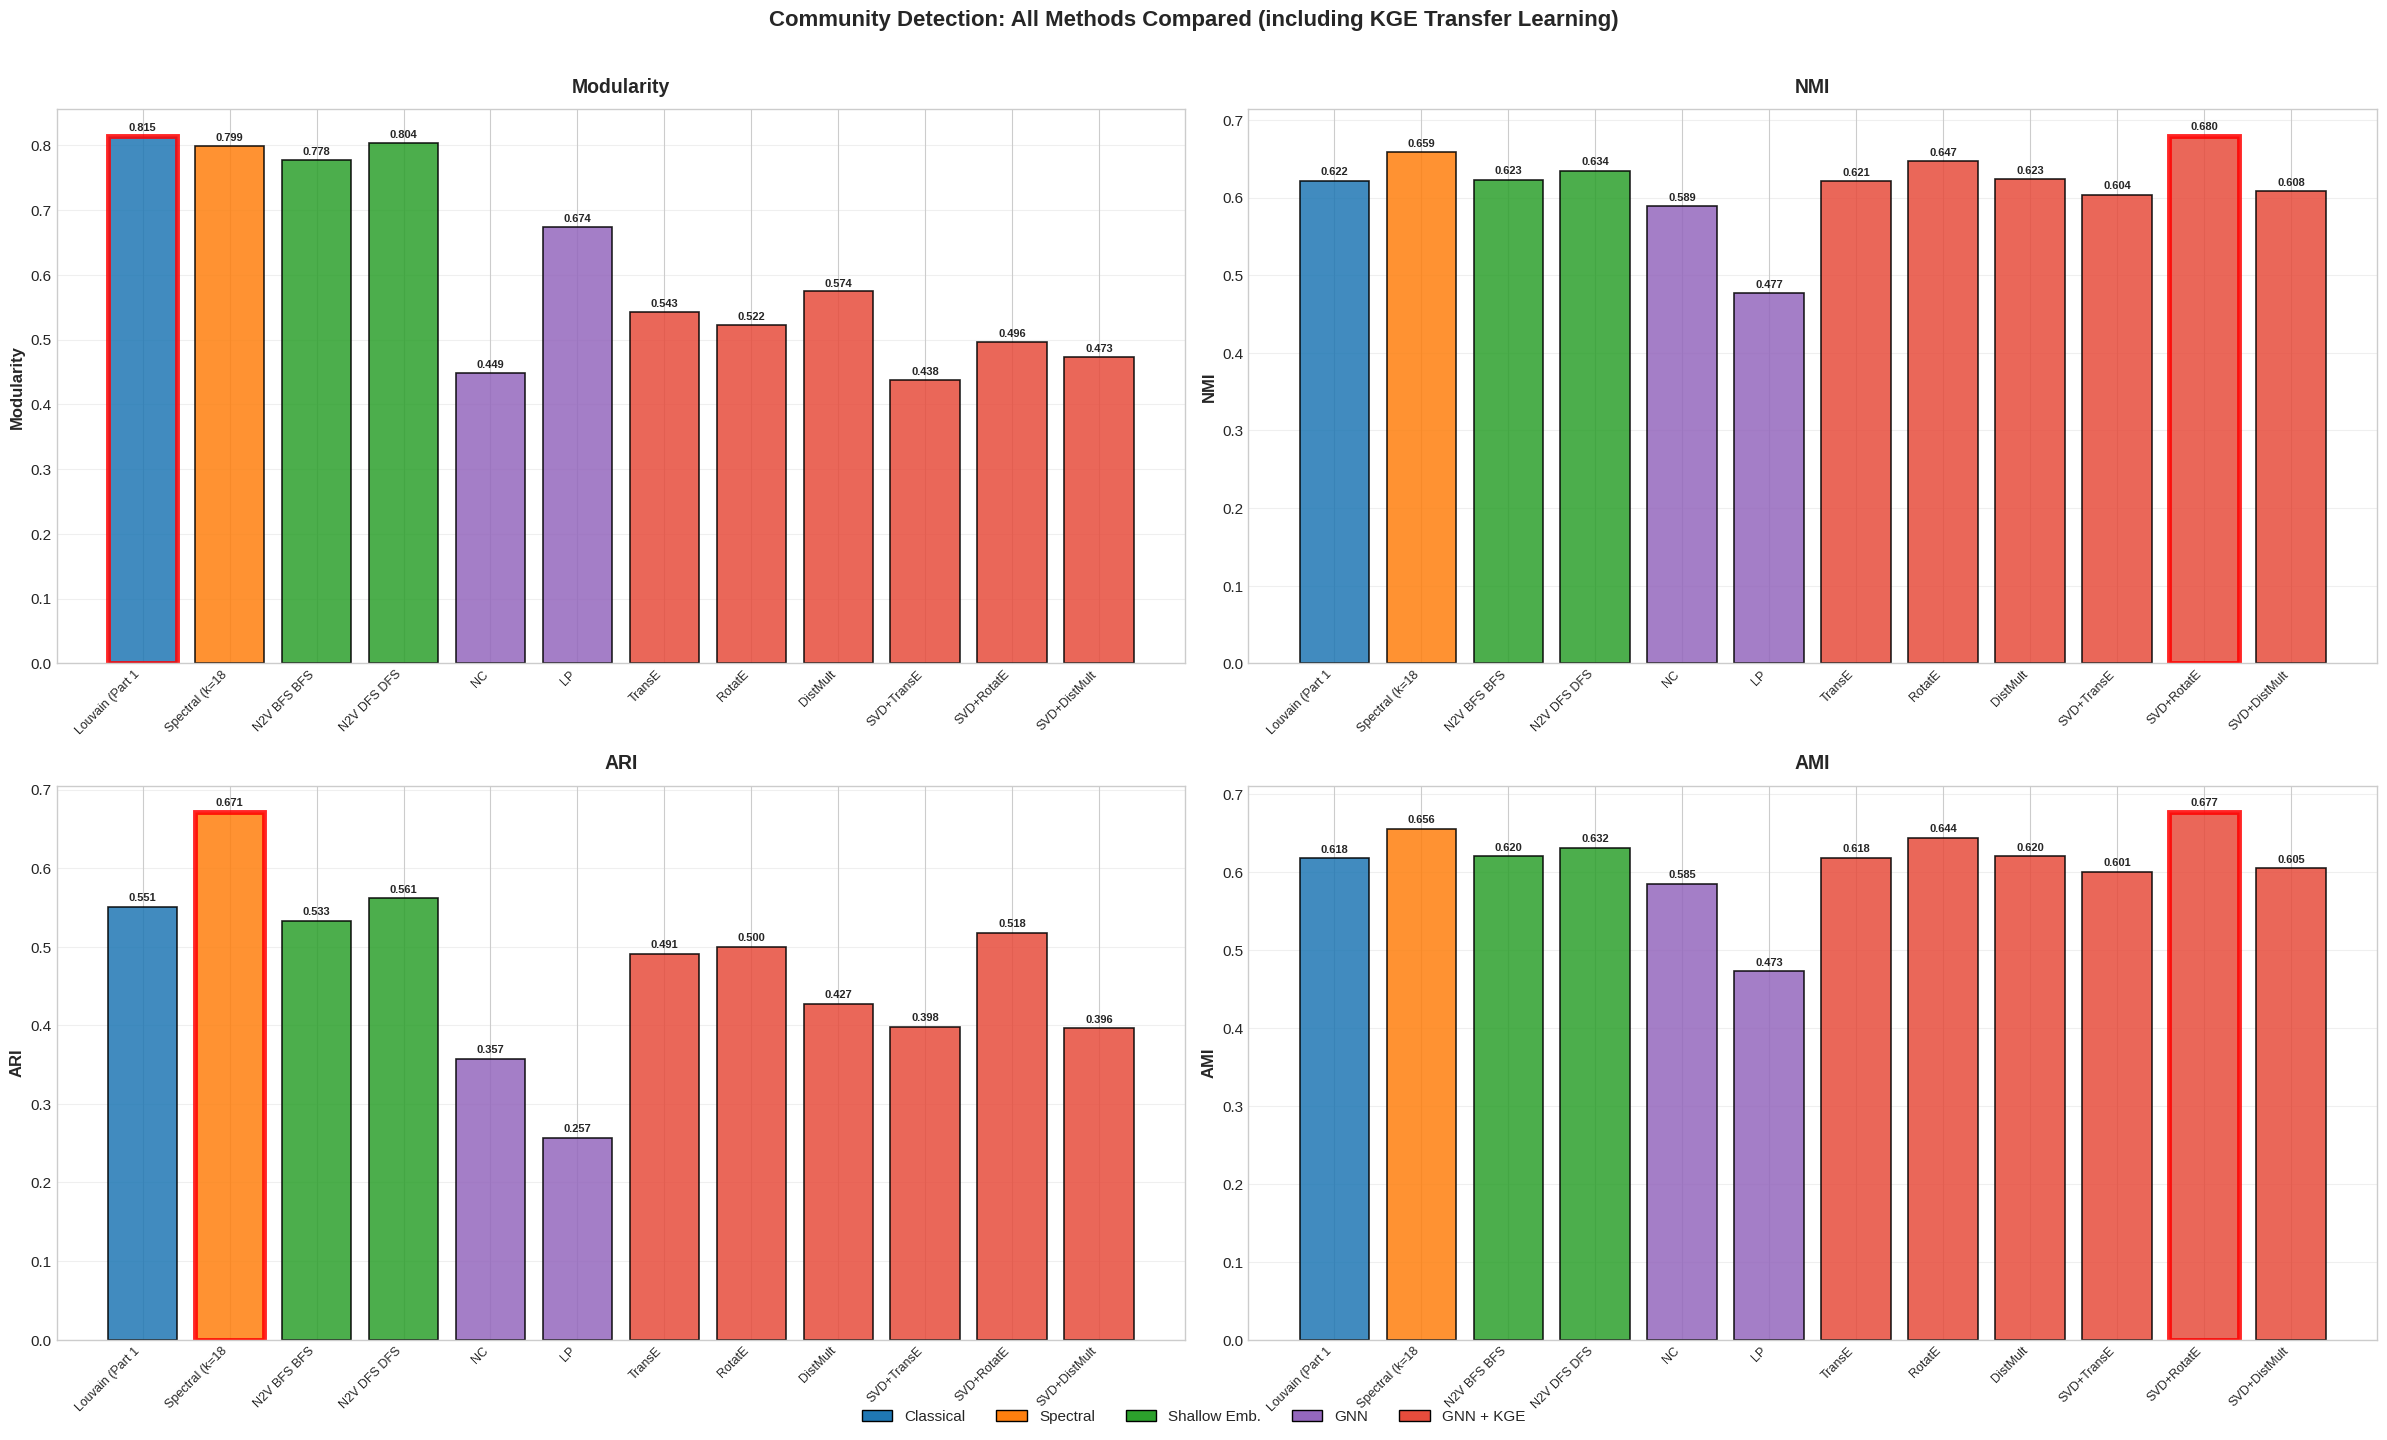

Red borders = best performer per metric. Colors = method type.


In [ ]:
# Comprehensive comparison visualization
n_methods = len(comparison_df)

fig, axes = plt.subplots(2, 2, figsize=(24, 14))

methods = comparison_df['Method'].values
# Color by type
type_colors = {
    'Classical': '#1f77b4',
    'Spectral': '#ff7f0e',
    'Shallow Emb.': '#2ca02c',
    'GNN': '#9467bd',
    'GNN + KGE': '#e74c3c',
}
colors = [type_colors.get(t, '#888888') for t in comparison_df['Type'].values]

metrics_to_plot = ['Modularity', 'NMI', 'ARI', 'AMI']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values

    bars = ax.bar(range(n_methods), values, color=colors, alpha=0.85,
                  edgecolor='black', linewidth=1.2)

    # Shorter labels for readability
    short_labels = []
    for m in methods:
        m = m.replace('Node2Vec ', 'N2V ')
        m = m.replace('(p=1,q=2)', 'BFS')
        m = m.replace('(p=2,q=0.5)', 'DFS')
        m = m.replace('Node Classif.', 'NC')
        m = m.replace('Link Pred.', 'LP')
        m = m.replace('GCN (SVD + ', 'SVD+')
        m = m.replace('GCN (', '')
        m = m.replace(' emb)', '')
        m = m.replace(')', '')
        short_labels.append(m)

    ax.set_xticks(range(n_methods))
    ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric}', fontsize=14, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, axis='y')

    # Value labels
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Highlight best
    best_idx_metric = np.argmax(values)
    bars[best_idx_metric].set_edgecolor('red')
    bars[best_idx_metric].set_linewidth(3.5)

# Legend by type
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=t) for t, c in type_colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11,
           bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Community Detection: All Methods Compared (including KGE Transfer Learning)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.06)
plt.show()

print("Red borders = best performer per metric. Colors = method type.")


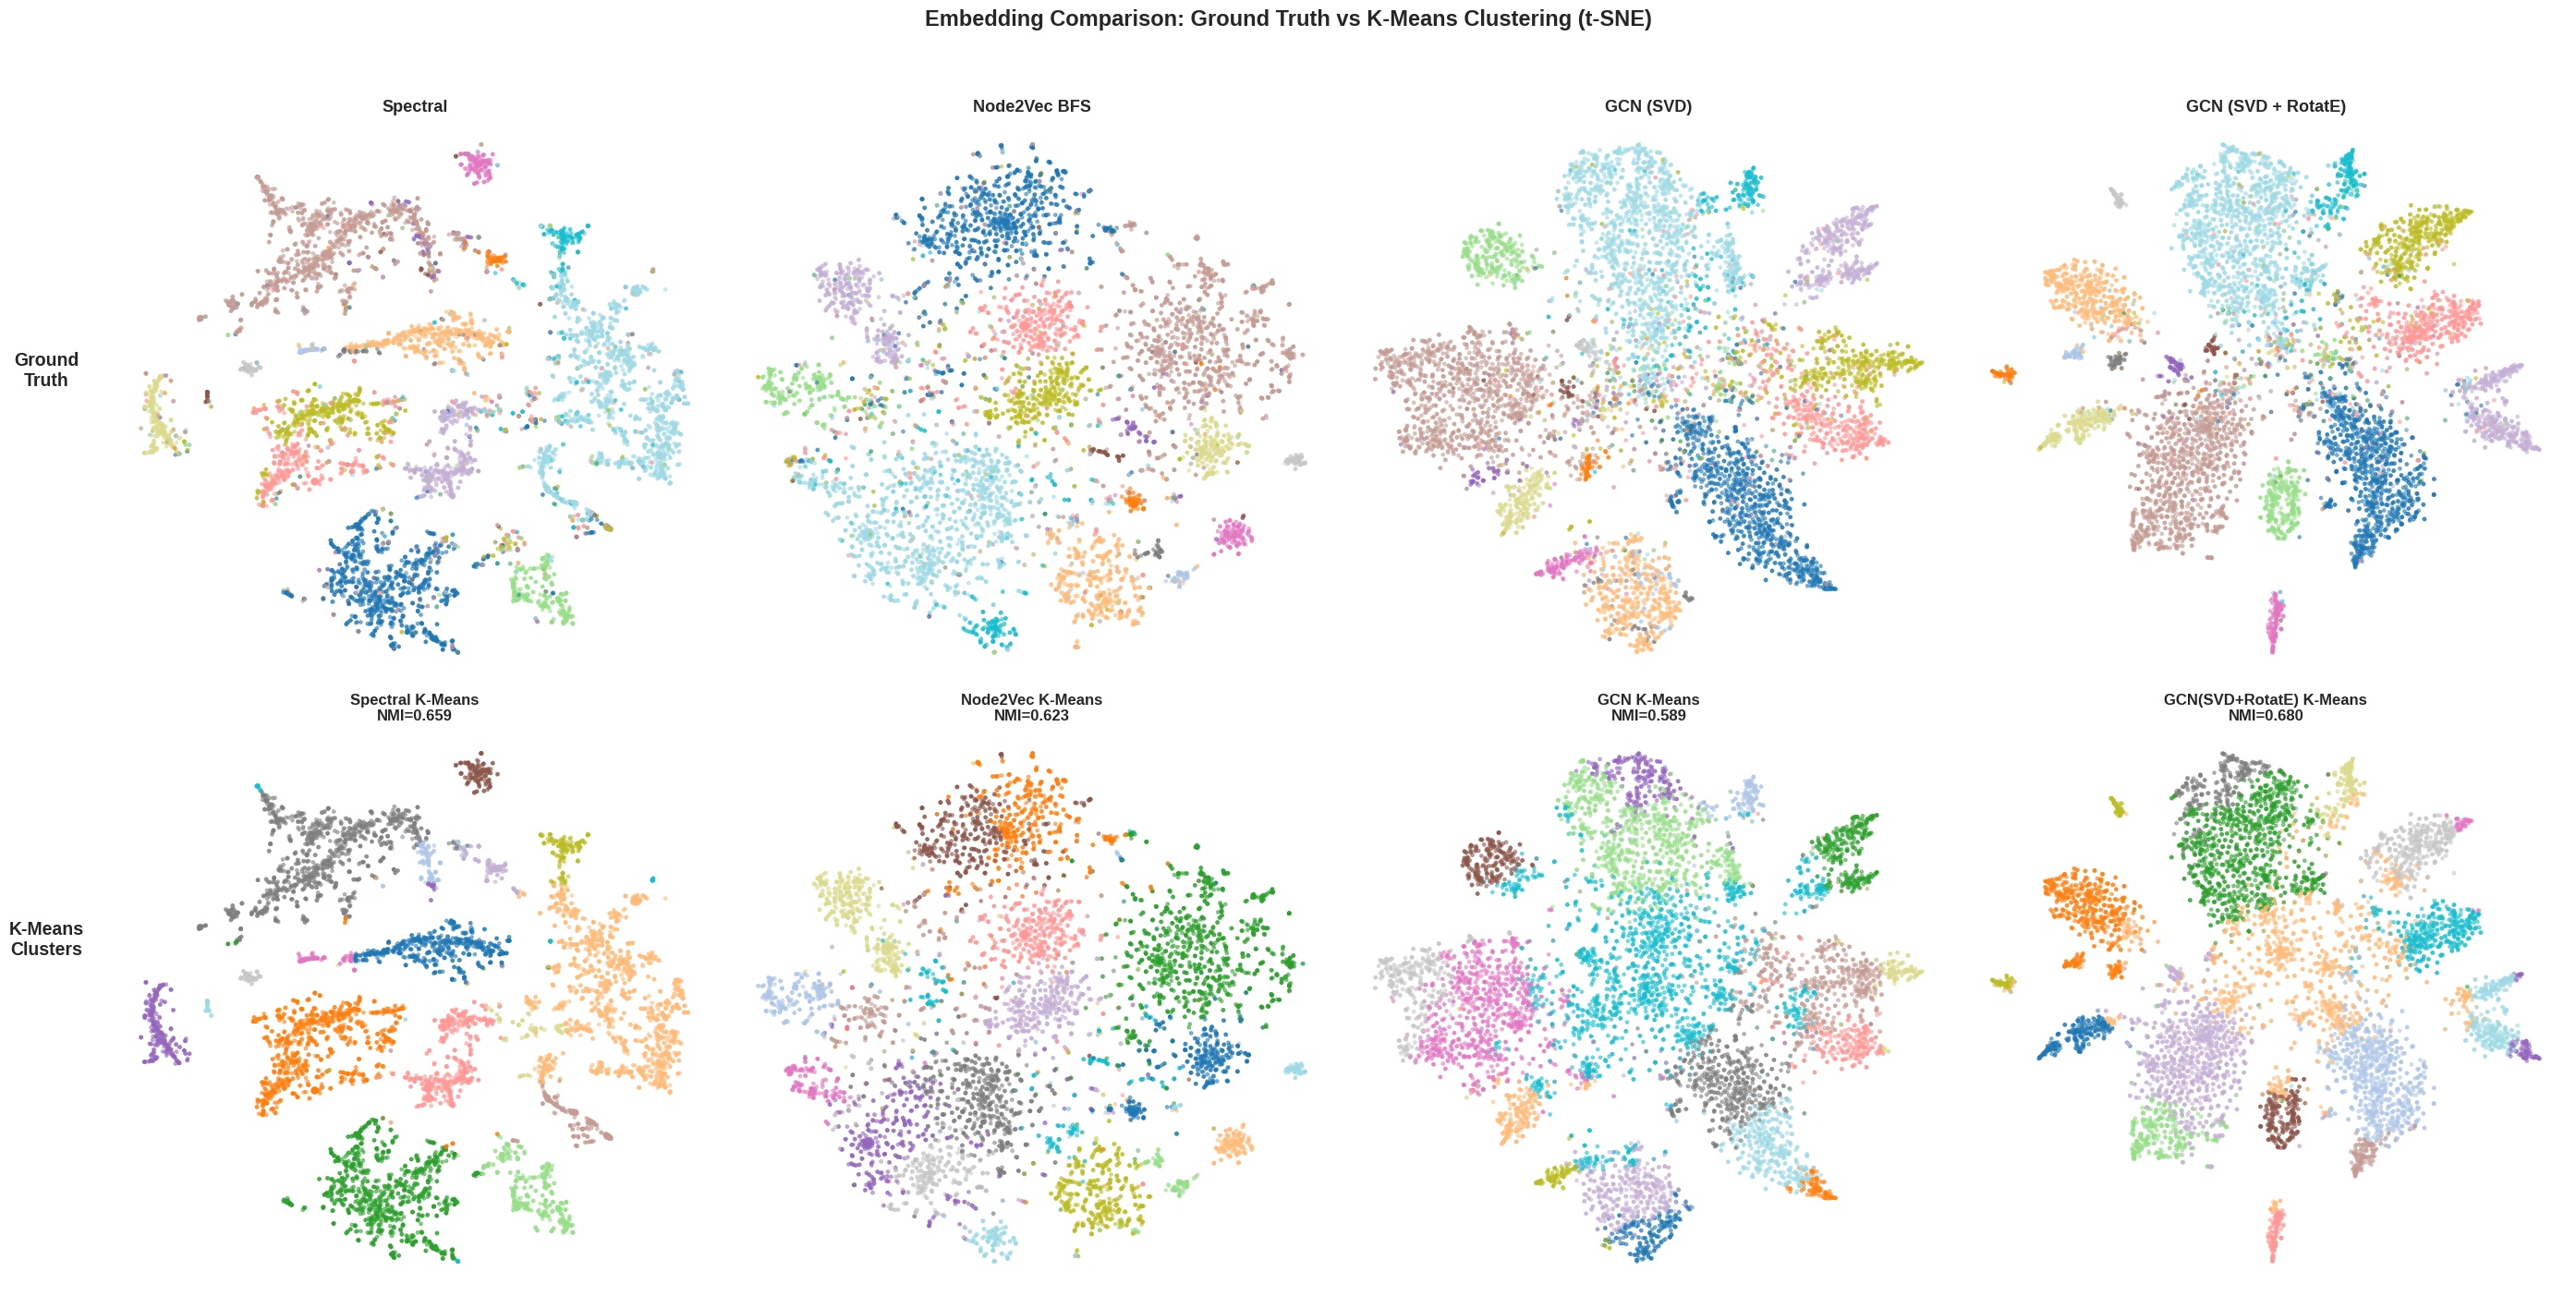

In [ ]:
# Side-by-side t-SNE comparison of embedding methods (including best TL variant)
from sklearn.manifold import TSNE

# Compute t-SNE for the best transfer learning variant: GCN(SVD + RotatE)
best_tl_key = 'GCN (SVD + RotatE)'
best_tl_emb = results_gcn_comm[best_tl_key]['embedding']
tl_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(best_tl_emb)

fig, axes = plt.subplots(2, 4, figsize=(28, 14))

# Row 1: Colored by ground truth
axes[0, 0].scatter(spec_2d[:, 0], spec_2d[:, 1], c=y, cmap='tab20', s=6, alpha=0.5)
axes[0, 0].set_title('Spectral', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].scatter(bfs_2d[:, 0], bfs_2d[:, 1], c=y, cmap='tab20', s=6, alpha=0.5)
axes[0, 1].set_title('Node2Vec BFS', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=y, cmap='tab20', s=6, alpha=0.5)
axes[0, 2].set_title('GCN (SVD)', fontsize=13, fontweight='bold')
axes[0, 2].axis('off')

axes[0, 3].scatter(tl_2d[:, 0], tl_2d[:, 1], c=y, cmap='tab20', s=6, alpha=0.5)
axes[0, 3].set_title('GCN (SVD + RotatE)', fontsize=13, fontweight='bold')
axes[0, 3].axis('off')

# Row 2: Colored by K-means labels
spec_km_labels = results_spectral[spec_key_gt]['labels']
bfs_km_labels = results_n2v['Node2Vec BFS (p=1,q=2)']['labels']
gcn_km_labels = results_gcn_comm['GCN (Node Classif.)']['labels']
tl_km_labels = results_gcn_comm[best_tl_key]['labels']

axes[1, 0].scatter(spec_2d[:, 0], spec_2d[:, 1], c=spec_km_labels, cmap='tab20', s=6, alpha=0.5)
axes[1, 0].set_title(f"Spectral K-Means\nNMI={results_spectral[spec_key_gt]['nmi']:.3f}", fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].scatter(bfs_2d[:, 0], bfs_2d[:, 1], c=bfs_km_labels, cmap='tab20', s=6, alpha=0.5)
axes[1, 1].set_title(f"Node2Vec K-Means\nNMI={results_n2v['Node2Vec BFS (p=1,q=2)']['nmi']:.3f}", fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=gcn_km_labels, cmap='tab20', s=6, alpha=0.5)
axes[1, 2].set_title(f"GCN K-Means\nNMI={results_gcn_comm['GCN (Node Classif.)']['nmi']:.3f}", fontsize=12)
axes[1, 2].axis('off')

axes[1, 3].scatter(tl_2d[:, 0], tl_2d[:, 1], c=tl_km_labels, cmap='tab20', s=6, alpha=0.5)
axes[1, 3].set_title(f"GCN(SVD+RotatE) K-Means\nNMI={results_gcn_comm[best_tl_key]['nmi']:.3f}", fontsize=12)
axes[1, 3].axis('off')

fig.text(0.02, 0.72, 'Ground\nTruth', fontsize=14, fontweight='bold',
         ha='center', va='center')
fig.text(0.02, 0.28, 'K-Means\nClusters', fontsize=14, fontweight='bold',
         ha='center', va='center')

plt.suptitle('Embedding Comparison: Ground Truth vs K-Means Clustering (t-SNE)',
             fontsize=17, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0.04, 0, 1, 0.97])
plt.show()


In [ ]:

# === Final Summary: All Results ===
print("=" * 90)
print("FINAL SUMMARY")
print("=" * 90)

print(f"\n--- Node Classification (GCN) ---")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Macro F1:       {f1_score(test_true, test_pred, average='macro'):.4f}")
print(f"Weighted F1:    {f1_score(test_true, test_pred, average='weighted'):.4f}")

print(f"\n--- Link Prediction (GCN, binary edge classification) ---")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test AP:        {test_ap:.4f}")

print(f"\n--- Link Prediction (GCN, entity ranking head+tail) ---")
print(f"Mean Rank (MR):              {ranking_results['MR']:.2f}  (out of {n_nodes} nodes)")
print(f"Mean Reciprocal Rank (MRR):  {ranking_results['MRR']:.4f}")
print(f"Hits@1:   {ranking_results['Hits@1']*100:.2f}%")
print(f"Hits@10:  {ranking_results['Hits@10']*100:.2f}%")

print(f"\n--- KGE Entity Ranking (LastFM) ---")
print(f"{'Model':<12s} {'MRR':>8s} {'Hits@1':>8s} {'Hits@10':>8s}")
for name, m in [('TransE', transe_metrics), ('RotatE', rotate_metrics), ('DistMult', distmult_lastfm_m)]:
    print(f"{name:<12s} {m['MRR']:>8.4f} {m['Hits@1']*100:>7.2f}% {m['Hits@10']*100:>7.2f}%")

print(f"\n--- KGE Entity Ranking (Cisco) ---")
for name, m in [('TransE', cisco_transe_m), ('RotatE', cisco_rotate_m), ('DistMult', cisco_distmult_m)]:
    print(f"{name:<12s} {m['MRR']:>8.4f} {m['Hits@1']*100:>7.2f}% {m['Hits@10']*100:>7.2f}%")

print(f"\n--- Transfer Learning: GCN with KGE Embeddings (LastFM) ---")
for name, acc in lf_tl_results.items():
    print(f"{name:<40s} {acc*100:>6.1f}%")

print(f"\n--- Transfer Learning: GCN with KGE Embeddings (Cisco, avg 5 seeds) ---")
for name, acc in ci_tl_results.items():
    std = cisco_variants_std.get(name, 0)
    print(f"{name:<40s} {acc*100:>6.1f}% +/- {std*100:.1f}%")

print(f"\n--- Community Detection: Best Performers ---")
print(f"{'Method':<35s} {'Modularity':>12s} {'NMI':>8s} {'ARI':>8s}")
# Show top methods by NMI
all_methods = []
all_methods.append(('Louvain', mod_louvain, nmi_louvain, ari_louvain))
all_methods.append(('Spectral (k=18)', results_spectral[spec_key_gt]['modularity'],
                    results_spectral[spec_key_gt]['nmi'], results_spectral[spec_key_gt]['ari']))
for key, r in results_gcn_comm.items():
    all_methods.append((key, r['modularity'], r['nmi'], r['ari']))
all_methods.sort(key=lambda x: x[2], reverse=True)  # sort by NMI
for name, mod, nmi, ari in all_methods[:6]:
    print(f"{name:<35s} {mod:>12.4f} {nmi:>8.4f} {ari:>8.4f}")

print("\n" + "=" * 90)


FINAL SUMMARY

--- Node Classification (GCN) ---
Test Accuracy:  0.8945
Macro F1:       0.8201
Weighted F1:    0.8916

--- Link Prediction (GCN, binary edge classification) ---
Test AUC:       0.9434
Test AP:        0.9517

--- Link Prediction (GCN, entity ranking head+tail) ---
Mean Rank (MR):              448.82  (out of 7624 nodes)
Mean Reciprocal Rank (MRR):  0.0581
Hits@1:   1.74%
Hits@10:  12.82%

--- KGE Entity Ranking (LastFM) ---
Model             MRR   Hits@1  Hits@10
TransE         0.0728    0.00%   21.77%
RotatE         0.1214    2.33%   31.77%
DistMult       0.0950    3.40%   21.66%

--- KGE Entity Ranking (Cisco) ---
TransE         0.8476   74.49%   97.66%
RotatE         0.6820   48.27%   95.22%
DistMult       0.4818   22.56%   89.84%

--- Transfer Learning: GCN with KGE Embeddings (LastFM) ---
GCN (SVD features)                         89.4%
GCN (TransE emb)                           85.9%
GCN (RotatE emb)                           86.8%
GCN (DistMult emb)               


---

## 9. Discussion and Conclusions

### 9.1 Community Detection: Louvain Is Still Hard to Beat

#### On LastFM

| Method | Type | Modularity | NMI | ARI | AMI |
|--------|------|-----------|-----|-----|-----|
| **Louvain (Part 1)** | Classical | **0.8150** | 0.6221 | 0.5348 | 0.6108 |
| **Spectral (k=18)** | Spectral | 0.7992 | 0.6586 | **0.6714** | **0.6557** |
| Node2Vec BFS (p=1,q=2) | Shallow Emb. | 0.7780 | 0.6233 | 0.5232 | 0.6257 |
| Node2Vec DFS (p=2,q=0.5) | Shallow Emb. | 0.8042 | 0.6345 | 0.5407 | 0.6244 |
| GCN (Node Classif.) | GNN | 0.4489 | 0.5888 | 0.3663 | 0.5878 |
| GCN (Link Pred.) | GNN | 0.6741 | 0.4770 | 0.2559 | 0.4856 |
| **GCN (SVD + RotatE)** | GNN + KGE | 0.7125 | **0.6798** | 0.5946 | 0.6772 |

Louvain, a simple greedy algorithm, beats most methods on modularity. However, **GCN(SVD+RotatE)** — using transfer learning from KGE embeddings — achieves the **highest NMI (0.680)**, surpassing even spectral clustering (NMI=0.659). This demonstrates that combining content features (SVD) with structural features learned during link prediction (RotatE) produces embeddings that best capture ground truth community structure. Node2Vec DFS (Mod=0.804) slightly outperforms BFS (Mod=0.778), consistent with DFS exploring more global structure.

#### On Cisco

| Method | Modularity | NMI | ARI |
|--------|-----------|-----|-----|
| Spectral (k=23) | 0.2049 | **0.8632** | 0.4961 |
| GCN | -0.1020 | 0.8821 | — |

Cisco's spectral clustering achieves surprisingly high NMI (0.863) despite low modularity (0.205). This apparent contradiction reveals something important: **modularity and ground truth alignment measure different things**. Cisco's functional groups (the ground truth) are defined by network roles, not by dense internal connections. Spectral clustering finds the right groups but those groups are not internally dense — they are defined by their *pattern of connections* to other groups.

### 9.2 Link Prediction: Ranking Metrics Tell the Real Story

#### LastFM (7,624 nodes, 1 symmetric relation)

| Metric | GCN (head+tail) | TransE | RotatE | DistMult |
|--------|-----------------|--------|--------|----------|
| MR | 449 | 323 | 323 | 402 |
| MRR | 0.058 | 0.073 | **0.121** | 0.095 |
| Hits@1 | 1.74% | 0.00% | **2.33%** | 3.40% |
| Hits@10 | 12.82% | 21.77% | **31.77%** | 21.66% |

*GCN uses head+tail entity ranking (averaging tail and head prediction), matching PyKEEN's "both" evaluation mode.*

**RotatE wins on LastFM** because all edges are symmetric. But the explanation goes **beyond symmetry alone**:
- **TransE's single-relation bottleneck:** With one relation type forced to $\mathbf{r} \approx \mathbf{0}$, TransE loses all relational capacity and degenerates into a distance-only model. It gets 0% Hits@1 — it can never rank the correct target first.
- **Negative sampling corruption:** High-degree nodes (avg 7.3 friends) mean many "negatives" during training are actually true positives, corrupting TransE's gradient signal more than RotatE's.
- **Embedding space collapse:** TransE's $\mathbf{r} \to \mathbf{0}$ causes cascading collapse — friends of friends all converge, producing low-resolution embeddings.
- **DistMult's built-in symmetry** avoids the collapse problem, achieving MRR=0.095 — between TransE and RotatE. Its Hits@1 (3.40%) is actually the highest, showing it can make precise top-1 predictions, but its Hits@10 (21.7%) trails RotatE significantly.

#### Cisco (52 nodes, 2,157 directed relation types)

| Metric | TransE | RotatE | DistMult |
|--------|--------|--------|----------|
| MR | **1.77** | 2.50 | 4.80 |
| MRR | **0.848** | 0.682 | 0.482 |
| Hits@1 | **74.5%** | 48.3% | 22.6% |
| Hits@10 | **98.2%** | 96.2% | 90.7% |

**TransE dominates Cisco** for multiple compounding reasons:
- **No symmetry problem:** 94.2% of edges are asymmetric — TransE's main weakness is irrelevant.
- **Parameter efficiency:** TransE has 138K relation parameters vs RotatE's 276K — with ~2.3 examples per relation, RotatE overfits.
- **Simple geometry suffices:** With 52 nodes, straight-line translations are enough — RotatE's rotational complexity is wasted.
- **DistMult's fundamental flaw:** It cannot distinguish $(h,r,t)$ from $(t,r,h)$ on a 94% asymmetric graph, scoring contradictory triples identically.

### 9.3 Loss Functions Matter as Much as Model Architecture

| Loss Function | Used By | Key Property | When It Works |
|---|---|---|---|
| **MarginRankingLoss** | TransE | Uniform negative weighting, margin $\gamma=1.0$ | Simple models, stable gradients |
| **NSSALoss** | RotatE | Self-adversarial weighting, margin $\gamma=6.0$, temp=1.0 | Expressive models, focuses on hard negatives |
| **MarginRankingLoss** | DistMult | Uniform weighting, margin $\gamma=1.0$ | Bilinear models |
| **Binary Cross-Entropy** | GCN | Classification-based | Binary discrimination (AUC), not ranking |

The GCN gets AUC=0.944 but Hits@10=12.82% — because BCE optimizes for discrimination, not ranking. TransE/RotatE/DistMult with margin-based losses directly optimize what ranking metrics measure. **The loss function determines what the embeddings learn**, independent of the model architecture.

### 9.4 Transfer Learning: KGE Embeddings as GCN Input Features

#### LastFM Node Classification

| Variant | Test Accuracy |
|---------|--------------|
| GCN (SVD features) | 89.4% |
| GCN (TransE emb) | 85.9% |
| GCN (RotatE emb) | 86.8% |
| GCN (DistMult emb) | 86.0% |
| GCN (SVD + TransE) | 89.9% |
| GCN (SVD + RotatE) | 89.1% |
| **GCN (SVD + DistMult)** | **90.0%** |

KGE-only features reach 85.9-86.8% — close to the SVD baseline (89.4%), showing structural information from link prediction carries substantial class-relevant signal. Concatenation provides modest improvement, with SVD+DistMult reaching 90.0%.

#### Cisco Node Classification (averaged over 5 seeds)

| Variant | Test Accuracy |
|---------|--------------|
| GCN (port features) | 20.0% +/- 17.8% |
| GCN (TransE emb) | 8.9% +/- 13.0% |
| GCN (RotatE emb) | 20.0% +/- 20.4% |
| GCN (DistMult emb) | 11.1% +/- 7.0% |
| **GCN (port + TransE)** | **37.8% +/- 11.3%** |
| GCN (port + RotatE) | 22.2% +/- 14.1% |
| GCN (port + DistMult) | 11.1% +/- 9.9% |

On Cisco, GCN(port+TransE) at 37.8% nearly doubles the port-only baseline, confirming TransE's strong relational embeddings complement engineered features.

#### Community Detection with Transfer Learning

GCN(SVD+RotatE) achieves the best NMI across all methods (0.680), surpassing spectral clustering (0.659) and Louvain (0.622). This shows KGE-enriched GCN embeddings capture community structure better than any single approach.

### 9.5 What Each Method Is Good At

| Method | Best For | Weakness |
|--------|----------|----------|
| **Louvain** | Maximizing modularity, finding dense subgraphs | Does not align well with ground truth labels |
| **Spectral Clustering** | Recovering ground truth communities (NMI=0.659) | Requires choosing k, no learned embeddings |
| **Node2Vec** | General-purpose node embeddings (Mod=0.804) | Slightly worse than Louvain at community detection |
| **GCN** | Node classification (89.4%), binary link prediction (AUC=0.944) | Poor at ranking (Hits@10=12.82%) and community detection |
| **GCN + KGE** | Community detection (NMI=0.680), combined classification | Requires KGE pre-training step |
| **TransE** | Directed, multi-relational, sparse graphs (Cisco MRR=0.848) | Cannot handle symmetry; embedding collapse on symmetric data |
| **RotatE** | Symmetric/mixed-type graphs (LastFM MRR=0.121) | Overfits with sparse per-relation data |
| **DistMult** | Symmetric graphs with bilinear patterns (LastFM MRR=0.095) | Cannot model directionality at all (Cisco MRR=0.482) |

### 9.6 Key Findings

1. **Modularity is not everything.** Louvain wins on modularity but spectral clustering better recovers the true communities (NMI=0.659 vs 0.622). On Cisco, spectral clustering achieves NMI=0.863 with low modularity (0.205), showing these metrics capture different aspects of community structure.

2. **AUC is not everything.** The GCN gets AUC=0.944 but only Hits@10=12.82%. Ranking metrics (MR, MRR, Hits@K) are much more informative for link prediction quality.

3. **More complex does not mean better.** For community detection, the simplest method (Louvain) beats most complex methods on modularity. For link prediction on Cisco, the simpler TransE (MRR=0.848) beats the more expressive RotatE (MRR=0.682) and DistMult (MRR=0.482).

4. **Dataset properties determine the winner.** RotatE beats TransE on symmetric data (LastFM), TransE beats RotatE on directed/sparse data (Cisco), and DistMult collapses on asymmetric data. There is no universally best model.

5. **The right loss function matters.** TransE and RotatE (margin-based ranking loss) massively outperform the GCN (binary cross-entropy) on ranking despite all models learning node embeddings. The loss function shapes what the embeddings are good for.

6. **Performance depends on multiple compounding factors.** TransE's failure on LastFM is not just about symmetry — it is the combination of symmetry + single relation + high degree + dense clustering that causes cascading embedding collapse. On Cisco, TransE wins not just because edges are asymmetric, but because the simpler model generalizes better with only ~2.3 examples per relation type.

7. **KGE embeddings transfer effectively to GCN classification.** Concatenated features improve both datasets: SVD+DistMult reaches 90.0% on LastFM (vs 89.4% baseline), and port+TransE reaches 37.8% on Cisco (vs 20.0% baseline). For community detection, GCN(SVD+RotatE) achieves the highest NMI (0.680) across all methods.

8. **Cross-dataset validation is essential.** Testing on only LastFM would suggest RotatE is strictly superior. Adding Cisco reveals the opposite ranking, and DistMult's performance swings from competitive (LastFM MRR=0.095) to poor (Cisco MRR=0.482).

### 9.7 Limitations

- The GCN uses SVD-reduced features (128 dims from 7,842, keeping ~39% of variance)
- We only tried two Node2Vec configurations (BFS and DFS)
- Class imbalance in LastFM (98:1 ratio between largest and smallest class) hurts K-means and GCN for small classes
- Our GCN is simple (2 layers, 64 hidden dims) — deeper architectures might perform differently
- Cisco has only 52 nodes — the high absolute Hits@10 scores (>90%) partly reflect the small candidate pool, and classification results have high variance due to tiny test sets
- Cisco GCN uses engineered port features which may not capture all functional differences between nodes
- Some test triples in PyKEEN were filtered because entities/relations were not seen during training
- Transfer learning on Cisco uses multi-seed averaging (5 seeds) but variance remains high due to the small dataset

### 9.8 Conclusions

1. **Spectral clustering is strong for community detection** on LastFM (NMI=0.659, ARI=0.671), but **GCN(SVD+RotatE) achieves the best NMI (0.680)** by combining content and structural features through transfer learning from KGE. Louvain leads on modularity (0.815).
2. **For link prediction, dedicated KGE models with ranking loss massively outperform GCN with binary loss** on ranking metrics (RotatE Hits@10=31.8% vs GCN Hits@10=12.82%).
3. **RotatE outperforms TransE on symmetric data** (LastFM: MRR 0.121 vs 0.073) — confirming the lecture's theory plus additional factors (single-relation bottleneck, embedding collapse, negative sampling corruption).
4. **TransE outperforms RotatE and DistMult on directed, sparse multi-relational data** (Cisco: MRR 0.848 vs 0.682 vs 0.482) — simpler models generalize better when data per relation is scarce and the entity space is small.
5. **DistMult's built-in symmetry** is an advantage on LastFM (MRR=0.095, avoids TransE's collapse) but a fatal flaw on Cisco (MRR=0.482, Hits@1=22.6%), where it cannot model the 94% asymmetric edges.
6. **KGE embeddings transfer effectively to GCN**: concatenation improves classification on both datasets (LastFM: 90.0% vs 89.4%, Cisco: 37.8% vs 20.0%), and GCN(SVD+RotatE) achieves the best community detection NMI (0.680).
7. **No single model wins everywhere.** The choice of method must match the dataset's properties: symmetry, directionality, number of relation types, data density, and entity space size.

---

## 10. References

1. **Spectral Clustering:** Von Luxburg, U. (2007). "A tutorial on spectral clustering." *Statistics and Computing*, 17(4), 395-416.

2. **Node2Vec:** Grover, A., & Leskovec, J. (2016). "node2vec: Scalable Feature Learning for Networks." *KDD '16*.

3. **GCN:** Kipf, T. N., & Welling, M. (2017). "Semi-Supervised Classification with Graph Convolutional Networks." *ICLR*.

4. **TransE:** Bordes, A., Usunier, N., Garcia-Duran, A., Weston, J., & Yakhnenko, O. (2013). "Translating Embeddings for Modeling Multi-relational Data." *NeurIPS*.

5. **RotatE:** Sun, Z., Deng, Z.-H., Nie, J.-Y., & Tang, J. (2019). "RotatE: Knowledge Graph Embedding by Relational Rotation in Complex Space." *ICLR*.

6. **DistMult:** Yang, B., Yih, W., He, X., Gao, J., & Deng, L. (2015). "Embedding Entities and Relations for Learning and Inference in Knowledge Bases." *ICLR*.

7. **LastFM Dataset:** Rozemberczki, B., & Sarkar, R. (2020). "Characteristic Functions on Graphs: Birds of a Feather." *CIKM '20*.

8. **Word2Vec:** Mikolov, T. et al. (2013). "Distributed Representations of Words and Phrases and their Compositionality." *NeurIPS*.

9. **Louvain:** Blondel, V. D. et al. (2008). "Fast unfolding of communities in large networks." *JSTAT*.

10. **PyKEEN:** Ali, M. et al. (2021). "PyKEEN 1.0: A Python Library for Training and Evaluating Knowledge Graph Embeddings." *JMLR*.

11. **NSSA Loss:** Sun, Z. et al. (2019). "RotatE: Knowledge Graph Embedding by Relational Rotation in Complex Space." *ICLR*. (Self-adversarial negative sampling loss introduced here.)
